# Exploratory Data Analysis - Posture Dataset

## Project
Smart Posture Monitor

## Dataset
Dataset được xây dựng bởi pipeline:

Image
→ YOLO Pose
→ 6 upper-body keypoints
→ FeatureExtractor V2
→ 29 engineered features
→ features.csv

## Classes

- correct
- forward_slouch
- lean_left
- lean_right

## Mục tiêu EDA

1. Kiểm tra cấu trúc và chất lượng dataset.
2. Kiểm tra số lượng dữ liệu của từng class.
3. Kiểm tra phân bố dữ liệu theo từng person.
4. Phân tích 29 engineered features.
5. Phát hiện missing value, duplicate, infinity và outlier.
6. Kiểm tra correlation giữa các features.
7. Quan sát khả năng phân tách 4 posture classes.
8. Xây dựng chiến lược preprocessing và train/validation/test split phù hợp.

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# Xác định project root
PROJECT_ROOT = Path.cwd()

# Nếu notebook đang chạy từ thư mục notebooks/
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "features.csv"

print("Project root:", PROJECT_ROOT)
print("Dataset path:", DATA_PATH)
print("Dataset exists:", DATA_PATH.exists())

Project root: g:\PTIT TL\K1N3\PYTHON\BTL\smart_posture_monitor
Dataset path: g:\PTIT TL\K1N3\PYTHON\BTL\smart_posture_monitor\data\processed\features.csv
Dataset exists: True


## 1. Load dataset và kiểm tra schema

Mục tiêu:
- Đọc features.csv.
- Kiểm tra số sample và số cột.
- Kiểm tra metadata.
- Xác nhận FeatureExtractor V2 sinh đúng 29 features.

In [4]:
df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully!")
print(f"Number of samples : {df.shape[0]}")
print(f"Number of columns : {df.shape[1]}")

display(df.head())

Dataset loaded successfully!
Number of samples : 2945
Number of columns : 33


,image_path,session_id,person_id,label,shoulder_angle,eye_shoulder_angle,eye_vertical_difference,nose_x_body,nose_y_body,eye_center_x_body,...,head_gravity_angle,nose_gravity_angle,face_pitch_angle,eye_vertical_axis_offset,nose_vertical_axis_offset,head_mean_height,head_height_spread,nose_body_angle,ear_body_angle,head_axis_angle_spread
0,G:/PTIT TL/K1N3/PYTHON/BTL/smart_posture_monit...,session01,person01,correct,-1.018539,-8.129354,-0.026166,0.423192,0.827205,0.358231,...,-21.757685,-28.112474,28.656469,-0.374991,-0.437829,0.876804,0.050482,27.093935,-7.237526,14.913554
1,G:/PTIT TL/K1N3/PYTHON/BTL/smart_posture_monit...,session01,person01,correct,-1.270444,-6.553645,-0.020559,0.393846,0.825563,0.326227,...,-20.415022,-26.774534,30.638771,-0.346982,-0.412053,0.866569,0.051854,25.504089,-8.439146,14.732612
2,G:/PTIT TL/K1N3/PYTHON/BTL/smart_posture_monit...,session01,person01,correct,-0.816811,-9.133100,-0.029310,0.415564,0.774663,0.357886,...,-22.427301,-29.027946,24.128477,-0.370728,-0.426565,0.842638,0.052815,28.211134,-7.121529,15.338748
3,G:/PTIT TL/K1N3/PYTHON/BTL/smart_posture_monit...,session01,person01,correct,-1.831404,-7.025769,-0.023139,0.428679,0.793348,0.369965,...,-23.814072,-30.215570,25.491142,-0.399066,-0.453814,0.854199,0.050284,28.384167,-6.475011,15.151021
4,G:/PTIT TL/K1N3/PYTHON/BTL/smart_posture_monit...,session01,person01,correct,-0.130342,-8.632212,-0.028176,0.454576,0.758630,0.399540,...,-24.103701,-31.060644,21.477776,-0.401583,-0.456301,0.839279,0.059079,30.930302,-4.676363,15.409377


In [5]:
print("COLUMNS")
print("=" * 70)

for i, col in enumerate(df.columns, start=1):
    print(f"{i:02d}. {col}")

COLUMNS
01. image_path
02. session_id
03. person_id
04. label
05. shoulder_angle
06. eye_shoulder_angle
07. eye_vertical_difference
08. nose_x_body
09. nose_y_body
10. eye_center_x_body
11. eye_center_y_body
12. left_ear_x_body
13. left_ear_y_body
14. nose_eye_dx
15. nose_eye_dy
16. eye_width_ratio
17. ear_eye_ratio
18. nose_shoulder_center_distance
19. eye_shoulder_center_distance
20. nose_shoulder_asymmetry
21. eye_shoulder_asymmetry
22. nose_ear_ratio
23. head_body_angle
24. head_gravity_angle
25. nose_gravity_angle
26. face_pitch_angle
27. eye_vertical_axis_offset
28. nose_vertical_axis_offset
29. head_mean_height
30. head_height_spread
31. nose_body_angle
32. ear_body_angle
33. head_axis_angle_spread


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2945 entries, 0 to 2944
Data columns (total 33 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   image_path                     2945 non-null   str    
 1   session_id                     2945 non-null   str    
 2   person_id                      2945 non-null   str    
 3   label                          2945 non-null   str    
 4   shoulder_angle                 2945 non-null   float64
 5   eye_shoulder_angle             2945 non-null   float64
 6   eye_vertical_difference        2945 non-null   float64
 7   nose_x_body                    2945 non-null   float64
 8   nose_y_body                    2945 non-null   float64
 9   eye_center_x_body              2945 non-null   float64
 10  eye_center_y_body              2945 non-null   float64
 11  left_ear_x_body                2945 non-null   float64
 12  left_ear_y_body                2945 non-null   float64
 13 

In [7]:
# Xác định metadata và 29 feature columns

METADATA_COLUMNS = [
    "image_path",
    "session_id",
    "person_id",
    "label",
]

missing_metadata = [
    col for col in METADATA_COLUMNS
    if col not in df.columns
]

if missing_metadata:
    print("Missing metadata columns:", missing_metadata)
else:
    print("All expected metadata columns exist.")

All expected metadata columns exist.


In [8]:
feature_columns = [
    col for col in df.columns
    if col not in METADATA_COLUMNS
]

print(f"Number of feature columns: {len(feature_columns)}")

for i, col in enumerate(feature_columns, start=1):
    print(f"{i:02d}. {col}")

Number of feature columns: 29
01. shoulder_angle
02. eye_shoulder_angle
03. eye_vertical_difference
04. nose_x_body
05. nose_y_body
06. eye_center_x_body
07. eye_center_y_body
08. left_ear_x_body
09. left_ear_y_body
10. nose_eye_dx
11. nose_eye_dy
12. eye_width_ratio
13. ear_eye_ratio
14. nose_shoulder_center_distance
15. eye_shoulder_center_distance
16. nose_shoulder_asymmetry
17. eye_shoulder_asymmetry
18. nose_ear_ratio
19. head_body_angle
20. head_gravity_angle
21. nose_gravity_angle
22. face_pitch_angle
23. eye_vertical_axis_offset
24. nose_vertical_axis_offset
25. head_mean_height
26. head_height_spread
27. nose_body_angle
28. ear_body_angle
29. head_axis_angle_spread


In [9]:
EXPECTED_NUM_FEATURES = 29

if len(feature_columns) == EXPECTED_NUM_FEATURES:
    print("Feature count OK: 29 features.")
else:
    print(
        f"WARNING: Expected {EXPECTED_NUM_FEATURES} features, "
        f"but found {len(feature_columns)}."
    )

Feature count OK: 29 features.


## 2. Data Integrity

Mục tiêu:
- Kiểm tra missing values.
- Kiểm tra NaN và infinity trong 29 features.
- Kiểm tra duplicate rows.
- Kiểm tra duplicate image paths.
- Kiểm tra label hợp lệ.
- Kiểm tra person_id và session_id.
- Không xóa hoặc chỉnh sửa dữ liệu ở bước này.

In [10]:
# Kiểm tra Missing Values
missing_counts = df.isna().sum()
missing_counts = missing_counts[missing_counts > 0].sort_values(ascending=False)

print("Total missing values:", df.isna().sum().sum())

if missing_counts.empty:
    print("No missing values found.")
else:
    display(missing_counts.to_frame("missing_count"))

Total missing values: 0
No missing values found.


In [11]:
# Kiểm tra Missing riêng trong 29 features
feature_missing = df[feature_columns].isna().sum()
feature_missing = feature_missing[feature_missing > 0]

print(
    "Total missing values in 29 features:",
    df[feature_columns].isna().sum().sum()
)

if feature_missing.empty:
    print("No missing values in feature columns.")
else:
    display(feature_missing.to_frame("missing_count"))

Total missing values in 29 features: 0
No missing values in feature columns.


In [12]:
# Kiểm tra tất cả 29 features có phải numeric
non_numeric_features = [
    col
    for col in feature_columns
    if not pd.api.types.is_numeric_dtype(df[col])
]

if not non_numeric_features:
    print("All 29 features are numeric.")
else:
    print("Non-numeric feature columns:")
    for col in non_numeric_features:
        print("-", col)

All 29 features are numeric.


In [13]:
# Kiểm tra +inf và -inf
feature_array = df[feature_columns].to_numpy()

positive_inf = np.isposinf(feature_array).sum()
negative_inf = np.isneginf(feature_array).sum()

print("Positive infinity:", positive_inf)
print("Negative infinity:", negative_inf)
print("Total infinity:", positive_inf + negative_inf)

inf_counts = pd.Series(
    np.isinf(df[feature_columns]).sum(),
    index=feature_columns
)

# Xác định feature nào có infinity
inf_counts = inf_counts[inf_counts > 0]

if inf_counts.empty:
    print("No infinity values found in the 29 features.")
else:
    display(inf_counts.to_frame("inf_count"))

Positive infinity: 0
Negative infinity: 0
Total infinity: 0
No infinity values found in the 29 features.


In [14]:
# Kiểm tra duplicate toàn bộ row
duplicate_row_count = df.duplicated().sum()

print("Duplicated full rows:", duplicate_row_count)

Duplicated full rows: 0


In [15]:
# Kiểm tra duplicate image_path
duplicate_image_count = df["image_path"].duplicated().sum()

print("Duplicated image paths:", duplicate_image_count)

Duplicated image paths: 0


In [16]:
# Kiểm tra 4 labels
EXPECTED_CLASSES = [
    "correct",
    "forward_slouch",
    "lean_left",
    "lean_right",
]

actual_classes = sorted(
    df["label"].dropna().unique().tolist()
)

print("Expected classes:", EXPECTED_CLASSES)
print("Actual classes  :", actual_classes)

Expected classes: ['correct', 'forward_slouch', 'lean_left', 'lean_right']
Actual classes  : ['correct', 'forward_slouch', 'lean_left', 'lean_right']


In [17]:
# Kiểm tra class unknown
unknown_classes = sorted(
    set(actual_classes) - set(EXPECTED_CLASSES)
)

missing_classes = sorted(
    set(EXPECTED_CLASSES) - set(actual_classes)
)

print("Unknown classes:", unknown_classes)
print("Missing classes:", missing_classes)

# kiểm tra có khoảng trắng thừa không
labels_with_whitespace = df[
    df["label"] != df["label"].str.strip()
]

print(
    "Labels containing leading/trailing whitespace:",
    len(labels_with_whitespace)
)

Unknown classes: []
Missing classes: []
Labels containing leading/trailing whitespace: 0


In [18]:
# Kiểm tra person_id
person_values = sorted(
    df["person_id"].dropna().unique().tolist()
)

print("Number of unique persons:", len(person_values))
print("Persons:")

for person in person_values:
    print("-", person)

Number of unique persons: 10
Persons:
- person01
- person02
- person03
- person04
- person05
- person06
- person07
- person08
- person09
- person10


In [19]:
# Kiểm tra person rỗng
empty_person = (
    df["person_id"]
    .astype(str)
    .str.strip()
    .eq("")
    .sum()
)

print("Empty person_id:", empty_person)

Empty person_id: 0


In [20]:
# Kiểm tra session_id
session_values = sorted(
    df["session_id"].dropna().unique().tolist()
)

print("Number of unique sessions:", len(session_values))
print("First sessions:")

for session in session_values[:20]:
    print("-", session)

Number of unique sessions: 3
First sessions:
- session01
- session02
- session03


In [21]:
# Kiểm tra session rỗng
empty_session = (
    df["session_id"]
    .astype(str)
    .str.strip()
    .eq("")
    .sum()
)

print("Empty session_id:", empty_session)

Empty session_id: 0


In [22]:
# Kiểm tra một session có thuộc nhiều person hay không
session_person_counts = (
    df.groupby("session_id")["person_id"]
    .nunique()
)

invalid_sessions = session_person_counts[
    session_person_counts > 1
]

if invalid_sessions.empty:
    print("Each session belongs to exactly one person.")
else:
    print("Sessions linked to multiple persons:")
    display(invalid_sessions.to_frame("person_count"))

Sessions linked to multiple persons:


,person_count
session_id,
session01,10


In [23]:
# Kiểm tra một image_path có nhiều label không
image_label_counts = (
    df.groupby("image_path")["label"]
    .nunique()
)

conflicting_images = image_label_counts[
    image_label_counts > 1
]

if conflicting_images.empty:
    print("No image is assigned to multiple labels.")
else:
    print("Images with conflicting labels:")
    display(conflicting_images.to_frame("label_count"))

No image is assigned to multiple labels.


In [24]:
# Summary 
integrity_summary = {
    "samples": len(df),
    "features": len(feature_columns),
    "missing_values": int(df.isna().sum().sum()),
    "positive_inf": int(np.isposinf(df[feature_columns].to_numpy()).sum()),
    "negative_inf": int(np.isneginf(df[feature_columns].to_numpy()).sum()),
    "duplicate_rows": int(df.duplicated().sum()),
    "duplicate_image_paths": int(df["image_path"].duplicated().sum()),
    "unique_persons": int(df["person_id"].nunique()),
    "unique_sessions": int(df["session_id"].nunique()),
    "unique_classes": int(df["label"].nunique()),
}

pd.DataFrame(
    integrity_summary.items(),
    columns=["check", "value"]
)

,check,value
0,samples,2945
1,features,29
2,missing_values,0
3,positive_inf,0
4,negative_inf,0
5,duplicate_rows,0
6,duplicate_image_paths,0
7,unique_persons,10
8,unique_sessions,3
9,unique_classes,4


### Kết luận bước 2 - Data Integrity

- Dataset có 2945 samples và 29 engineered features.
- Không có missing values.
- Không có giá trị +inf hoặc -inf.
- Không có duplicate rows.
- Không có duplicate image paths.
- Dataset gồm 10 persons và 4 posture classes.
- Có 3 session IDs; cần xem xét session cùng với person_id khi phân tích data leakage.
- Chưa có lý do để loại hoặc chỉnh sửa sample ở giai đoạn này.

## 3. Class Distribution

Mục tiêu:
- Kiểm tra số lượng sample của từng posture class.
- Kiểm tra mức độ cân bằng giữa 4 classes.
- Xem quá trình lọc ảnh có làm một posture bị mất nhiều dữ liệu hơn các posture khác hay không.

In [25]:
# Kiểm tra số lượng sample của từng posture class.
EXPECTED_CLASSES = [
    "correct",
    "forward_slouch",
    "lean_left",
    "lean_right",
]

class_counts = (
    df["label"]
    .value_counts()
    .reindex(EXPECTED_CLASSES, fill_value=0)
)

class_percentages = (
    class_counts / len(df) * 100
)

class_distribution = pd.DataFrame({
    "count": class_counts,
    "percentage": class_percentages.round(2)
})

display(class_distribution)

,count,percentage
label,,
correct,743,25.23
forward_slouch,658,22.34
lean_left,782,26.55
lean_right,762,25.87


In [26]:
max_class = class_counts.idxmax()
min_class = class_counts.idxmin()

max_count = class_counts.max()
min_count = class_counts.min()

print(f"Largest class : {max_class} ({max_count} samples)")
print(f"Smallest class: {min_class} ({min_count} samples)")

if min_count > 0:
    print(f"Max / Min ratio: {max_count / min_count:.3f}")

Largest class : lean_left (782 samples)
Smallest class: forward_slouch (658 samples)
Max / Min ratio: 1.188


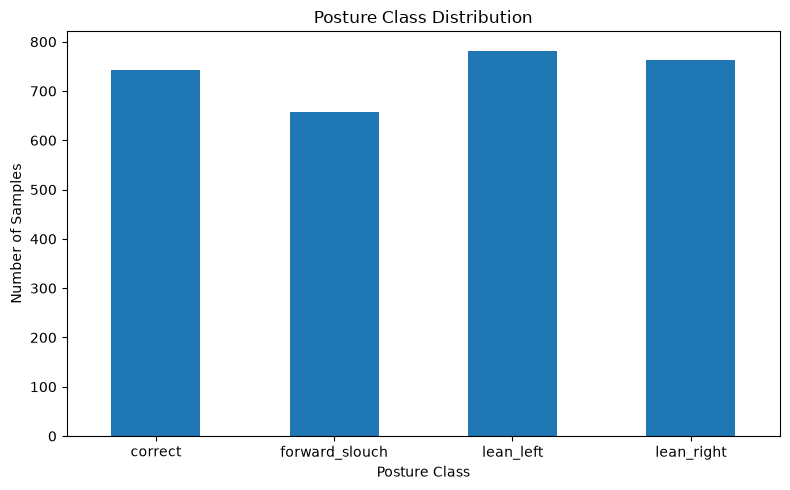

In [27]:
ax = class_counts.plot(
    kind="bar",
    figsize=(8, 5)
)

ax.set_title("Posture Class Distribution")
ax.set_xlabel("Posture Class")
ax.set_ylabel("Number of Samples")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Kết luận bước 3 - Class Distribution

- Dataset có phân bố tương đối cân bằng giữa 4 posture classes.
- `lean_left` có số lượng sample lớn nhất.
- `forward_slouch` có số lượng sample thấp nhất.
- Chênh lệch giữa class lớn nhất và nhỏ nhất chưa đủ lớn để xem là class imbalance nghiêm trọng.
- Chưa cần áp dụng oversampling, undersampling hoặc class weighting.
- `forward_slouch` cần được kiểm tra thêm theo từng person để xác định liệu quá trình pose detection có reject tư thế này nhiều hơn các tư thế khác hay không.

## 4. Person Distribution

Mục tiêu:
- Kiểm tra số lượng sample của từng person.
- Kiểm tra mỗi person có đủ 4 posture classes hay không.
- Phát hiện person/class bị mất nhiều dữ liệu.
- Chuẩn bị chiến lược Group Split để tránh data leakage.

In [28]:
person_counts = (
    df["person_id"]
    .value_counts()
    .sort_index()
)

display(person_counts.to_frame("sample_count"))

,sample_count
person_id,
person01,796
person02,273
person03,307
person04,258
person05,48
person06,252
person07,255
person08,246
person09,284


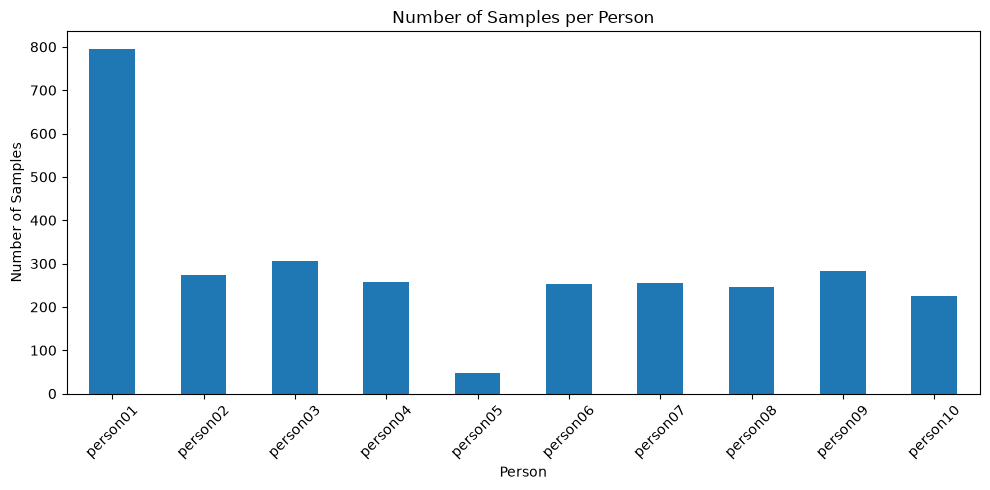

In [29]:
ax = person_counts.plot(
    kind="bar",
    figsize=(10, 5)
)

ax.set_title("Number of Samples per Person")
ax.set_xlabel("Person")
ax.set_ylabel("Number of Samples")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [30]:
person_class_table = pd.crosstab(
    df["person_id"],
    df["label"]
)

person_class_table = person_class_table.reindex(
    columns=EXPECTED_CLASSES,
    fill_value=0
)

person_class_table["total"] = (
    person_class_table[EXPECTED_CLASSES]
    .sum(axis=1)
)

display(person_class_table)

label,correct,forward_slouch,lean_left,lean_right,total
person_id,,,,,
person01,211,192,201,192,796
person02,84,65,57,67,273
person03,62,54,105,86,307
person04,57,63,72,66,258
person05,12,6,8,22,48
person06,61,67,64,60,252
person07,60,63,67,65,255
person08,61,61,56,68,246
person09,68,70,80,66,284


In [31]:
person_class_percentage = (
    person_class_table[EXPECTED_CLASSES]
    .div(person_class_table["total"], axis=0)
    * 100
)

display(person_class_percentage.round(2))

label,correct,forward_slouch,lean_left,lean_right
person_id,,,,
person01,26.51,24.12,25.25,24.12
person02,30.77,23.81,20.88,24.54
person03,20.20,17.59,34.20,28.01
person04,22.09,24.42,27.91,25.58
person05,25.00,12.50,16.67,45.83
person06,24.21,26.59,25.40,23.81
person07,23.53,24.71,26.27,25.49
person08,24.80,24.80,22.76,27.64
person09,23.94,24.65,28.17,23.24


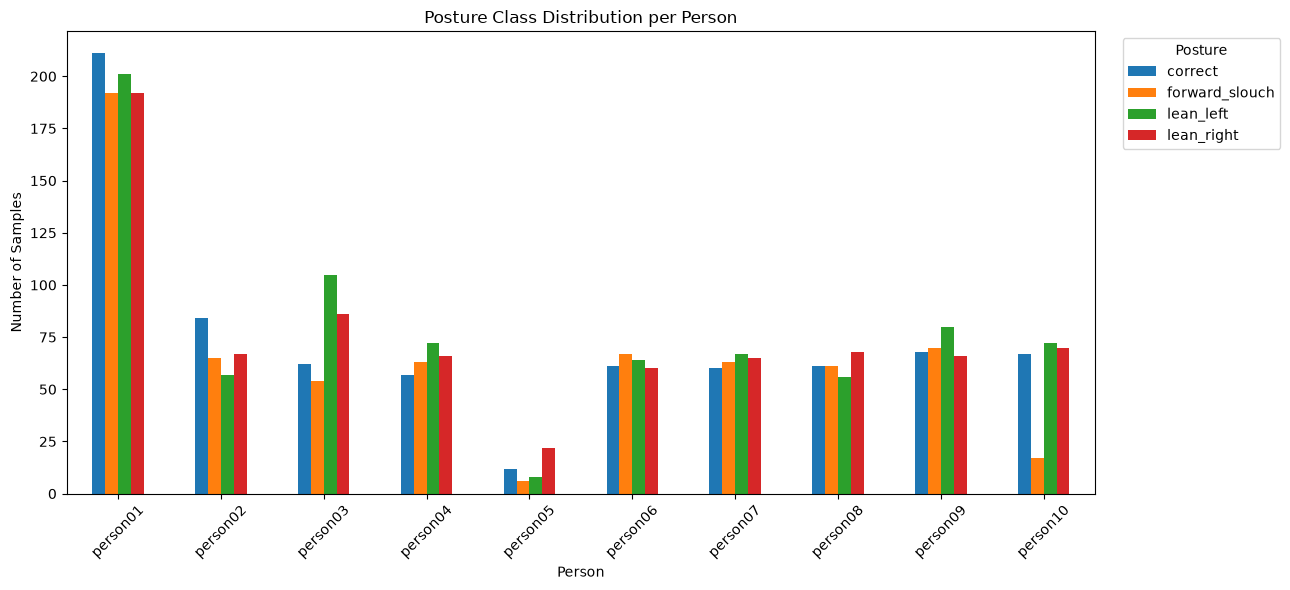

In [32]:
person_class_table[EXPECTED_CLASSES].plot(
    kind="bar",
    figsize=(13, 6)
)

plt.title("Posture Class Distribution per Person")
plt.xlabel("Person")
plt.ylabel("Number of Samples")

plt.xticks(rotation=45)

plt.legend(
    title="Posture",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [33]:
person_class_table = pd.crosstab(
    df["person_id"],
    df["label"]
).reindex(
    columns=EXPECTED_CLASSES,
    fill_value=0
)

person_class_table["total"] = person_class_table.sum(axis=1)

display(person_class_table)

label,correct,forward_slouch,lean_left,lean_right,total
person_id,,,,,
person01,211,192,201,192,796
person02,84,65,57,67,273
person03,62,54,105,86,307
person04,57,63,72,66,258
person05,12,6,8,22,48
person06,61,67,64,60,252
person07,60,63,67,65,255
person08,61,61,56,68,246
person09,68,70,80,66,284


In [34]:
person_class_percentage = (
    person_class_table[EXPECTED_CLASSES]
    .div(person_class_table["total"], axis=0)
    * 100
)

display(person_class_percentage.round(2))

label,correct,forward_slouch,lean_left,lean_right
person_id,,,,
person01,26.51,24.12,25.25,24.12
person02,30.77,23.81,20.88,24.54
person03,20.20,17.59,34.20,28.01
person04,22.09,24.42,27.91,25.58
person05,25.00,12.50,16.67,45.83
person06,24.21,26.59,25.40,23.81
person07,23.53,24.71,26.27,25.49
person08,24.80,24.80,22.76,27.64
person09,23.94,24.65,28.17,23.24


In [35]:
# tự động tìm các tổ hợp person × class đáng nghi
person_class_counts = person_class_table[EXPECTED_CLASSES]

person_mean = person_class_counts.mean(axis=1)

relative_to_person_mean = (
    person_class_counts
    .div(person_mean, axis=0)
)

suspicious = relative_to_person_mean < 0.5

display(suspicious)

label,correct,forward_slouch,lean_left,lean_right
person_id,,,,
person01,False,False,False,False
person02,False,False,False,False
person03,False,False,False,False
person04,False,False,False,False
person05,False,False,False,False
person06,False,False,False,False
person07,False,False,False,False
person08,False,False,False,False
person09,False,False,False,False


In [36]:
missing_person_classes = []

for person in person_class_counts.index:
    for label in person_class_counts.columns:
        count = person_class_counts.loc[person, label]

        if count == 0:
            missing_person_classes.append(
                {
                    "person_id": person,
                    "label": label
                }
            )

pd.DataFrame(missing_person_classes)

""


In [37]:
person_session_table = pd.crosstab(
    df["person_id"],
    df["session_id"]
)

display(person_session_table)

session_id,session01,session02,session03
person_id,,,
person01,297,241,258
person02,273,0,0
person03,307,0,0
person04,258,0,0
person05,48,0,0
person06,252,0,0
person07,255,0,0
person08,246,0,0
person09,284,0,0


### Kết luận bước 4 - Person Distribution

- Dataset gồm 10 persons và tất cả persons đều có dữ liệu cho cả 4 posture classes.
- Số lượng sample giữa các persons không đồng đều.

- `person01` có 796 samples, cao hơn đáng kể so với các persons khác.
  Tuy nhiên, `person01` được ghi nhận trong 3 sessions (`session01`, `session02`,
  `session03`), trong khi các persons còn lại chỉ có dữ liệu ở `session01`.
  Vì vậy số sample lớn của `person01` ít nhất một phần có thể được giải thích
  bởi số recording sessions nhiều hơn.

- `person05` chỉ còn 48 valid samples. Nguyên nhân đã được xác định là lỗi
  thu thập dữ liệu: camera được đặt/quay từ phía bên phải thay vì góc nhìn
  chuẩn khoảng 45° từ bên trái.

- Do pipeline hiện tại được thiết kế cho left-side view và sử dụng 6
  keypoints tương ứng, phần lớn frame của `person05` không đáp ứng điều
  kiện keypoint và bị reject.

- Vì đây là dữ liệu sai acquisition protocol, `person05` sẽ được loại khỏi
  modeling dataset thay vì thực hiện oversampling hoặc coi đây là lỗi
  mất cân bằng tự nhiên.

- `person10` có bất thường rõ rệt ở class `forward_slouch`:
  chỉ có 17 samples (7.52%), trong khi ba class còn lại có khoảng 67–72 samples.
  Trường hợp này cần được điều tra thêm bằng dữ liệu raw/rejected.

- `person03` có số lượng `lean_left` cao hơn đáng kể so với `correct`
  và `forward_slouch`, nhưng vẫn có dữ liệu đại diện cho cả 4 classes.

- `session_id` không phải định danh session duy nhất trên toàn dataset vì
  `session01` được sử dụng cho nhiều persons. Một recording session cụ thể
  nên được nhận diện bằng cặp `(person_id, session_id)`.

- Class distribution cân bằng ở mức toàn dataset không đồng nghĩa với
  phân bố cân bằng ở mức person × class.

- Chưa có cơ sở để oversample, undersample hoặc loại bỏ bất kỳ person nào
  tại giai đoạn EDA.

- Khi đánh giá mô hình, dữ liệu cần được chia theo `person_id` thay vì
  random theo frame để hạn chế subject leakage và đánh giá khả năng
  generalize sang người chưa xuất hiện trong training.

## 5. Statistical Analysis of 29 Features

Mục tiêu:
- Phân tích thống kê cơ bản của 29 engineered features.
- Kiểm tra range, scale và độ biến thiên.
- Phát hiện constant hoặc near-constant features.
- Kiểm tra số lượng giá trị unique.
- Kiểm tra tỷ lệ giá trị zero và giá trị âm.
- Chuẩn bị cho feature distribution, outlier và correlation analysis.

Lưu ý:
`person05` vẫn được giữ trong EDA dataset để đảm bảo tính traceability.
Dữ liệu của person này được thu sai camera protocol và sẽ được xem xét
riêng ở giai đoạn preprocessing/training.

In [38]:
# Xác nhận dataset và 29 features
print("EDA samples:", len(df))
print("Number of features:", len(feature_columns))

assert len(feature_columns) == 29, \
    f"Expected 29 features, found {len(feature_columns)}"

print("Feature count OK: 29 features.")

EDA samples: 2945
Number of features: 29
Feature count OK: 29 features.


In [39]:
# Thống kê mô tả cơ bản
feature_stats = (
    df[feature_columns]
    .describe()
    .T
)

display(feature_stats)

,count,mean,std,min,25%,50%,75%,max
shoulder_angle,2945.0,1.227612,8.264919,-33.322411,-1.771224,1.336954,6.325143,28.911543
eye_shoulder_angle,2945.0,-6.612411,8.604724,-34.885452,-12.560007,-6.485768,-0.474325,20.052111
eye_vertical_difference,2945.0,-0.022044,0.029871,-0.109433,-0.043141,-0.022824,-0.001861,0.088747
nose_x_body,2945.0,0.338023,0.200619,-0.367179,0.219929,0.337946,0.468632,0.966731
nose_y_body,2945.0,0.526289,0.204299,-0.082098,0.412779,0.541590,0.656242,1.641376
eye_center_x_body,2945.0,0.308165,0.191207,-0.328100,0.192580,0.298095,0.444011,0.912397
eye_center_y_body,2945.0,0.652224,0.192400,0.069658,0.553127,0.656877,0.760790,1.877435
left_ear_x_body,2945.0,-0.116979,0.123243,-0.668416,-0.199715,-0.123315,-0.046262,0.348718
left_ear_y_body,2945.0,0.645389,0.124886,0.272837,0.571313,0.630273,0.710341,1.594234
nose_eye_dx,2945.0,0.029858,0.027922,-0.053690,0.012127,0.030086,0.048395,0.168845


In [40]:
# Tạo bảng thống kê đầy đủ hơn
feature_summary = pd.DataFrame(index=feature_columns)

feature_summary["mean"] = df[feature_columns].mean()
feature_summary["std"] = df[feature_columns].std()

feature_summary["min"] = df[feature_columns].min()
feature_summary["q1"] = df[feature_columns].quantile(0.25)
feature_summary["median"] = df[feature_columns].median()
feature_summary["q3"] = df[feature_columns].quantile(0.75)
feature_summary["max"] = df[feature_columns].max()

feature_summary["range"] = (
    feature_summary["max"]
    - feature_summary["min"]
)

feature_summary["iqr"] = (
    feature_summary["q3"]
    - feature_summary["q1"]
)

feature_summary["variance"] = df[feature_columns].var()

feature_summary["n_unique"] = (
    df[feature_columns]
    .nunique()
)

display(feature_summary)

,mean,std,min,q1,median,q3,max,range,iqr,variance,n_unique
shoulder_angle,1.227612,8.264919,-33.322411,-1.771224,1.336954,6.325143,28.911543,62.233954,8.096367,68.308888,2944
eye_shoulder_angle,-6.612411,8.604724,-34.885452,-12.560007,-6.485768,-0.474325,20.052111,54.937563,12.085682,74.041269,2945
eye_vertical_difference,-0.022044,0.029871,-0.109433,-0.043141,-0.022824,-0.001861,0.088747,0.198180,0.041280,0.000892,2892
nose_x_body,0.338023,0.200619,-0.367179,0.219929,0.337946,0.468632,0.966731,1.333910,0.248703,0.040248,2937
nose_y_body,0.526289,0.204299,-0.082098,0.412779,0.541590,0.656242,1.641376,1.723474,0.243463,0.041738,2939
eye_center_x_body,0.308165,0.191207,-0.328100,0.192580,0.298095,0.444011,0.912397,1.240497,0.251431,0.036560,2934
eye_center_y_body,0.652224,0.192400,0.069658,0.553127,0.656877,0.760790,1.877435,1.807777,0.207663,0.037018,2939
left_ear_x_body,-0.116979,0.123243,-0.668416,-0.199715,-0.123315,-0.046262,0.348718,1.017134,0.153453,0.015189,2934
left_ear_y_body,0.645389,0.124886,0.272837,0.571313,0.630273,0.710341,1.594234,1.321397,0.139028,0.015597,2934
nose_eye_dx,0.029858,0.027922,-0.053690,0.012127,0.030086,0.048395,0.168845,0.222535,0.036268,0.000780,2897


In [41]:
# Kiểm tra constant features
constant_features = [
    col
    for col in feature_columns
    if df[col].nunique(dropna=True) <= 1
]

print("Number of constant features:", len(constant_features))
print("Constant features:", constant_features)

Number of constant features: 0
Constant features: []


In [42]:
# Kiểm tra số lượng giá trị unique
unique_counts = (
    df[feature_columns]
    .nunique()
    .sort_values()
)

display(
    unique_counts.to_frame("n_unique")
)

,n_unique
head_height_spread,2885
nose_eye_dy,2887
eye_vertical_difference,2892
nose_eye_dx,2897
eye_width_ratio,2903
left_ear_y_body,2934
left_ear_x_body,2934
eye_center_x_body,2934
ear_eye_ratio,2934
nose_ear_ratio,2936


In [43]:
# Kiểm tra variance
feature_variance = (
    df[feature_columns]
    .var()
    .sort_values()
)

display(
    feature_variance.to_frame("variance")
)

,variance
nose_eye_dy,0.000711
nose_eye_dx,0.000780
eye_vertical_difference,0.000892
head_height_spread,0.001048
eye_width_ratio,0.001435
ear_eye_ratio,0.009058
nose_ear_ratio,0.014717
left_ear_x_body,0.015189
left_ear_y_body,0.015597
head_mean_height,0.028164


In [44]:
# Xem 10 features variance thấp nhất
lowest_variance_features = (
    feature_summary
    .sort_values("variance")
    .head(10)
)

display(
    lowest_variance_features[
        [
            "mean",
            "std",
            "min",
            "max",
            "range",
            "variance",
            "n_unique"
        ]
    ]
)

,mean,std,min,max,range,variance,n_unique
nose_eye_dy,-0.125935,0.026666,-0.236059,-0.029485,0.206574,0.000711,2887
nose_eye_dx,0.029858,0.027922,-0.053690,0.168845,0.222535,0.000780,2897
eye_vertical_difference,-0.022044,0.029871,-0.109433,0.088747,0.198180,0.000892,2892
head_height_spread,0.074709,0.032373,0.034220,0.209028,0.174808,0.001048,2885
eye_width_ratio,0.214049,0.037881,0.096483,0.481510,0.385027,0.001435,2903
ear_eye_ratio,0.337660,0.095174,0.108204,0.958652,0.850448,0.009058,2934
nose_ear_ratio,0.485784,0.121312,0.143313,1.244106,1.100793,0.014717,2936
left_ear_x_body,-0.116979,0.123243,-0.668416,0.348718,1.017134,0.015189,2934
left_ear_y_body,0.645389,0.124886,0.272837,1.594234,1.321397,0.015597,2934
head_mean_height,0.607967,0.167822,0.087826,1.704349,1.616523,0.028164,2936


In [45]:
# Xem 10 feature variance cao nhất
highest_variance_features = (
    feature_summary
    .sort_values(
        "variance",
        ascending=False
    )
    .head(10)
)

display(
    highest_variance_features[
        [
            "mean",
            "std",
            "min",
            "max",
            "range",
            "variance",
            "n_unique"
        ]
    ]
)

,mean,std,min,max,range,variance,n_unique
nose_gravity_angle,-32.229350,22.561103,-151.187698,51.817249,203.004947,509.003365,2945
nose_body_angle,33.456962,22.258950,-59.900890,147.840836,207.741726,495.460860,2945
head_gravity_angle,-24.651269,17.558928,-77.567177,33.435421,111.002598,308.315938,2945
head_body_angle,25.878882,17.263757,-27.225435,81.456009,108.681444,298.037304,2945
face_pitch_angle,13.490544,13.051295,-32.622177,52.575855,85.198032,170.336304,2945
ear_body_angle,-10.690735,11.167047,-48.184872,25.566822,73.751694,124.702940,2945
eye_shoulder_angle,-6.612411,8.604724,-34.885452,20.052111,54.937563,74.041269,2945
shoulder_angle,1.227612,8.264919,-33.322411,28.911543,62.233954,68.308888,2944
head_axis_angle_spread,19.332147,7.691226,6.475705,78.514740,72.039035,59.154959,2945
nose_shoulder_asymmetry,0.424975,0.248461,-0.450447,0.935253,1.385700,0.061733,2939


In [46]:
# Kiểm tra range của 29 features
feature_range_table = (
    feature_summary[
        ["min", "max", "range", "mean", "std"]
    ]
    .sort_values(
        "range",
        ascending=False
    )
)

display(feature_range_table)

,min,max,range,mean,std
nose_body_angle,-59.900890,147.840836,207.741726,33.456962,22.258950
nose_gravity_angle,-151.187698,51.817249,203.004947,-32.229350,22.561103
head_gravity_angle,-77.567177,33.435421,111.002598,-24.651269,17.558928
head_body_angle,-27.225435,81.456009,108.681444,25.878882,17.263757
face_pitch_angle,-32.622177,52.575855,85.198032,13.490544,13.051295
ear_body_angle,-48.184872,25.566822,73.751694,-10.690735,11.167047
head_axis_angle_spread,6.475705,78.514740,72.039035,19.332147,7.691226
shoulder_angle,-33.322411,28.911543,62.233954,1.227612,8.264919
eye_shoulder_angle,-34.885452,20.052111,54.937563,-6.612411,8.604724
nose_vertical_axis_offset,-1.616590,0.392283,2.008873,-0.330761,0.208878


In [47]:
# Kiểm tra giá trị âm
negative_counts = (
    (df[feature_columns] < 0)
    .sum()
    .sort_values(ascending=False)
)

negative_counts = negative_counts[
    negative_counts > 0
]

if negative_counts.empty:
    print("No negative feature values found.")
else:
    display(
        negative_counts.to_frame(
            "negative_count"
        )
    )

,negative_count
nose_eye_dy,2945
nose_vertical_axis_offset,2777
nose_gravity_angle,2777
head_gravity_angle,2754
eye_vertical_axis_offset,2754
left_ear_x_body,2462
ear_body_angle,2462
eye_vertical_difference,2267
eye_shoulder_angle,2267
shoulder_angle,1168


In [48]:
# Kiểm tra giá trị bằng 0
zero_counts = (
    (df[feature_columns] == 0)
    .sum()
    .sort_values(ascending=False)
)

display(
    zero_counts.to_frame("zero_count")
)

,zero_count
shoulder_angle,0
eye_shoulder_angle,0
eye_vertical_difference,0
nose_x_body,0
nose_y_body,0
eye_center_x_body,0
eye_center_y_body,0
left_ear_x_body,0
left_ear_y_body,0
nose_eye_dx,0


In [49]:
# Bảng diagnostics tổng hợp
feature_diagnostics = pd.DataFrame({
    "mean": df[feature_columns].mean(),
    "std": df[feature_columns].std(),
    "min": df[feature_columns].min(),
    "max": df[feature_columns].max(),

    "range": (
        df[feature_columns].max()
        - df[feature_columns].min()
    ),

    "variance": df[feature_columns].var(),

    "n_unique": (
        df[feature_columns]
        .nunique()
    ),

    "zero_pct": (
        (df[feature_columns] == 0)
        .mean()
        * 100
    ),

    "negative_pct": (
        (df[feature_columns] < 0)
        .mean()
        * 100
    ),
})

display(feature_diagnostics)

,mean,std,min,max,range,variance,n_unique,zero_pct,negative_pct
shoulder_angle,1.227612,8.264919,-33.322411,28.911543,62.233954,68.308888,2944,0.0,39.660441
eye_shoulder_angle,-6.612411,8.604724,-34.885452,20.052111,54.937563,74.041269,2945,0.0,76.977929
eye_vertical_difference,-0.022044,0.029871,-0.109433,0.088747,0.198180,0.000892,2892,0.0,76.977929
nose_x_body,0.338023,0.200619,-0.367179,0.966731,1.333910,0.040248,2937,0.0,5.806452
nose_y_body,0.526289,0.204299,-0.082098,1.641376,1.723474,0.041738,2939,0.0,2.241087
eye_center_x_body,0.308165,0.191207,-0.328100,0.912397,1.240497,0.036560,2934,0.0,5.704584
eye_center_y_body,0.652224,0.192400,0.069658,1.877435,1.807777,0.037018,2939,0.0,0.000000
left_ear_x_body,-0.116979,0.123243,-0.668416,0.348718,1.017134,0.015189,2934,0.0,83.599321
left_ear_y_body,0.645389,0.124886,0.272837,1.594234,1.321397,0.015597,2934,0.0,0.000000
nose_eye_dx,0.029858,0.027922,-0.053690,0.168845,0.222535,0.000780,2897,0.0,11.748727


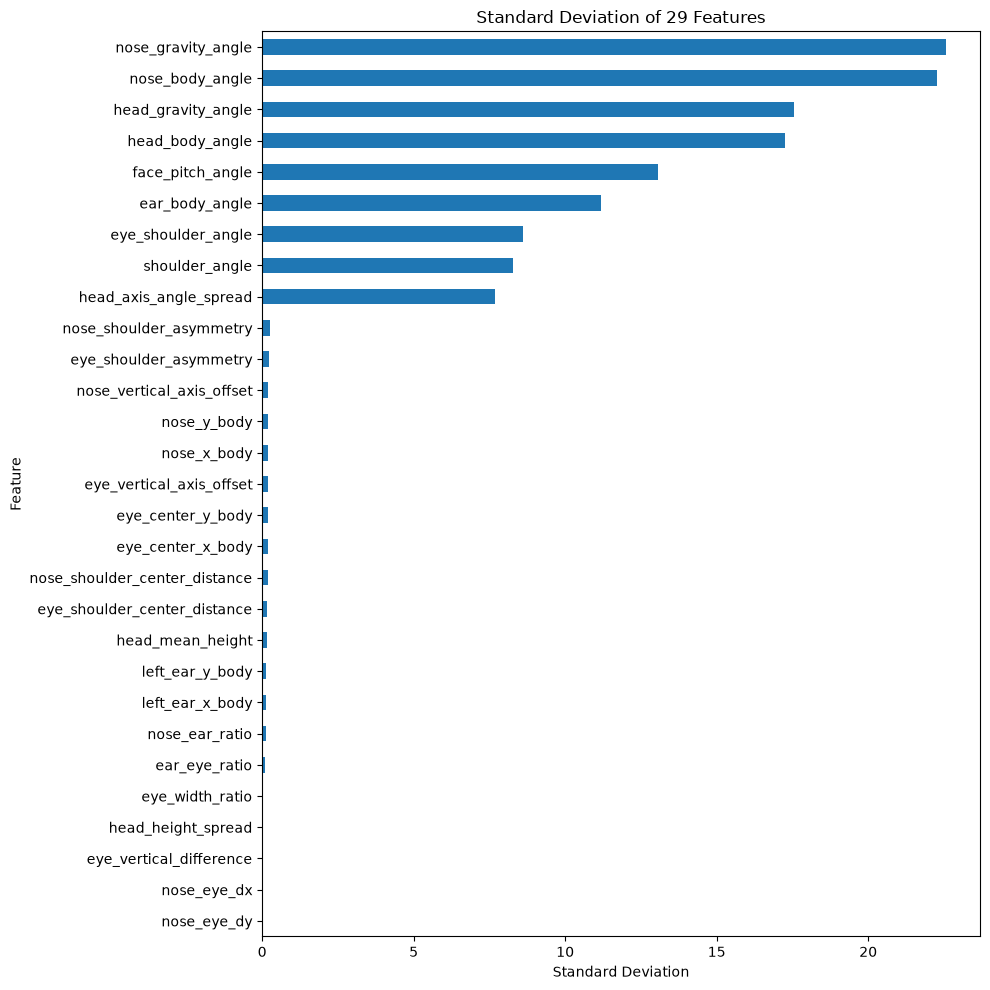

In [50]:
# Vẽ overview độ lệch chuẩn
feature_std_sorted = (
    df[feature_columns]
    .std()
    .sort_values()
)

ax = feature_std_sorted.plot(
    kind="barh",
    figsize=(10, 10)
)

ax.set_title(
    "Standard Deviation of 29 Features"
)

ax.set_xlabel(
    "Standard Deviation"
)

ax.set_ylabel(
    "Feature"
)

plt.tight_layout()
plt.show()

In [51]:
# Feature có magnitude cực lớn
max_abs_values = (
    df[feature_columns]
    .abs()
    .max()
    .sort_values(ascending=False)
)

display(
    max_abs_values.to_frame(
        "max_absolute_value"
    )
)

,max_absolute_value
nose_gravity_angle,151.187698
nose_body_angle,147.840836
head_body_angle,81.456009
head_axis_angle_spread,78.514740
head_gravity_angle,77.567177
face_pitch_angle,52.575855
ear_body_angle,48.184872
eye_shoulder_angle,34.885452
shoulder_angle,33.322411
eye_shoulder_center_distance,2.005326


### Kết luận bước 5 - Statistical Analysis of 29 Features

- Dataset có 29 engineered features và không có constant feature.
- Các features đều có số lượng giá trị unique cao, cho thấy FeatureExtractor V2
  đang tạo ra các biến liên tục và không có dấu hiệu quantization hoặc feature bị kẹt.
- Không có feature nào có tỷ lệ giá trị bằng 0 đáng chú ý.
- Một số feature có variance thấp, nhưng chủ yếu do các feature này được
  normalized và có range nhỏ; chưa có cơ sở để loại bỏ chúng.
- Scale giữa các feature khác nhau đáng kể:
  các angle features có thể nằm trong khoảng hàng chục hoặc hàng trăm độ,
  trong khi ratio, normalized coordinate và distance features chủ yếu nằm
  trong khoảng nhỏ hơn.
- Sự khác biệt scale này không phải vấn đề lớn đối với tree-based models
  như XGBoost, nhưng cần được xem xét khi huấn luyện SVM.
- Một số signed features có phần lớn hoặc toàn bộ giá trị âm.
  Hiện chưa xem đây là bất thường vì dấu có thể phản ánh quy ước hệ tọa độ
  và hướng vector trong công thức feature.
- Một số angle features có range lớn và các giá trị min/max cực đoan.
  Các trường hợp này sẽ được kiểm tra chi tiết hơn trong outlier analysis.
- person05 vẫn được giữ trong EDA. Vì subject này được ghi hình sai camera
  protocol, cần kiểm tra xem các extreme values có liên quan đến person05 hay không.

Chưa có feature nào cần loại bỏ ở bước này.

## 6. Feature Distribution by Posture Class

Mục tiêu:
- So sánh phân phối của 29 engineered features giữa 4 posture classes.
- Quan sát mean, median và độ phân tán theo từng class.
- Xác định các feature có dấu hiệu tạo pattern khác nhau giữa các posture.
- Phát hiện các feature có phân phối chồng lấn mạnh.
- Chuẩn bị cho class-separation analysis ở bước sau.

Lưu ý:
- Đây là descriptive analysis.
- Chưa loại bỏ feature dựa trên biểu đồ.
- person05 vẫn được giữ trong EDA dataset.

In [52]:
# Thống kê mean theo class
class_feature_mean = (
    df.groupby("label")[feature_columns]
    .mean()
    .reindex(EXPECTED_CLASSES)
)

display(class_feature_mean)

,shoulder_angle,eye_shoulder_angle,eye_vertical_difference,nose_x_body,nose_y_body,eye_center_x_body,eye_center_y_body,left_ear_x_body,left_ear_y_body,nose_eye_dx,...,head_gravity_angle,nose_gravity_angle,face_pitch_angle,eye_vertical_axis_offset,nose_vertical_axis_offset,head_mean_height,head_height_spread,nose_body_angle,ear_body_angle,head_axis_angle_spread
label,,,,,,,,,,,,,,,,,,,,,
correct,1.891029,-8.011656,-0.027530,0.349985,0.667750,0.310224,0.782071,-0.114087,0.723051,0.039762,...,-19.109641,-24.929543,19.520819,-0.284990,-0.328764,0.724291,0.057247,26.820571,-9.452470,15.916010
forward_slouch,1.079107,-6.641931,-0.023707,0.480026,0.397474,0.445508,0.542414,-0.046978,0.599523,0.034517,...,-40.754351,-53.421597,13.164019,-0.431938,-0.468810,0.513137,0.092982,54.500704,-6.178473,26.245535
lean_left,8.844270,-10.050661,-0.032605,0.257739,0.458660,0.242715,0.580072,-0.140113,0.600890,0.015025,...,-13.782308,-19.937524,7.328048,-0.147762,-0.180549,0.546541,0.072519,28.781793,-13.108616,18.526623
lean_right,-7.107595,-1.694070,-0.004420,0.286127,0.568992,0.254727,0.694482,-0.156506,0.654938,0.031400,...,-27.303671,-33.661721,14.216832,-0.350576,-0.367654,0.639471,0.078204,26.554126,-13.313196,17.519944


In [53]:
# Median theo class
class_feature_median = (
    df.groupby("label")[feature_columns]
    .median()
    .reindex(EXPECTED_CLASSES)
)

display(class_feature_median)

,shoulder_angle,eye_shoulder_angle,eye_vertical_difference,nose_x_body,nose_y_body,eye_center_x_body,eye_center_y_body,left_ear_x_body,left_ear_y_body,nose_eye_dx,...,head_gravity_angle,nose_gravity_angle,face_pitch_angle,eye_vertical_axis_offset,nose_vertical_axis_offset,head_mean_height,head_height_spread,nose_body_angle,ear_body_angle,head_axis_angle_spread
label,,,,,,,,,,,,,,,,,,,,,
correct,0.894398,-8.052505,-0.027526,0.350896,0.675204,0.313345,0.780998,-0.113927,0.710972,0.041041,...,-20.415022,-26.394571,19.151617,-0.285240,-0.331745,0.727554,0.053798,27.971193,-8.727755,16.117533
forward_slouch,0.435091,-5.707738,-0.020709,0.468192,0.457905,0.449315,0.609295,-0.055213,0.646128,0.035099,...,-37.036320,-47.716079,13.775215,-0.440469,-0.462956,0.573171,0.083573,49.520365,-4.724202,21.598188
lean_left,9.588366,-11.704154,-0.039781,0.280478,0.476202,0.257642,0.596283,-0.134672,0.604054,0.014155,...,-17.165430,-23.274056,6.080576,-0.165181,-0.181966,0.537448,0.061324,32.838443,-12.293523,18.329481
lean_right,-7.279265,-0.469598,-0.001805,0.256549,0.546378,0.212143,0.664176,-0.195763,0.620543,0.027737,...,-25.506808,-32.416639,11.861357,-0.327950,-0.346400,0.603399,0.064251,21.569848,-15.979259,16.587660


In [54]:
# Standard deviation theo class
class_feature_std = (
    df.groupby("label")[feature_columns]
    .std()
    .reindex(EXPECTED_CLASSES)
)

display(class_feature_std)

,shoulder_angle,eye_shoulder_angle,eye_vertical_difference,nose_x_body,nose_y_body,eye_center_x_body,eye_center_y_body,left_ear_x_body,left_ear_y_body,nose_eye_dx,...,head_gravity_angle,nose_gravity_angle,face_pitch_angle,eye_vertical_axis_offset,nose_vertical_axis_offset,head_mean_height,head_height_spread,nose_body_angle,ear_body_angle,head_axis_angle_spread
label,,,,,,,,,,,,,,,,,,,,,
correct,3.252031,5.984296,0.022493,0.160992,0.126338,0.148874,0.122277,0.077675,0.113246,0.019563,...,7.460216,9.128864,10.053784,0.135106,0.149886,0.115340,0.013267,10.207799,6.769316,2.071968
forward_slouch,4.178675,7.277430,0.025146,0.167982,0.238958,0.154820,0.235821,0.114046,0.152439,0.026792,...,15.893190,23.433866,11.112494,0.147788,0.163433,0.206503,0.035466,22.999256,12.900650,11.769707
lean_left,5.910174,8.564570,0.026889,0.169291,0.113105,0.155313,0.095778,0.098907,0.056344,0.028204,...,17.224321,21.475165,13.929143,0.190891,0.200582,0.077809,0.031607,18.647776,9.110624,5.045778
lean_right,8.567052,9.603807,0.034833,0.223076,0.207528,0.225389,0.192814,0.158899,0.121154,0.029392,...,15.274223,18.515015,13.398758,0.196970,0.203714,0.164612,0.034175,22.483570,13.299718,4.718245


In [55]:
# Tạo bảng thống kê gọn theo feature × class
class_feature_summary = (
    df.groupby("label")[feature_columns]
    .agg(["mean", "median", "std"])
)

class_feature_summary

shoulder_angle                     eye_shoulder_angle  \
                         mean    median       std               mean   
label                                                                  
correct              1.891029  0.894398  3.252031          -8.011656   
forward_slouch       1.079107  0.435091  4.178675          -6.641931   
lean_left            8.844270  9.588366  5.910174         -10.050661   
lean_right          -7.107595 -7.279265  8.567052          -1.694070   

                                    eye_vertical_difference            \
                   median       std                    mean    median   
label                                                                   
correct         -8.052505  5.984296               -0.027530 -0.027526   
forward_slouch  -5.707738  7.277430               -0.023707 -0.020709   
lean_left      -11.704154  8.564570               -0.032605 -0.039781   
lean_right      -0.469598  9.603807               -0.004420 -0.001805   

                         nose_x_body  ... head_height_spread nose_body_angle  \
                     std        mean  ...                std            mean   
label                                 ...                                      
correct         0.022493    0.349985  ...           0.013267       26.820571   
forward_slouch  0.025146    0.480026  ...           0.035466       54.500704   
lean_left       0.026889    0.257739  ...           0.031607       28.781793   
lean_right      0.034833    0.286127  ...           0.034175       26.554126   

                                     ear_body_angle                        \
                   median        std           mean     median        std   
label                                                                       
correct         27.971193  10.207799      -9.452470  -8.727755   6.769316   
forward_slouch  49.520365  22.999256      -6.178473  -4.724202  12.900650   
lean_left       32.838443  18.647776     -13.108616 -12.293523   9.110624   
lean_right      21.569848  22.483570     -13.313196 -15.979259  13.299718   

               head_axis_angle_spread                        
                                 mean     median        std  
label                                                        
correct                     15.916010  16.117533   2.071968  
forward_slouch              26.245535  21.598188  11.769707  
lean_left                   18.526623  18.329481   5.045778  
lean_right                  17.519944  16.587660   4.718245  

[4 rows x 87 columns]

In [56]:
# Hàm xem một feature theo class
def show_feature_by_class(feature):
    summary = (
        df.groupby("label")[feature]
        .agg(["count", "mean", "median", "std", "min", "max"])
        .reindex(EXPECTED_CLASSES)
    )

    display(summary)

In [57]:
# Boxplot của một feature theo class
def plot_feature_boxplot(feature):
    data = [
        df.loc[df["label"] == label, feature].values
        for label in EXPECTED_CLASSES
    ]

    plt.figure(figsize=(8, 5))

    plt.boxplot(
        data,
        tick_labels=EXPECTED_CLASSES,
        showfliers=True
    )

    plt.title(f"{feature} by Posture Class")
    plt.xlabel("Posture Class")
    plt.ylabel(feature)

    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()

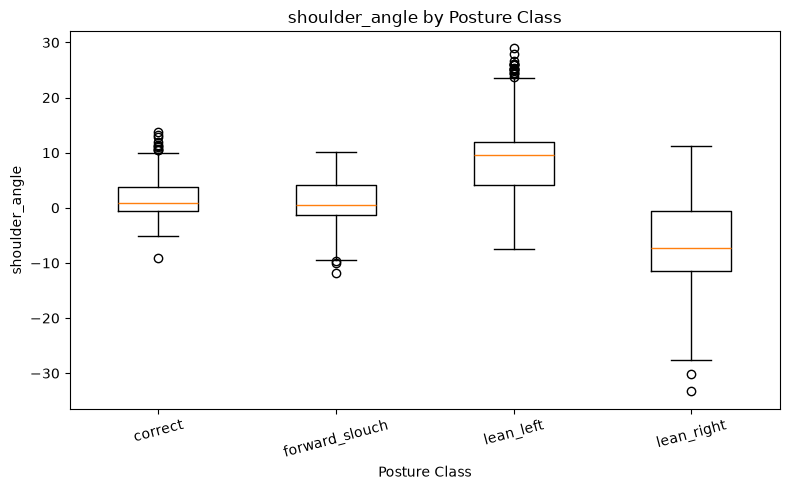

In [58]:
plot_feature_boxplot("shoulder_angle")

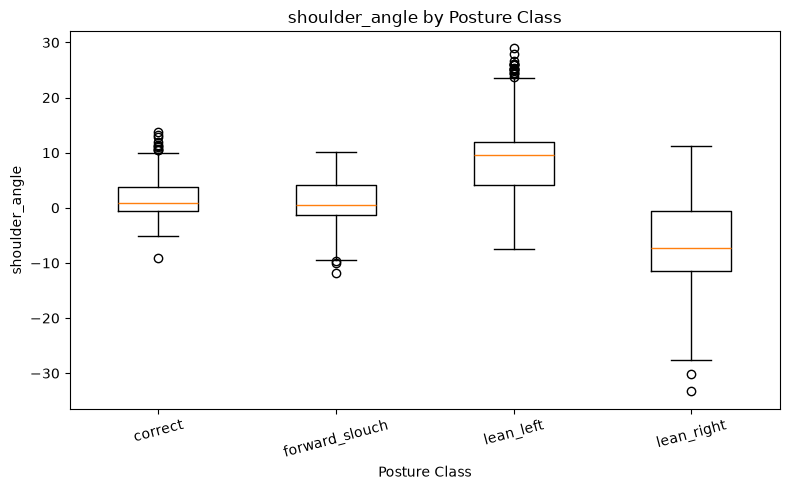

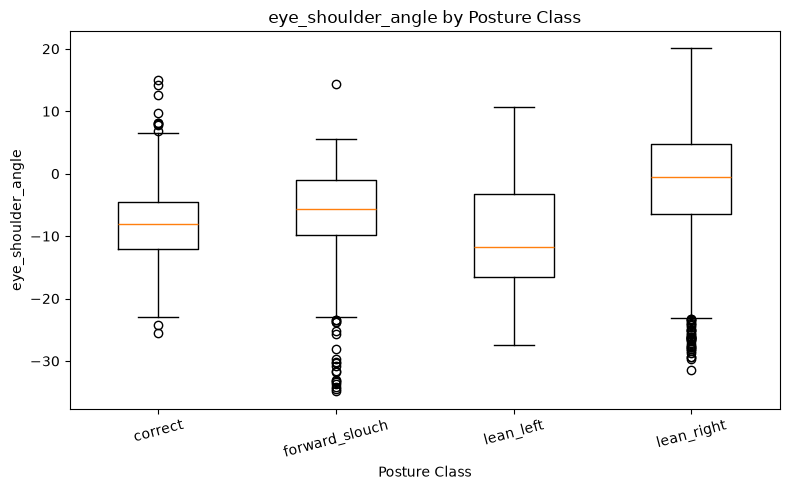

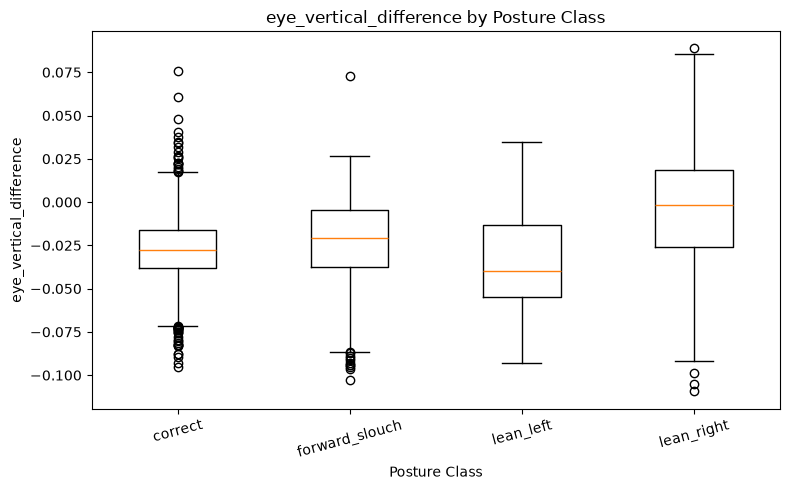

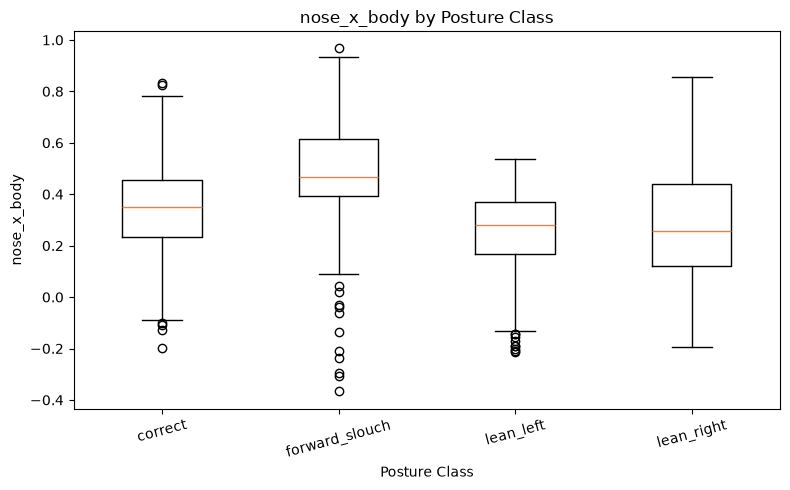

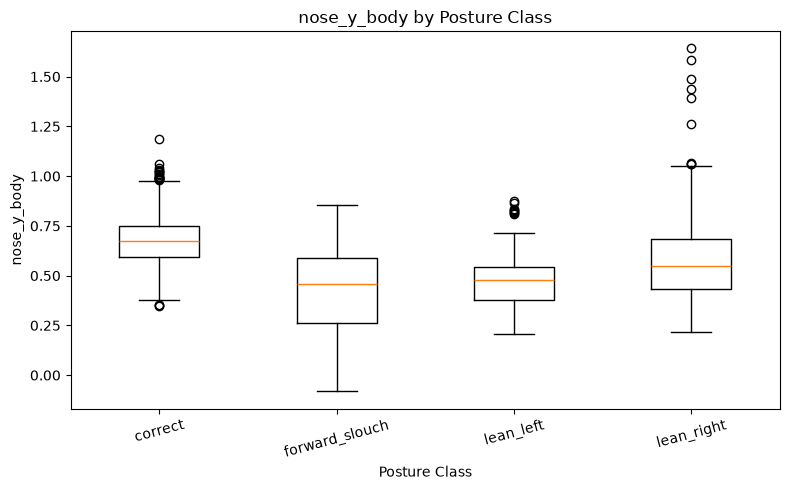

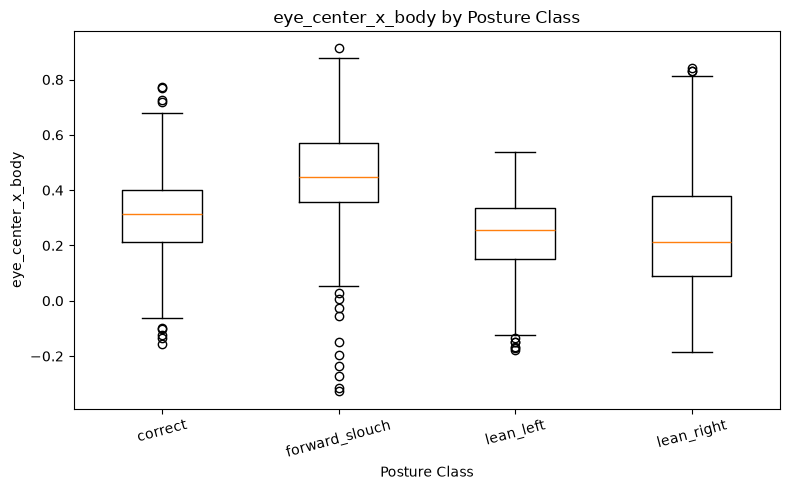

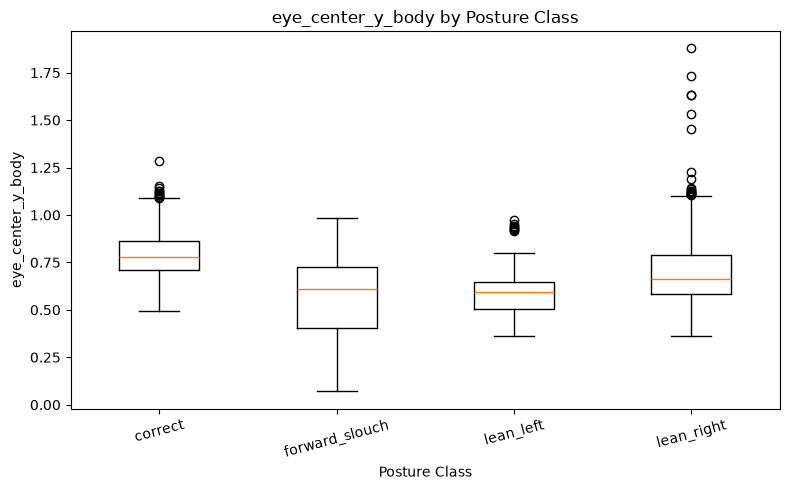

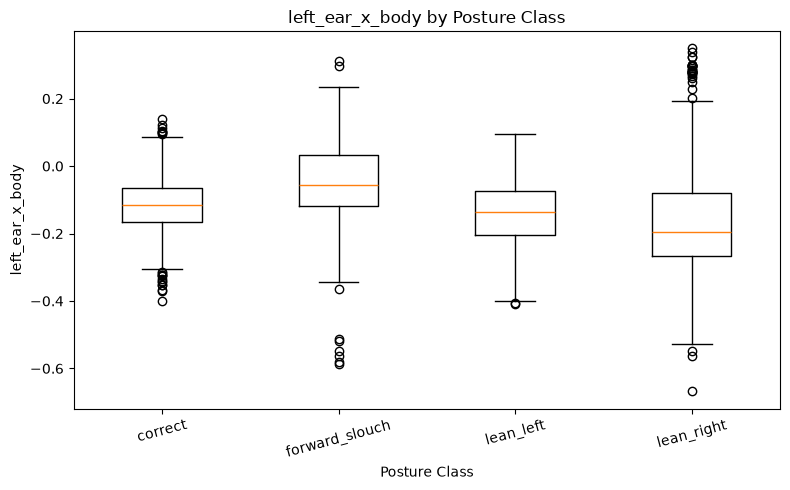

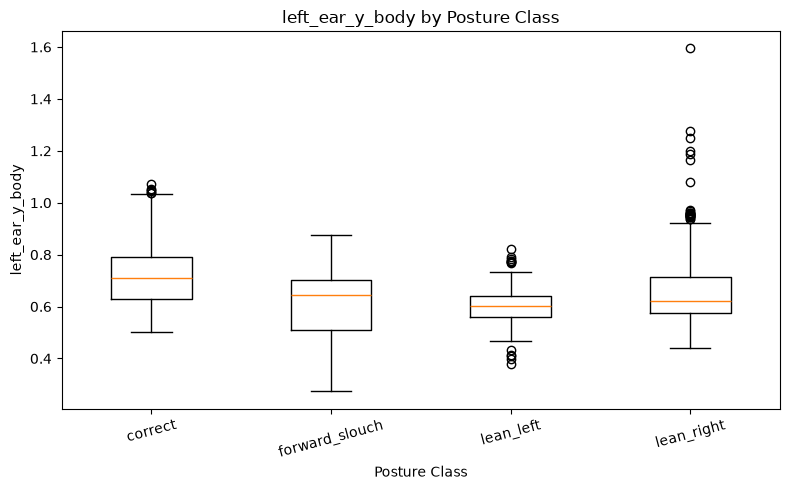

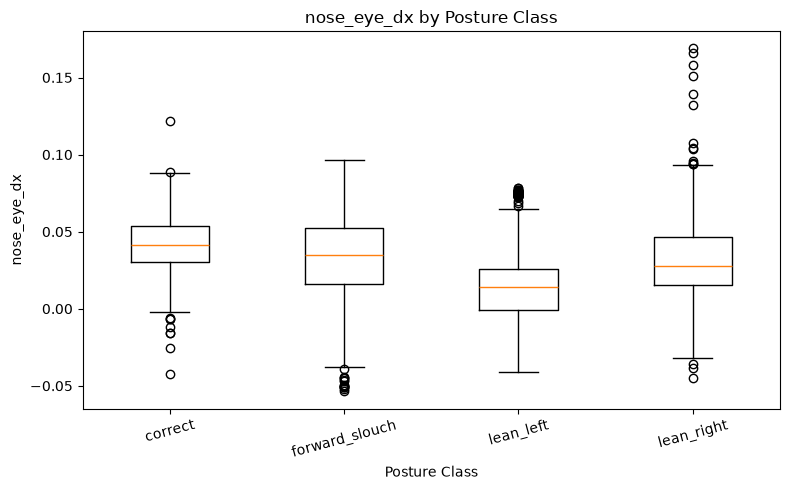

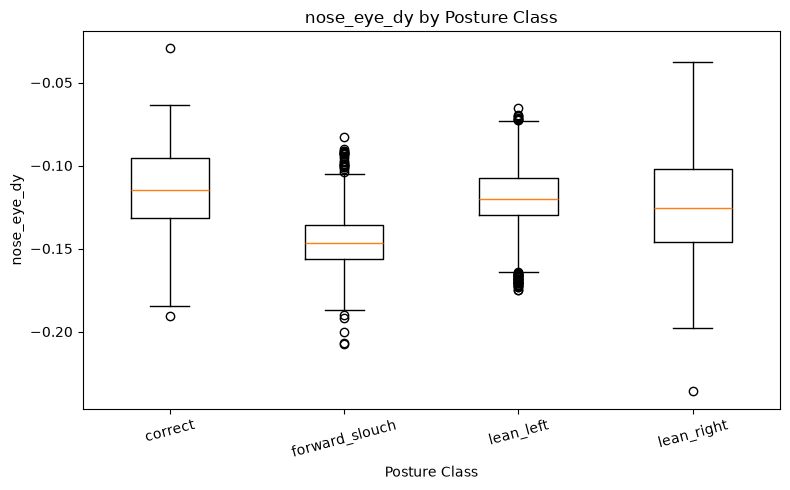

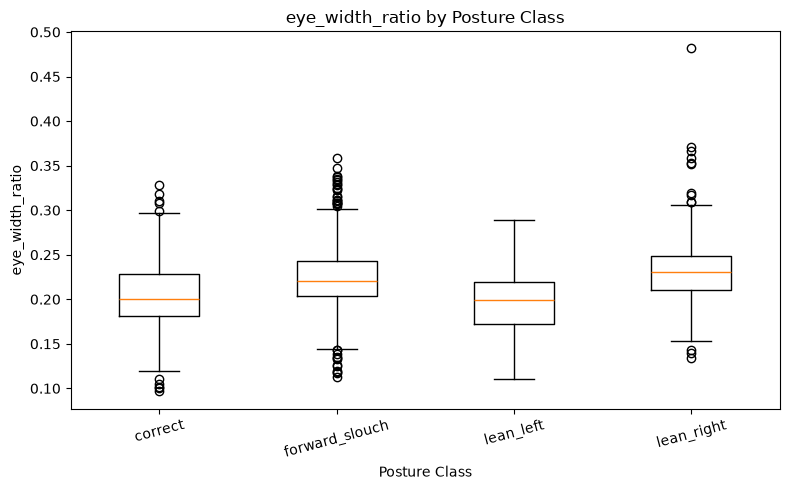

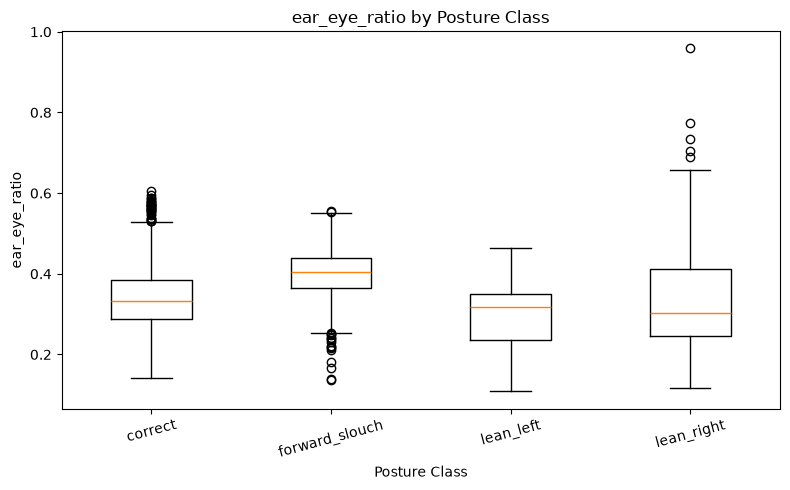

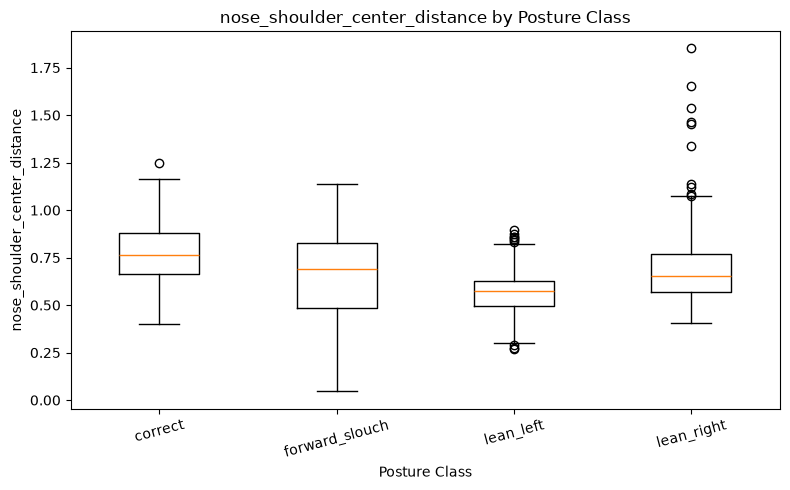

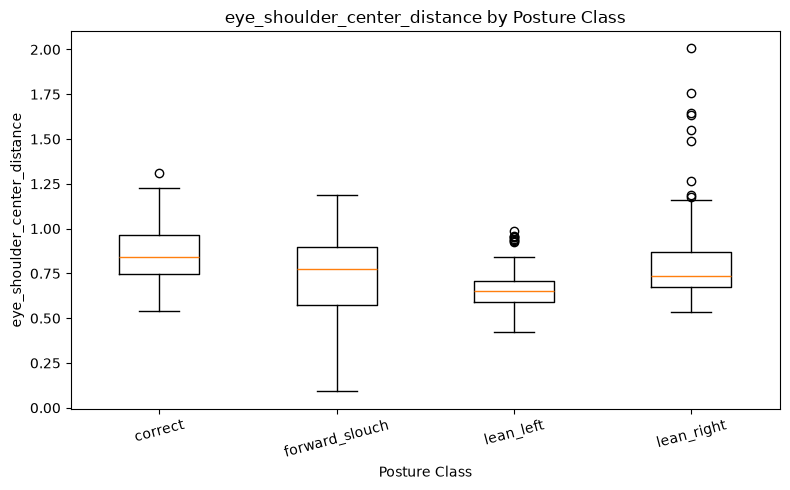

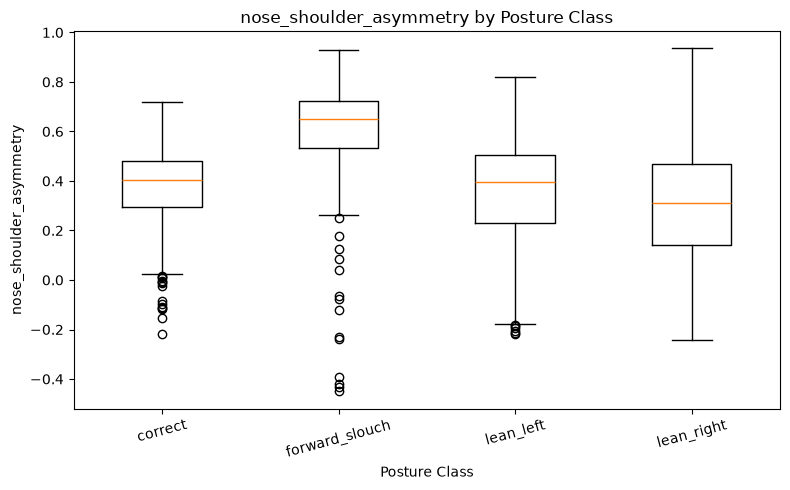

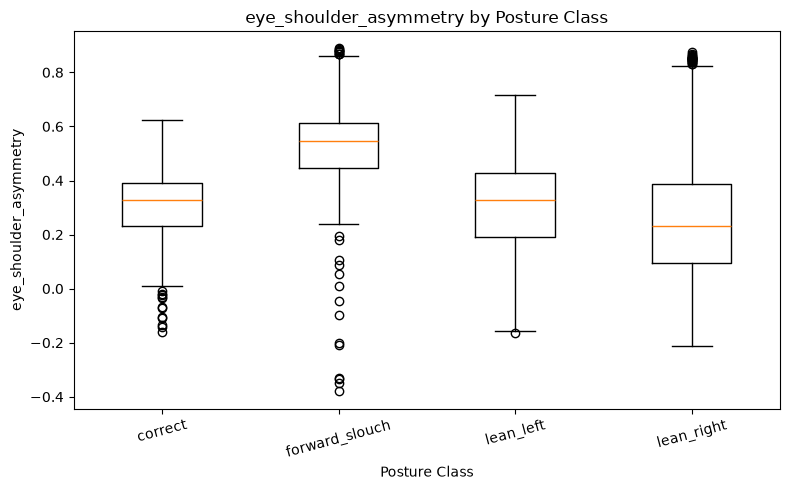

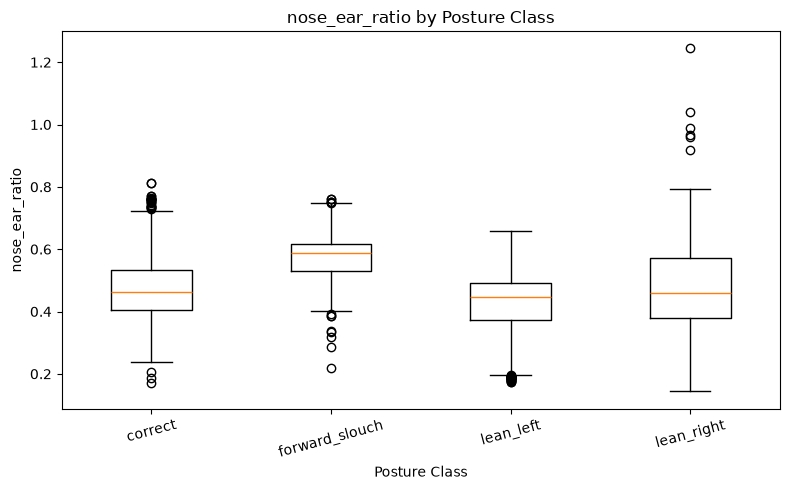

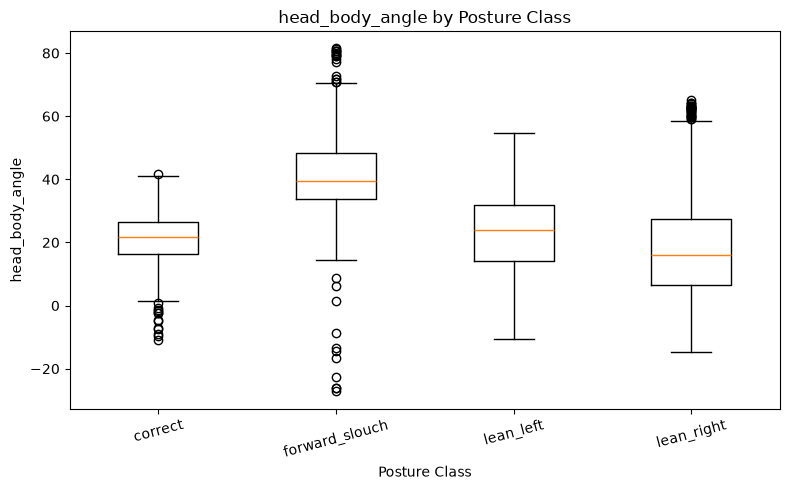

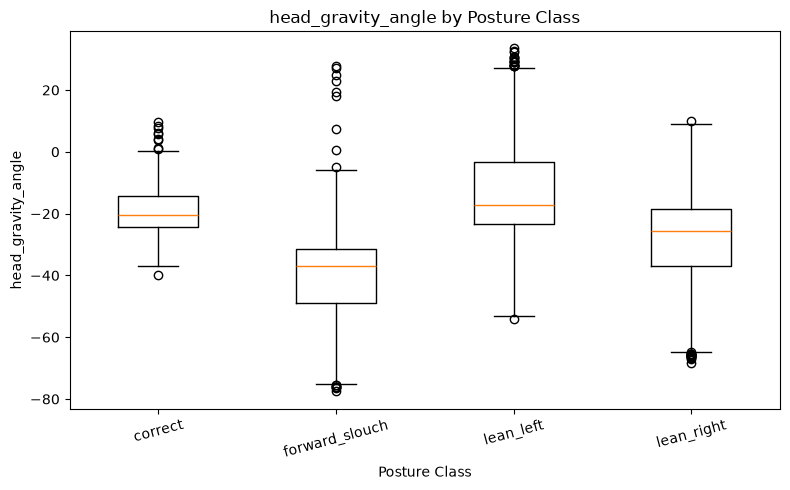

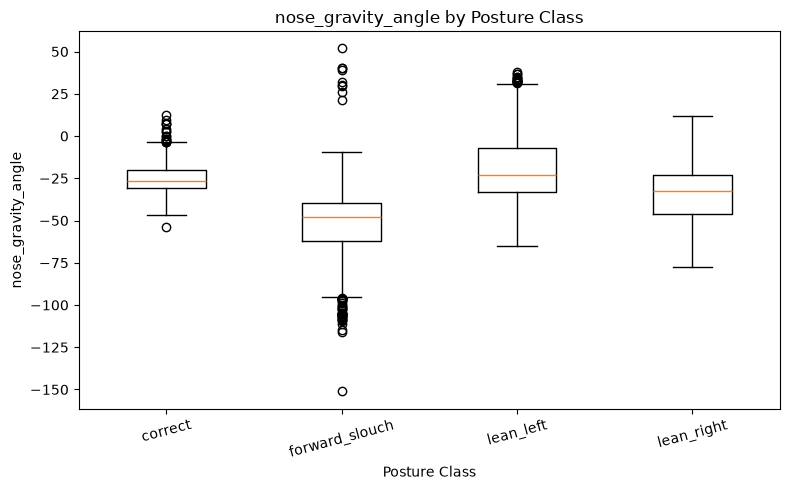

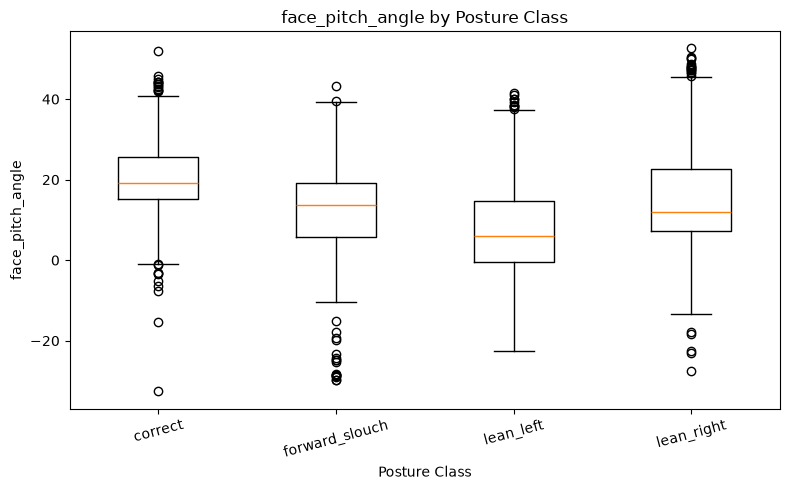

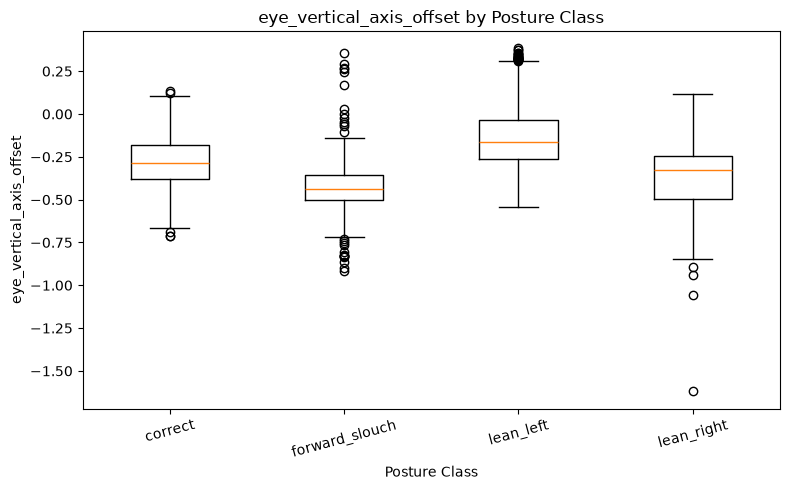

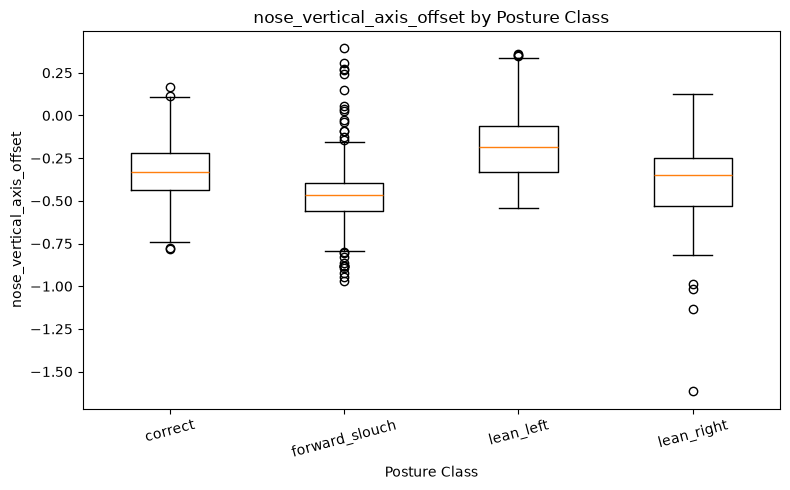

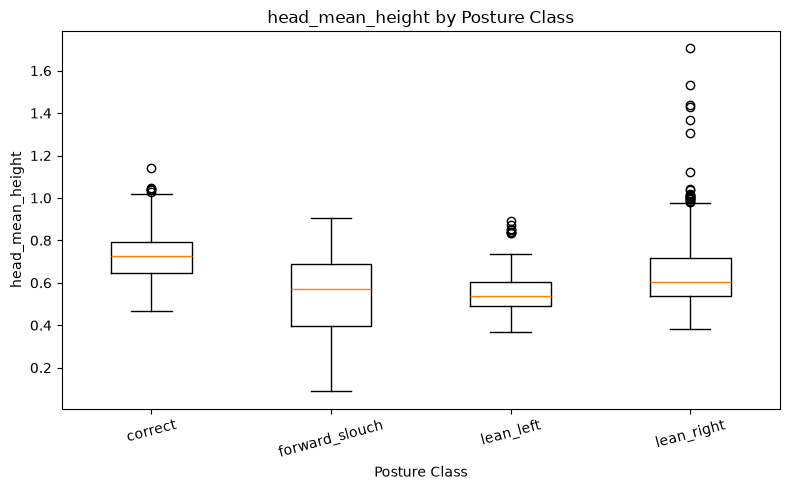

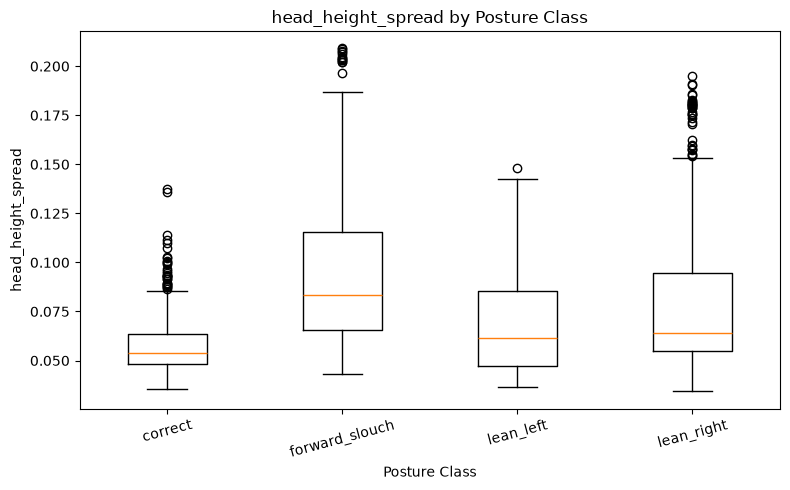

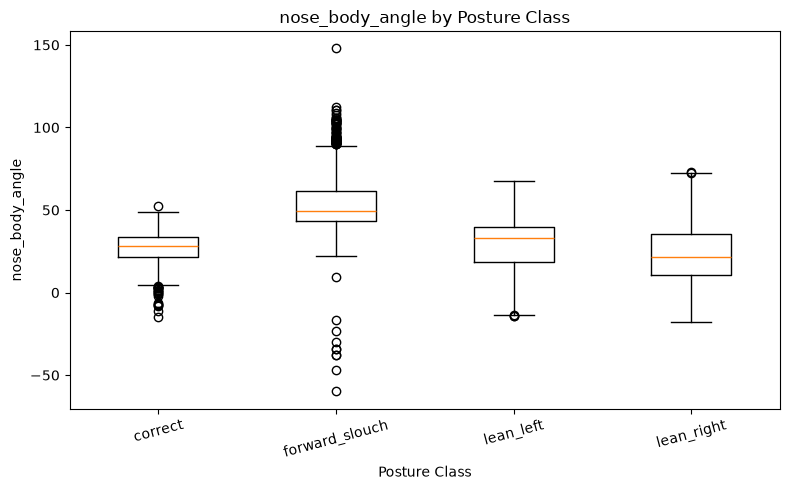

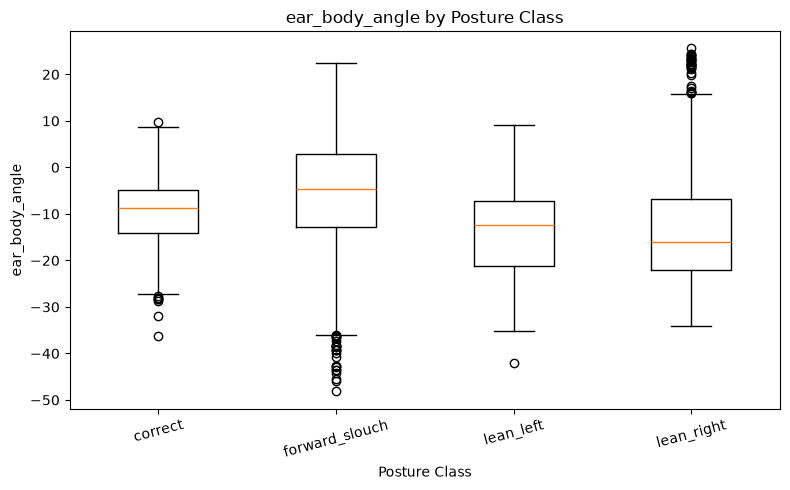

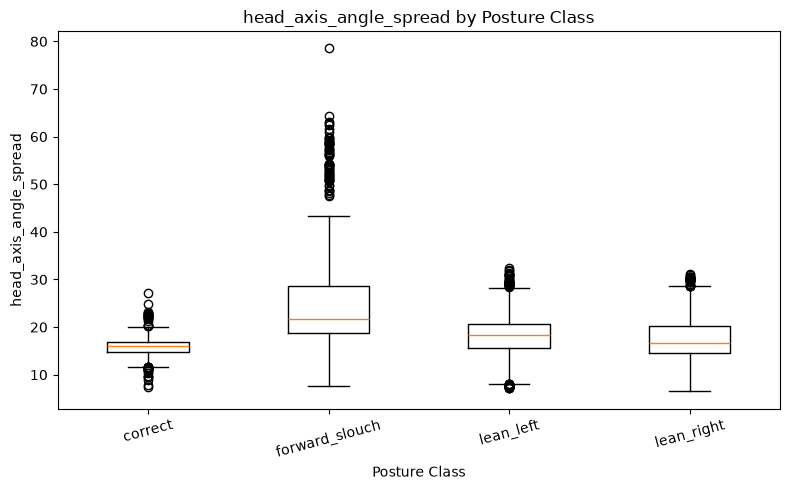

In [59]:
# Plot toàn bộ 29 features
for feature in feature_columns:
    plot_feature_boxplot(feature)

In [60]:
# Tạo histogram theo 4 class
def plot_feature_histogram(feature, bins=30):
    plt.figure(figsize=(9, 5))

    for label in EXPECTED_CLASSES:
        values = df.loc[
            df["label"] == label,
            feature
        ]

        plt.hist(
            values,
            bins=bins,
            alpha=0.4,
            density=True,
            label=label
        )

    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Density")

    plt.legend()
    plt.tight_layout()
    plt.show()

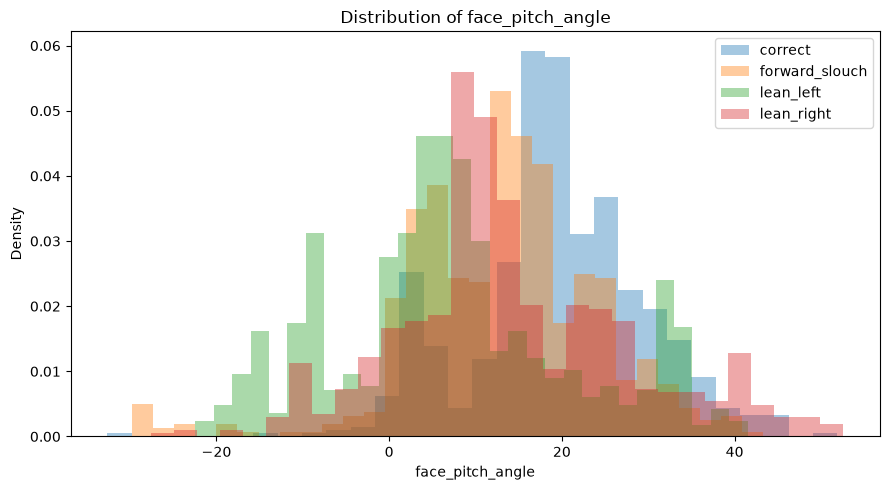

In [61]:
plot_feature_histogram("face_pitch_angle")

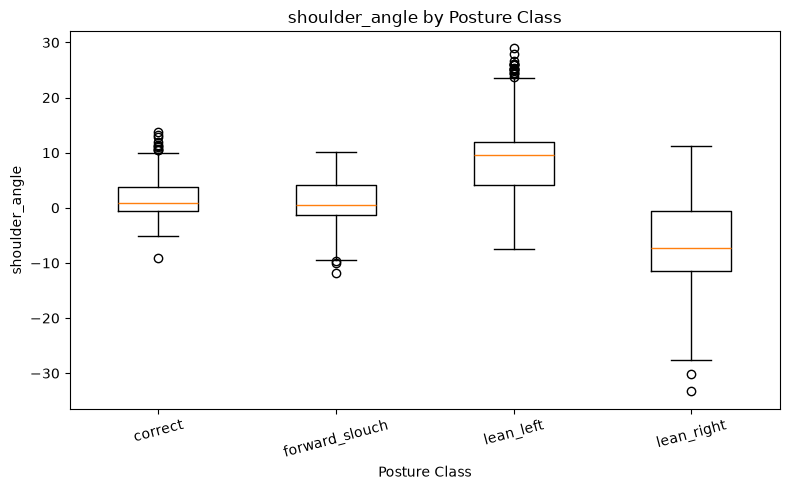

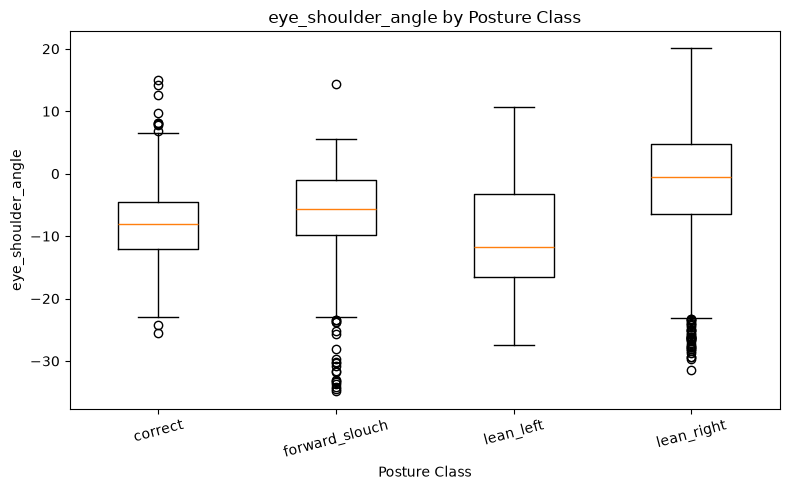

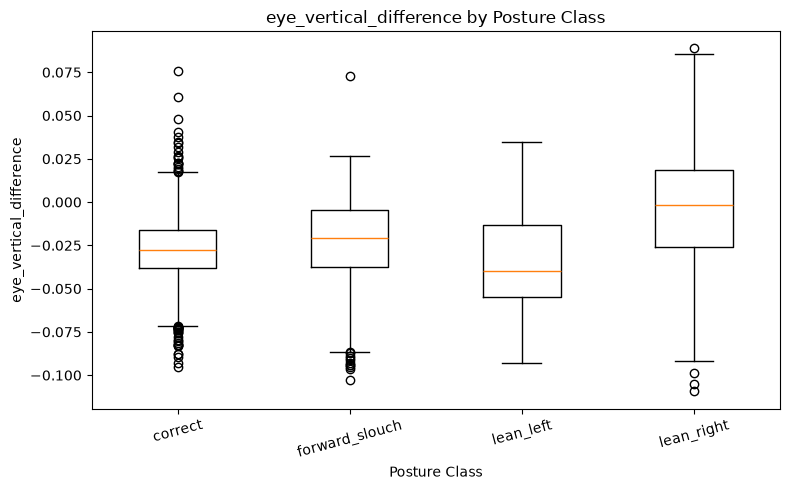

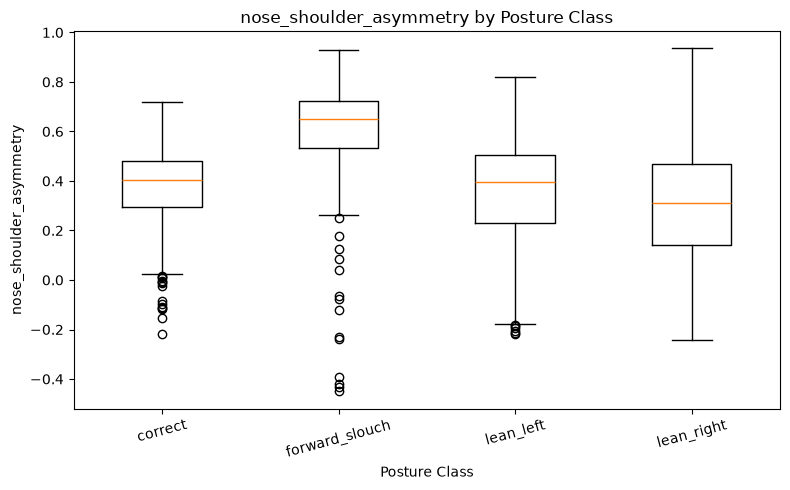

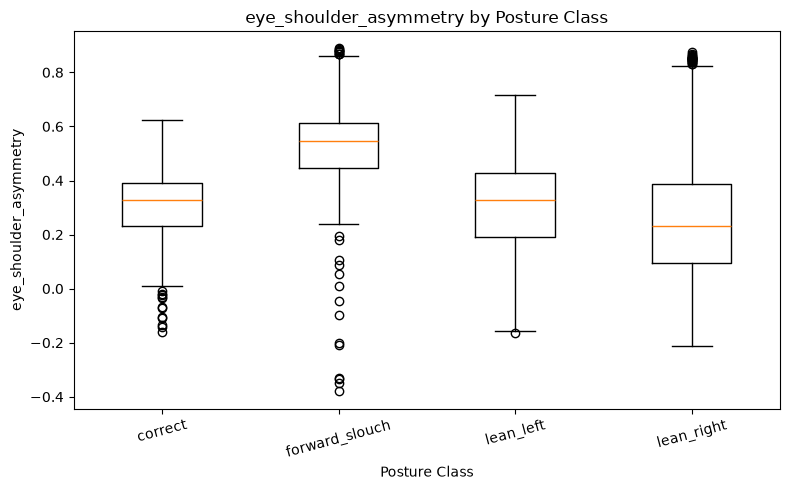

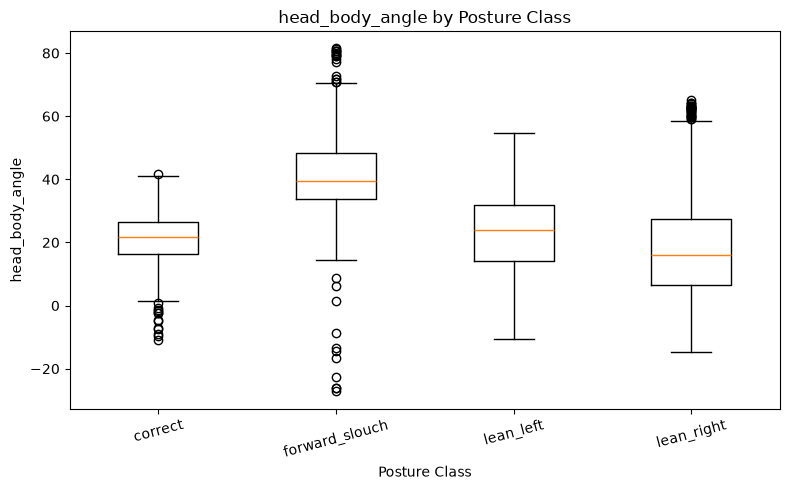

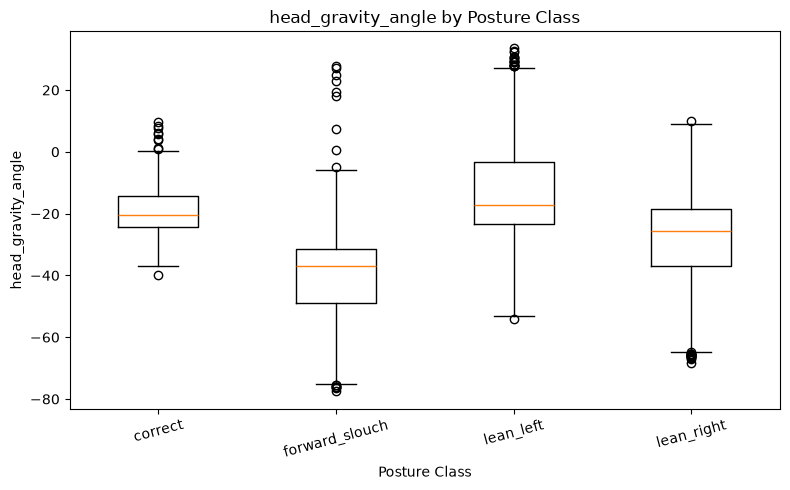

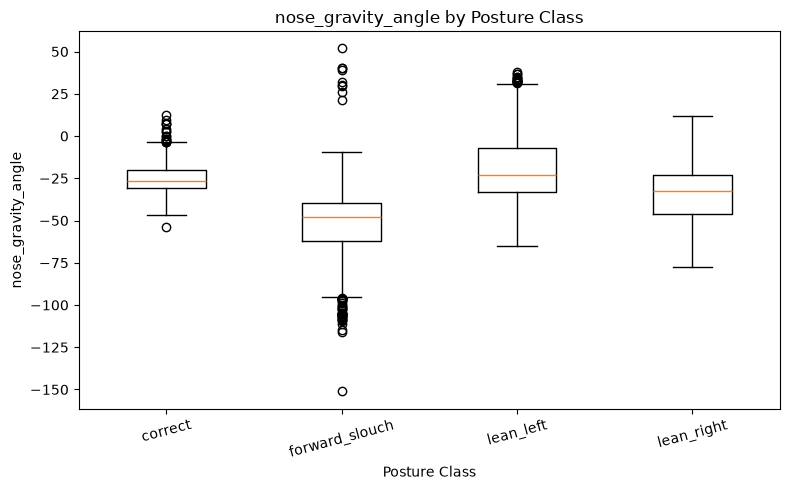

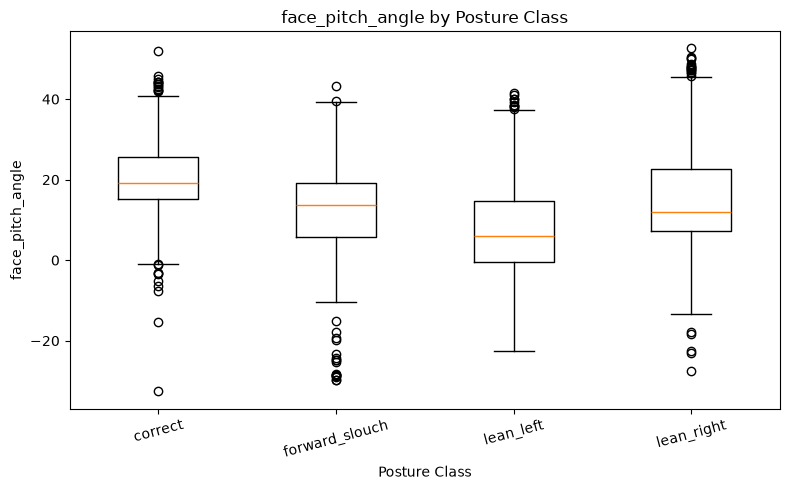

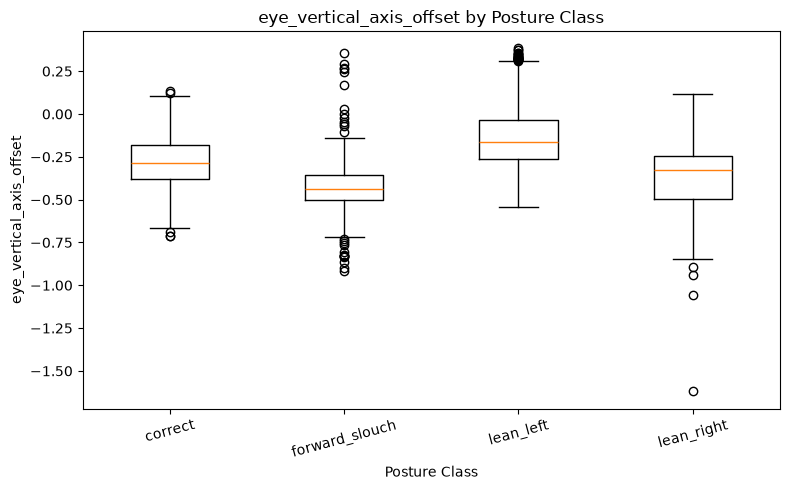

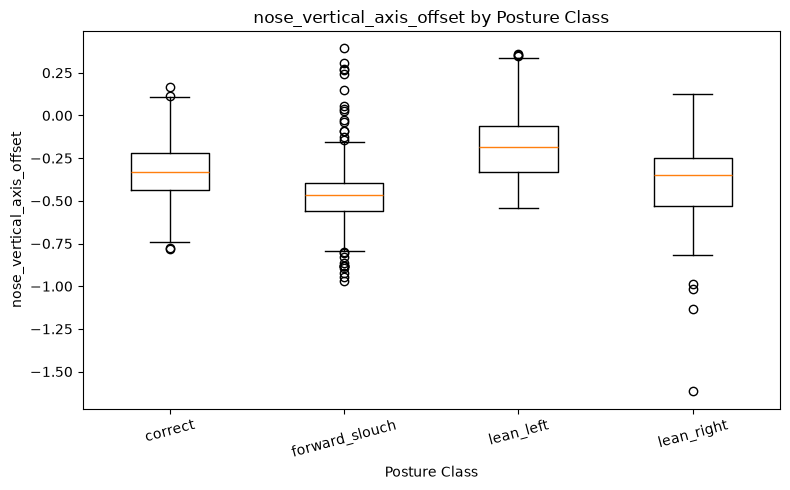

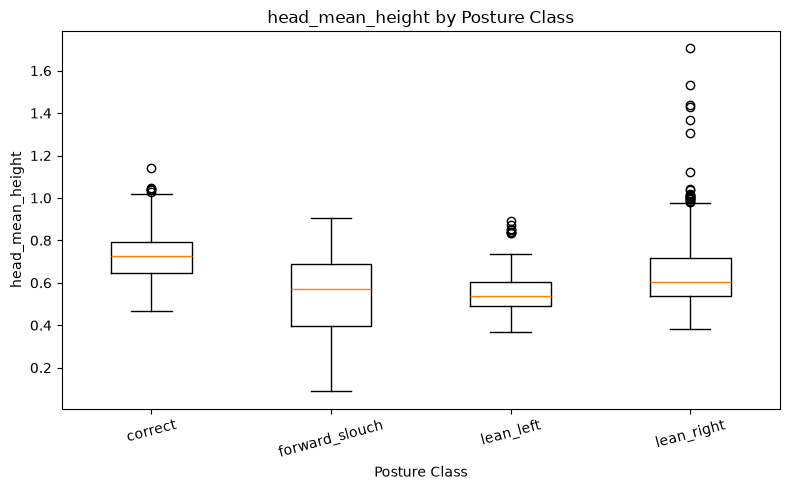

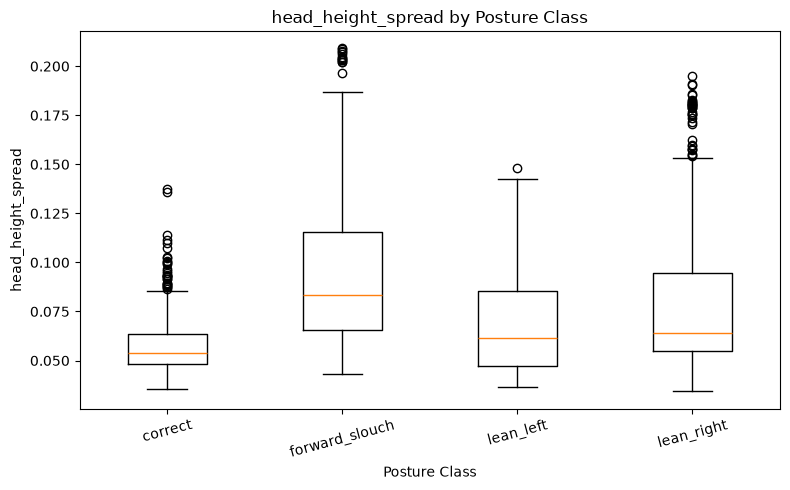

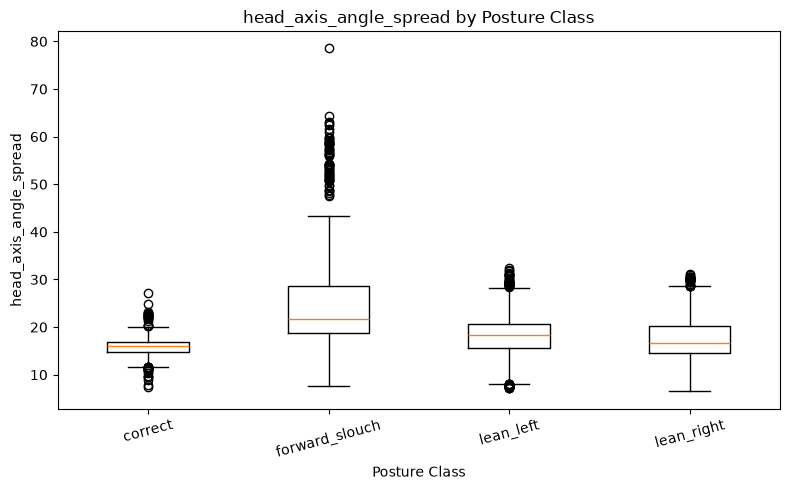

In [63]:
# Chọn một số feature quan trọng để xem trước
features_to_inspect = [
    "shoulder_angle",
    "eye_shoulder_angle",
    "eye_vertical_difference",

    "nose_shoulder_asymmetry",
    "eye_shoulder_asymmetry",

    "head_body_angle",
    "head_gravity_angle",
    "nose_gravity_angle",
    "face_pitch_angle",

    "eye_vertical_axis_offset",
    "nose_vertical_axis_offset",

    "head_mean_height",
    "head_height_spread",
    "head_axis_angle_spread",
]

for feature in features_to_inspect:
    plot_feature_boxplot(feature)

In [64]:
# Tính độ chênh median giữa các class
median_spread = (
    class_feature_median.max(axis=0)
    - class_feature_median.min(axis=0)
)

median_spread = median_spread.sort_values(
    ascending=False
)

display(
    median_spread.to_frame(
        "class_median_spread"
    )
)

,class_median_spread
nose_body_angle,27.950517
nose_gravity_angle,24.442024
head_body_angle,23.328719
head_gravity_angle,19.870890
shoulder_angle,16.867631
face_pitch_angle,13.071041
ear_body_angle,11.255057
eye_shoulder_angle,11.234556
head_axis_angle_spread,5.480655
nose_shoulder_asymmetry,0.337754


In [65]:
# Normalized separation để so feature công bằng hơn
normalized_median_spread = (
    median_spread
    / df[feature_columns].std()
)

normalized_median_spread = (
    normalized_median_spread
    .sort_values(ascending=False)
)

display(
    normalized_median_spread.to_frame(
        "normalized_median_spread"
    )
)

,normalized_median_spread
shoulder_angle,2.040871
eye_shoulder_asymmetry,1.434122
eye_vertical_axis_offset,1.377587
nose_shoulder_asymmetry,1.359385
head_body_angle,1.351312
nose_vertical_axis_offset,1.345242
eye_shoulder_angle,1.305627
eye_vertical_difference,1.271333
nose_body_angle,1.255698
eye_center_x_body,1.240396


,normalized_median_spread
shoulder_angle,2.040871
eye_shoulder_asymmetry,1.434122
eye_vertical_axis_offset,1.377587
nose_shoulder_asymmetry,1.359385
head_body_angle,1.351312
nose_vertical_axis_offset,1.345242
eye_shoulder_angle,1.305627
eye_vertical_difference,1.271333
nose_body_angle,1.255698
eye_center_x_body,1.240396


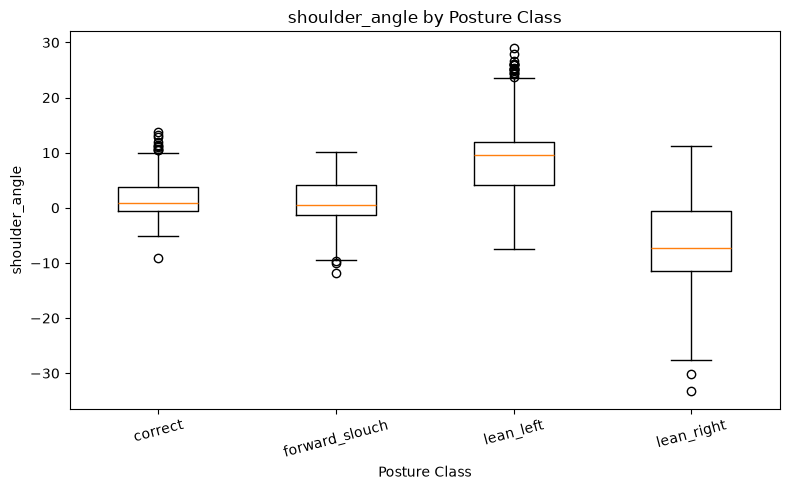

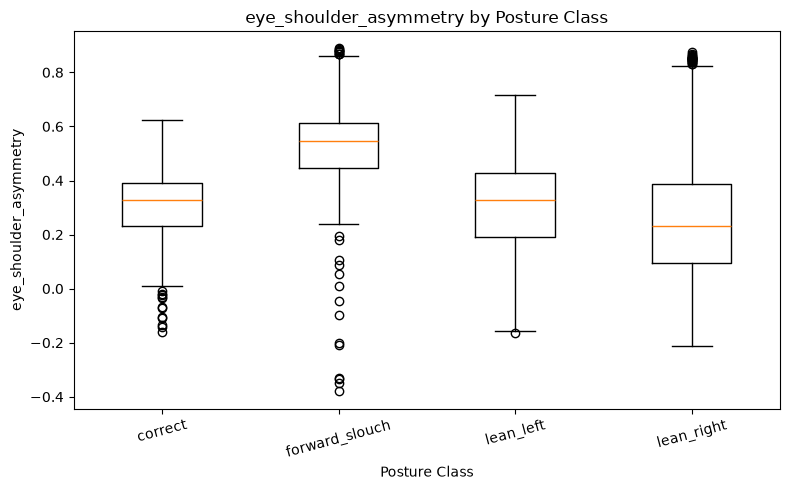

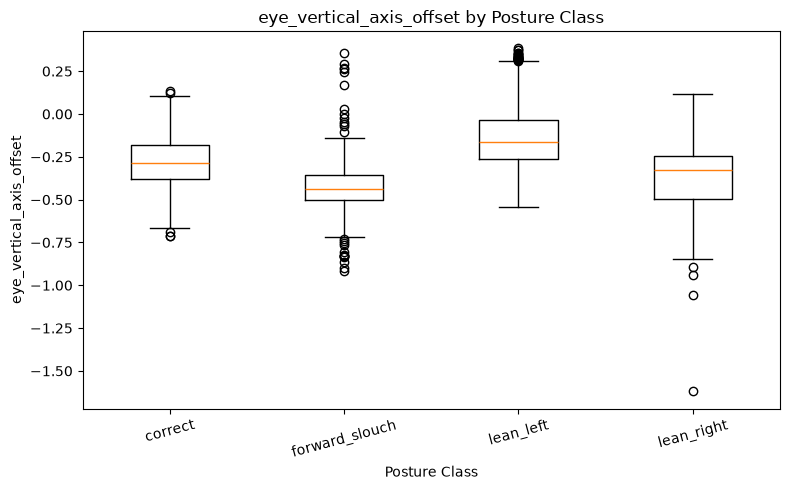

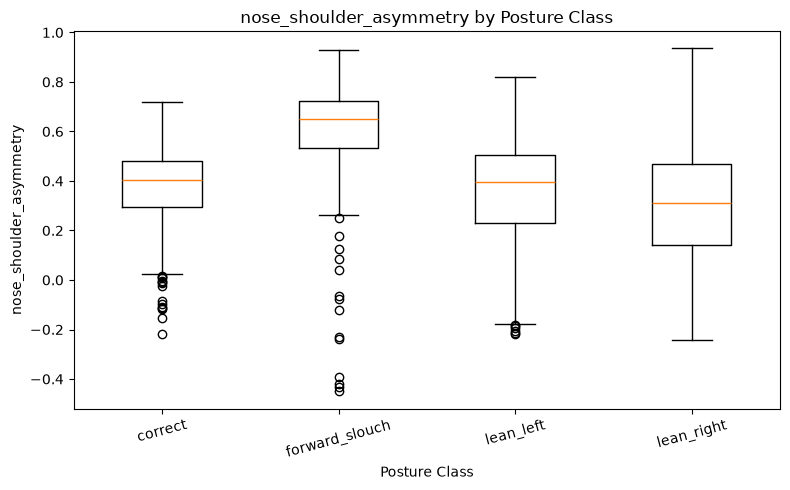

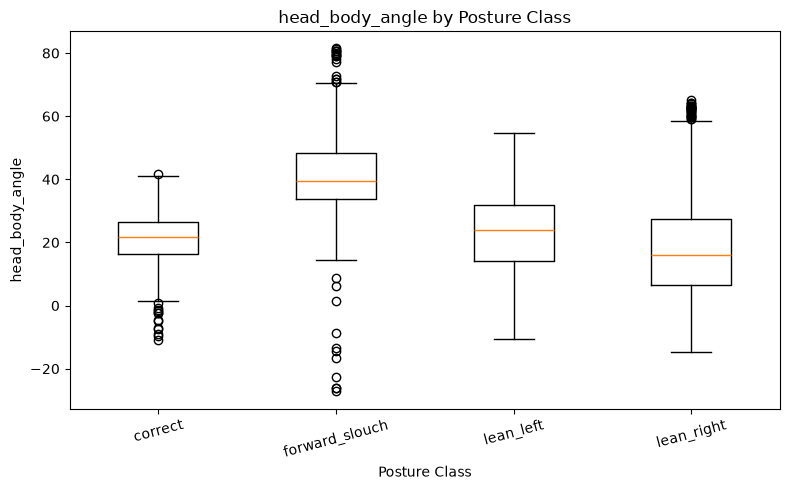

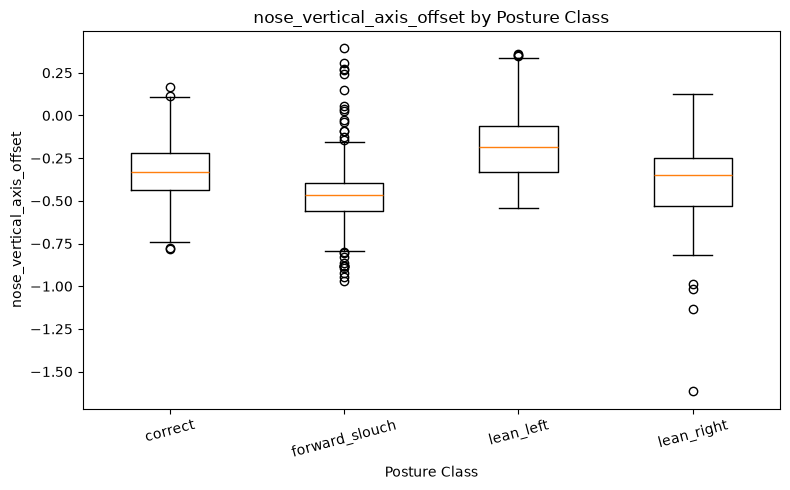

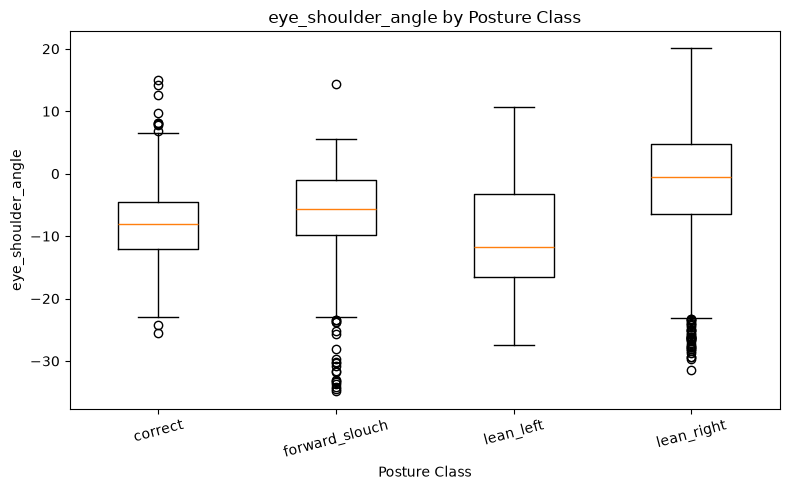

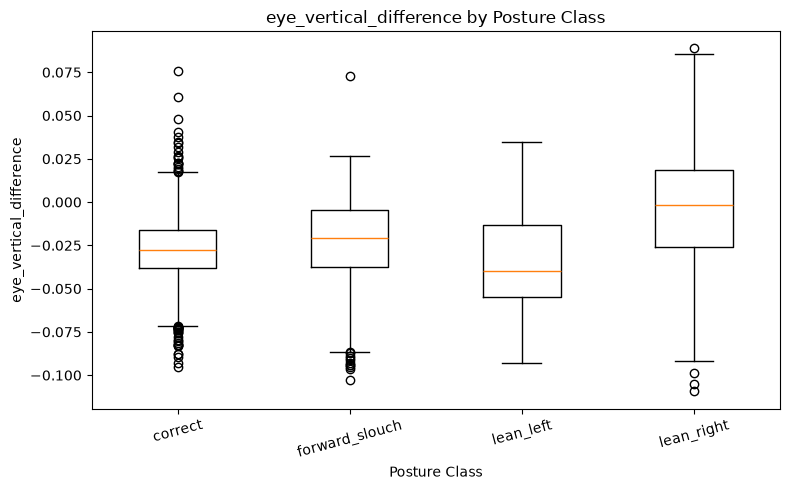

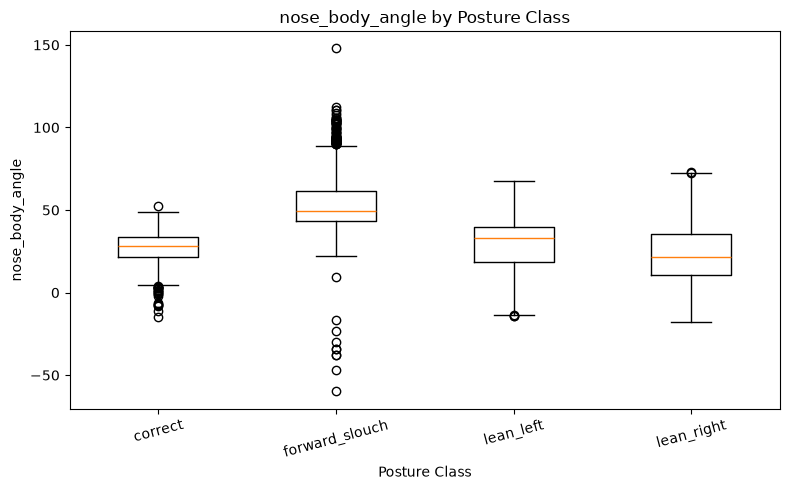

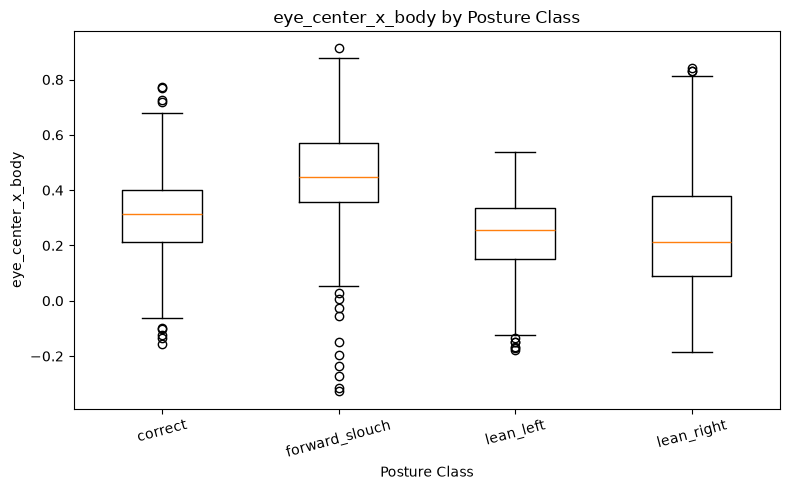

In [66]:
# Xem top feature theo metric mô tả này
top_distribution_features = (
    normalized_median_spread
    .head(10)
)

display(
    top_distribution_features.to_frame(
        "normalized_median_spread"
    )
)

# Vẽ boxplot cho top 10
for feature in top_distribution_features.index:
    plot_feature_boxplot(feature)

In [67]:
# Kiểm tra bottom features
bottom_distribution_features = (
    normalized_median_spread
    .tail(10)
)

display(
    bottom_distribution_features.to_frame(
        "normalized_median_spread"
    )
)

,normalized_median_spread
nose_x_body,1.054951
nose_shoulder_center_distance,1.047331
ear_body_angle,1.007881
face_pitch_angle,1.001513
nose_eye_dx,0.962886
eye_center_y_body,0.960057
head_height_spread,0.919762
left_ear_y_body,0.856124
eye_width_ratio,0.834168
head_axis_angle_spread,0.712585


,count,mean,median,std,min,max
label,,,,,,
correct,743,1.891029,0.894398,3.252031,-9.149232,13.672068
forward_slouch,658,1.079107,0.435091,4.178675,-11.887459,10.146695
lean_left,782,8.844270,9.588366,5.910174,-7.382310,28.911543
lean_right,762,-7.107595,-7.279265,8.567052,-33.322411,11.249628


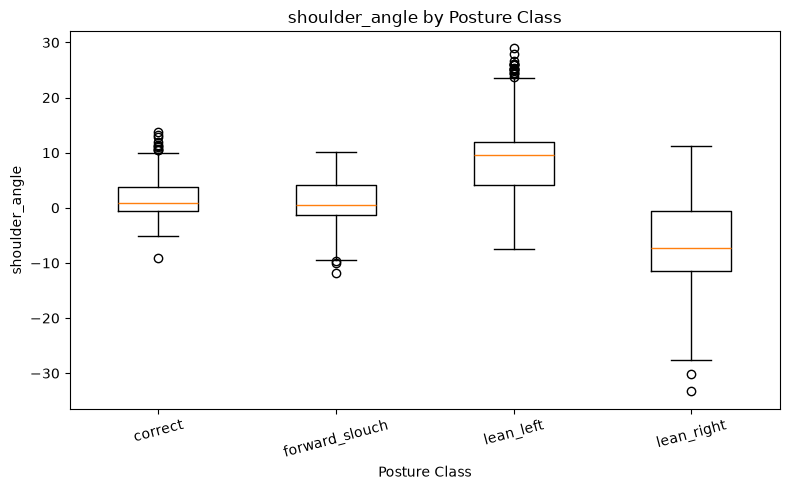

,count,mean,median,std,min,max
label,,,,,,
correct,743,-8.011656,-8.052505,5.984296,-25.524620,14.956120
forward_slouch,658,-6.641931,-5.707738,7.277430,-34.885452,14.407880
lean_left,782,-10.050661,-11.704154,8.564570,-27.394806,10.600397
lean_right,762,-1.694070,-0.469598,9.603807,-31.425152,20.052111


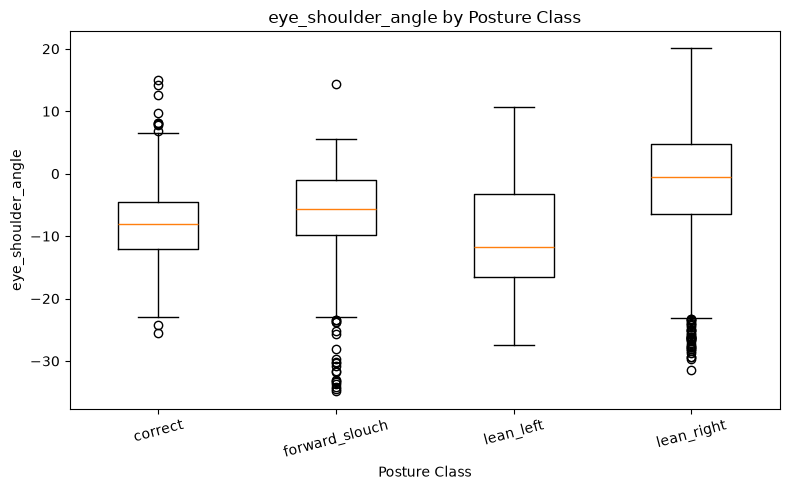

,count,mean,median,std,min,max
label,,,,,,
correct,743,-0.027530,-0.027526,0.022493,-0.095002,0.075849
forward_slouch,658,-0.023707,-0.020709,0.025146,-0.102665,0.072613
lean_left,782,-0.032605,-0.039781,0.026889,-0.092838,0.034577
lean_right,762,-0.004420,-0.001805,0.034833,-0.109433,0.088747


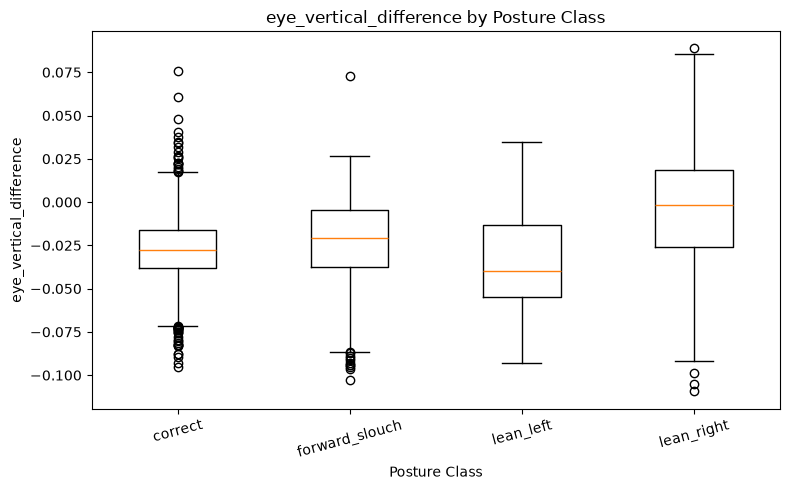

,count,mean,median,std,min,max
label,,,,,,
correct,743,0.381526,0.405934,0.149890,-0.216918,0.718579
forward_slouch,658,0.629418,0.649745,0.180928,-0.450447,0.929006
lean_left,782,0.362700,0.397582,0.236835,-0.216467,0.818799
lean_right,762,0.354710,0.311991,0.290129,-0.240973,0.935253


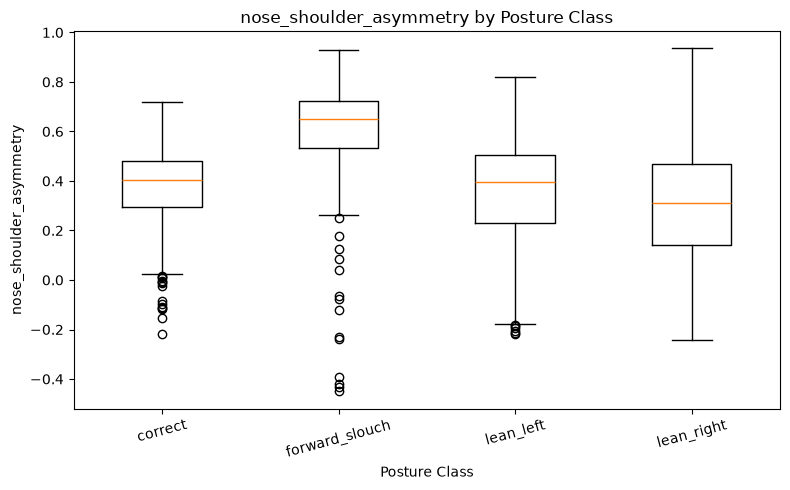

,count,mean,median,std,min,max
label,,,,,,
correct,743,0.310678,0.328797,0.129455,-0.161728,0.624215
forward_slouch,658,0.533666,0.544675,0.161914,-0.380558,0.888445
lean_left,782,0.306266,0.326928,0.195386,-0.164584,0.715993
lean_right,762,0.284410,0.232553,0.261086,-0.211408,0.874931


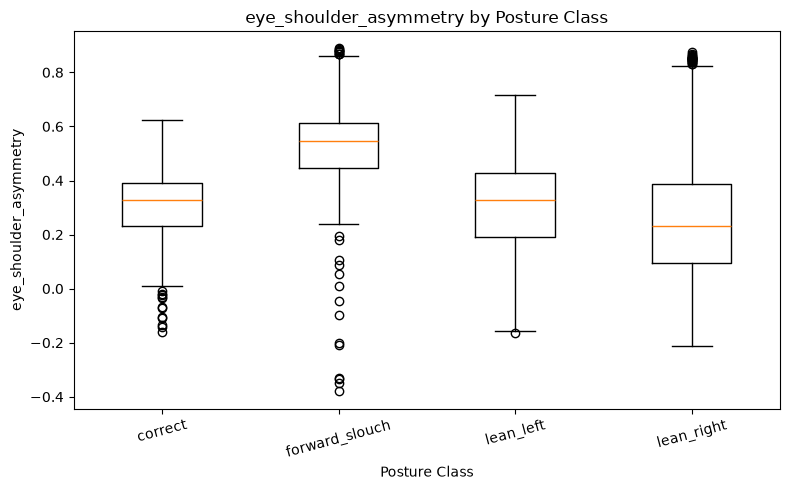

,count,mean,median,std,min,max
label,,,,,,
correct,743,-0.284990,-0.285240,0.135106,-0.713554,0.136916
forward_slouch,658,-0.431938,-0.440469,0.147788,-0.918981,0.358919
lean_left,782,-0.147762,-0.165181,0.190891,-0.543433,0.382535
lean_right,762,-0.350576,-0.327950,0.196970,-1.620192,0.117746


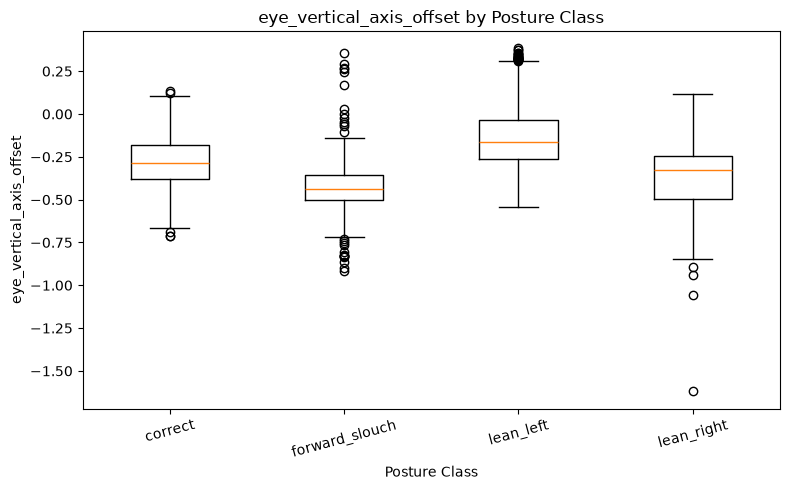

,count,mean,median,std,min,max
label,,,,,,
correct,743,-0.328764,-0.331745,0.149886,-0.779382,0.165503
forward_slouch,658,-0.468810,-0.462956,0.163433,-0.971780,0.392283
lean_left,782,-0.180549,-0.181966,0.200582,-0.540337,0.361691
lean_right,762,-0.367654,-0.346400,0.203714,-1.616590,0.125905


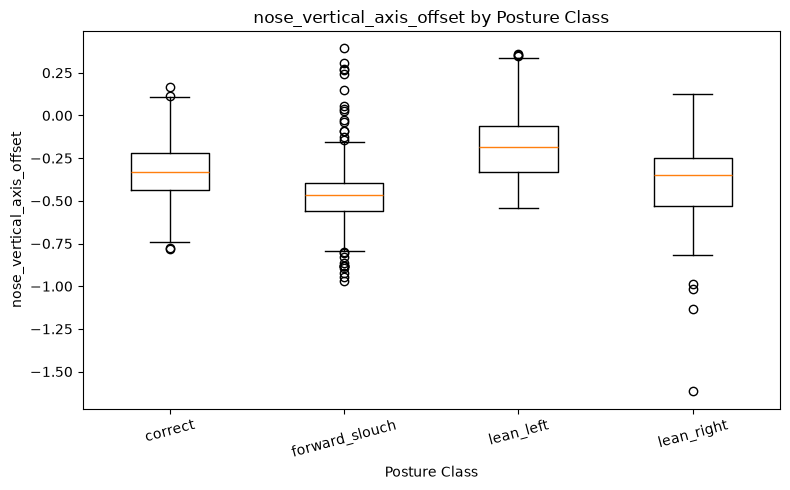

In [68]:
# left vs right
direction_features = [
    "shoulder_angle",
    "eye_shoulder_angle",
    "eye_vertical_difference",
    "nose_shoulder_asymmetry",
    "eye_shoulder_asymmetry",
    "eye_vertical_axis_offset",
    "nose_vertical_axis_offset",
]

for feature in direction_features:
    show_feature_by_class(feature)
    plot_feature_boxplot(feature)

,count,mean,median,std,min,max
label,,,,,,
correct,743,21.000670,21.760920,8.567966,-10.833282,41.661850
forward_slouch,658,41.833459,39.327301,15.777963,-27.225435,81.456009
lean_left,782,22.626577,23.892119,14.490482,-10.681449,54.771412
lean_right,762,20.196076,15.998582,19.090752,-14.779600,64.975487


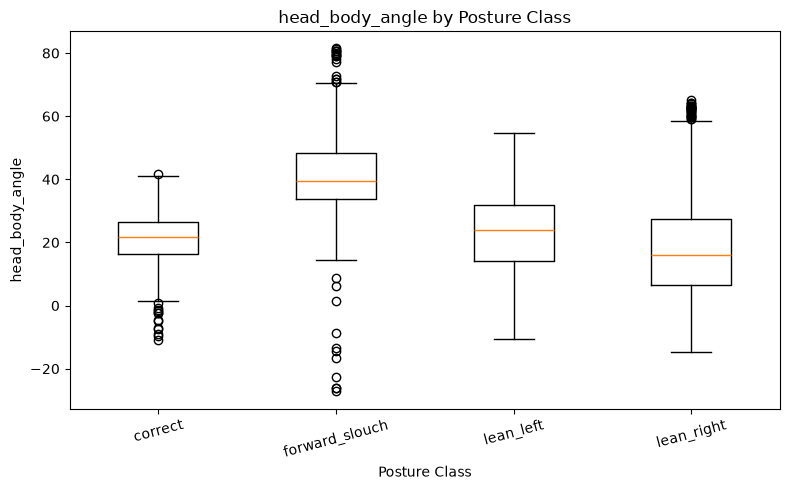

,count,mean,median,std,min,max
label,,,,,,
correct,743,-19.109641,-20.415022,7.460216,-39.842819,9.577368
forward_slouch,658,-40.754351,-37.036320,15.893190,-77.567177,27.879070
lean_left,782,-13.782308,-17.165430,17.224321,-54.145405,33.435421
lean_right,762,-27.303671,-25.506808,15.274223,-68.478470,9.928034


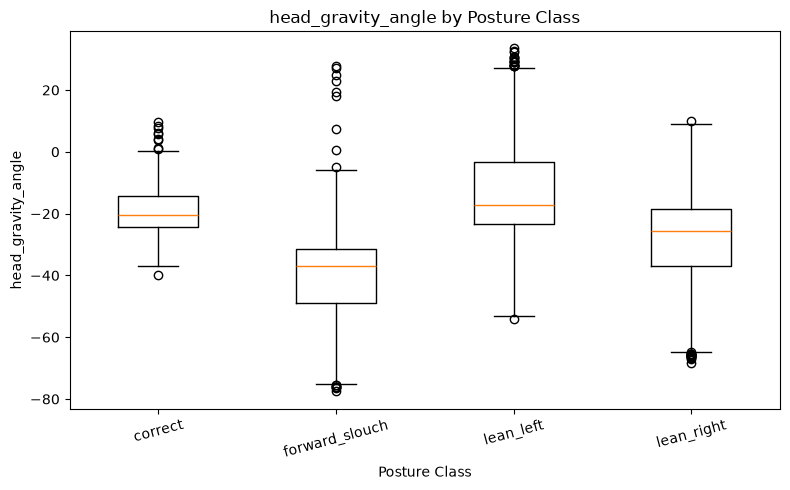

,count,mean,median,std,min,max
label,,,,,,
correct,743,-24.929543,-26.394571,9.128864,-53.886051,12.284021
forward_slouch,658,-53.421597,-47.716079,23.433866,-151.187698,51.817249
lean_left,782,-19.937524,-23.274056,21.475165,-65.121208,37.713203
lean_right,762,-33.661721,-32.416639,18.515015,-77.629402,11.680468


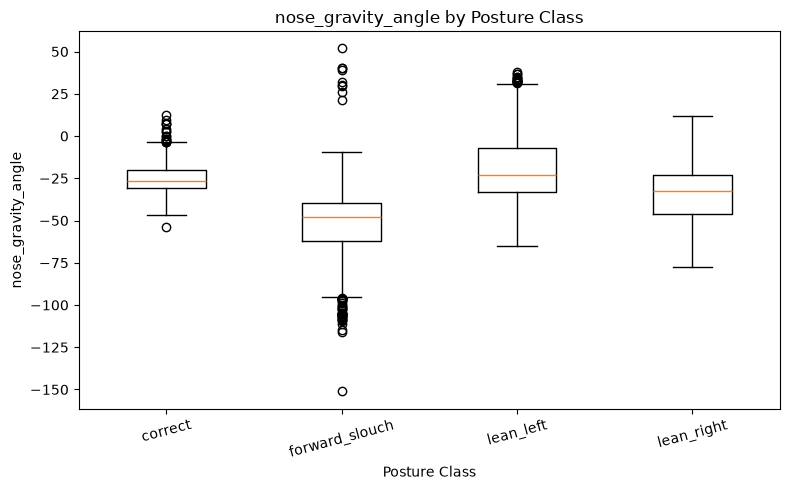

,count,mean,median,std,min,max
label,,,,,,
correct,743,19.520819,19.151617,10.053784,-32.622177,51.907558
forward_slouch,658,13.164019,13.775215,11.112494,-29.739948,43.340115
lean_left,782,7.328048,6.080576,13.929143,-22.444010,41.507740
lean_right,762,14.216832,11.861357,13.398758,-27.630690,52.575855


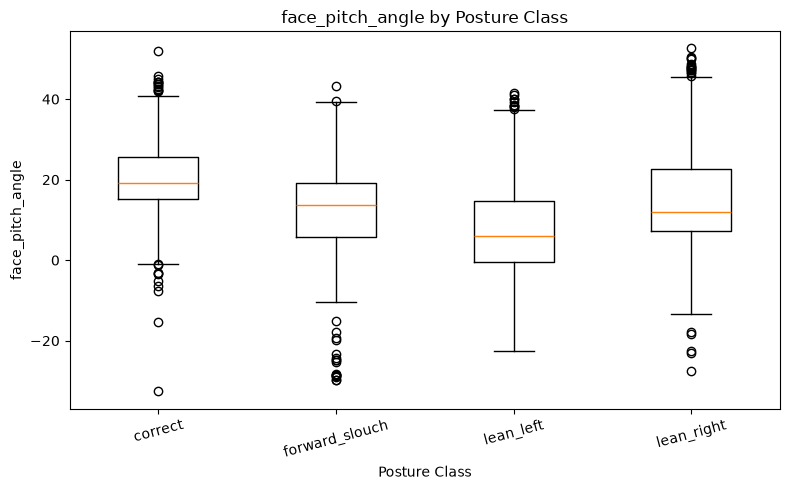

,count,mean,median,std,min,max
label,,,,,,
correct,743,26.820571,27.971193,10.207799,-14.837770,52.548218
forward_slouch,658,54.500704,49.520365,22.999256,-59.900890,147.840836
lean_left,782,28.781793,32.838443,18.647776,-14.419217,67.825981
lean_right,762,26.554126,21.569848,22.483570,-17.638943,73.099937


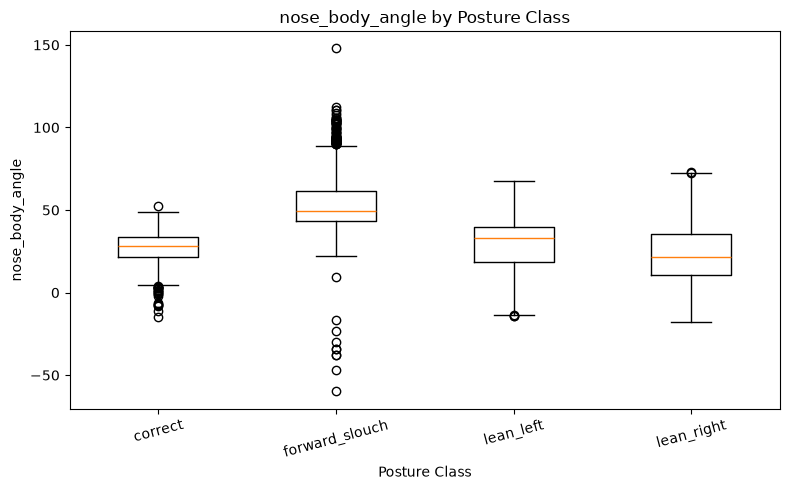

,count,mean,median,std,min,max
label,,,,,,
correct,743,-9.452470,-8.727755,6.769316,-36.192432,9.867085
forward_slouch,658,-6.178473,-4.724202,12.900650,-48.184872,22.345074
lean_left,782,-13.108616,-12.293523,9.110624,-42.134926,9.030875
lean_right,762,-13.313196,-15.979259,13.299718,-34.076962,25.566822


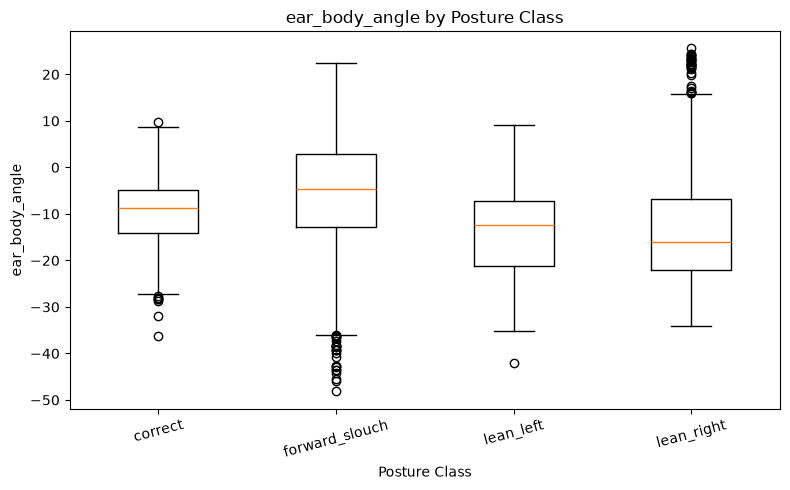

,count,mean,median,std,min,max
label,,,,,,
correct,743,0.724291,0.727554,0.115340,0.466137,1.143368
forward_slouch,658,0.513137,0.573171,0.206503,0.087826,0.905070
lean_left,782,0.546541,0.537448,0.077809,0.368262,0.890714
lean_right,762,0.639471,0.603399,0.164612,0.384370,1.704349


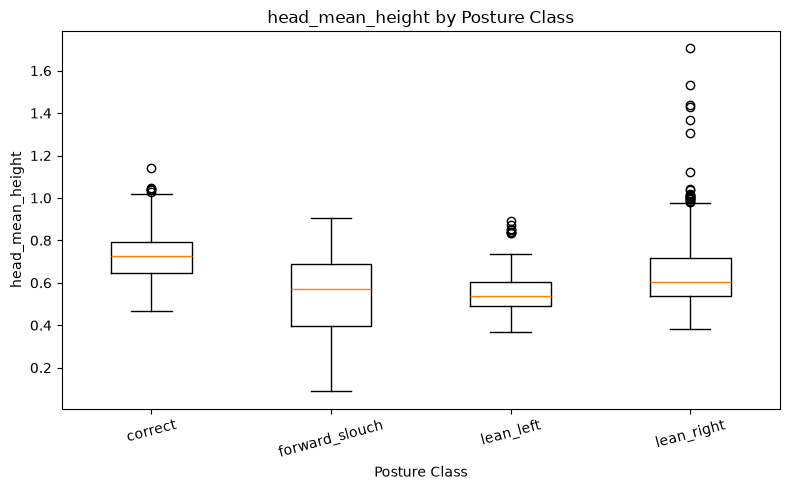

,count,mean,median,std,min,max
label,,,,,,
correct,743,0.057247,0.053798,0.013267,0.035575,0.137263
forward_slouch,658,0.092982,0.083573,0.035466,0.043345,0.209028
lean_left,782,0.072519,0.061324,0.031607,0.036269,0.147899
lean_right,762,0.078204,0.064251,0.034175,0.034220,0.194754


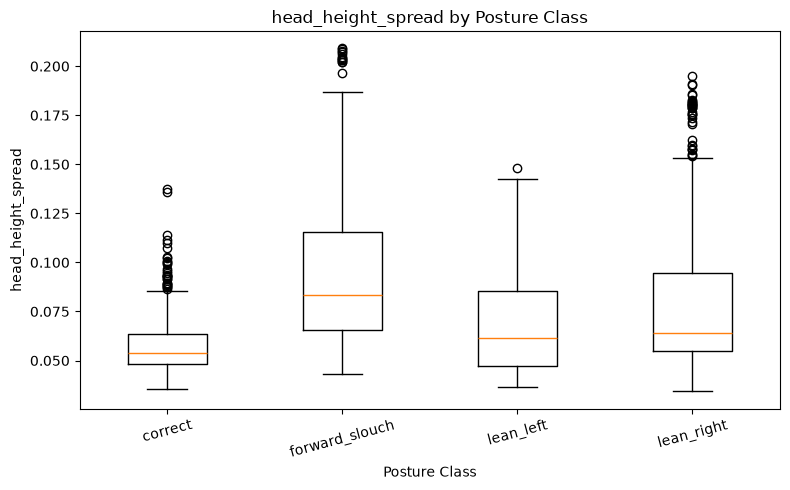

In [69]:
# Nhóm feature liên quan forward_slouch
slouch_features = [
    "head_body_angle",
    "head_gravity_angle",
    "nose_gravity_angle",
    "face_pitch_angle",
    "nose_body_angle",
    "ear_body_angle",
    "head_mean_height",
    "head_height_spread",
]

for feature in slouch_features:
    show_feature_by_class(feature)
    plot_feature_boxplot(feature)

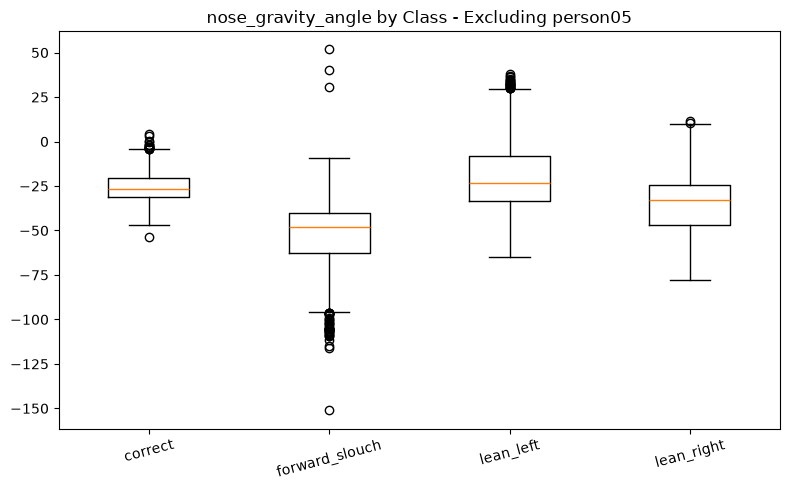

In [70]:
# Kiểm tra ảnh hưởng person05 lên distribution
feature = "nose_gravity_angle"

plt.figure(figsize=(8, 5))

data_without_person05 = [
    df.loc[
        (df["label"] == label)
        & (df["person_id"] != "person05"),
        feature
    ].values
    for label in EXPECTED_CLASSES
]

plt.boxplot(
    data_without_person05,
    tick_labels=EXPECTED_CLASSES
)

plt.title(
    f"{feature} by Class - Excluding person05"
)

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [71]:
# Bảng tổng kết
distribution_summary = pd.DataFrame({
    "overall_mean": df[feature_columns].mean(),
    "overall_std": df[feature_columns].std(),

    "class_median_min":
        class_feature_median.min(axis=0),

    "class_median_max":
        class_feature_median.max(axis=0),

    "class_median_spread":
        median_spread,

    "normalized_median_spread":
        normalized_median_spread
})

distribution_summary = (
    distribution_summary
    .sort_values(
        "normalized_median_spread",
        ascending=False
    )
)

display(distribution_summary)

,overall_mean,overall_std,class_median_min,class_median_max,class_median_spread,normalized_median_spread
shoulder_angle,1.227612,8.264919,-7.279265,9.588366,16.867631,2.040871
eye_shoulder_asymmetry,0.352532,0.217640,0.232553,0.544675,0.312122,1.434122
eye_vertical_axis_offset,-0.298354,0.199834,-0.440469,-0.165181,0.275288,1.377587
nose_shoulder_asymmetry,0.424975,0.248461,0.311991,0.649745,0.337754,1.359385
head_body_angle,25.878882,17.263757,15.998582,39.327301,23.328719,1.351312
nose_vertical_axis_offset,-0.330761,0.208878,-0.462956,-0.181966,0.280991,1.345242
eye_shoulder_angle,-6.612411,8.604724,-11.704154,-0.469598,11.234556,1.305627
eye_vertical_difference,-0.022044,0.029871,-0.039781,-0.001805,0.037976,1.271333
nose_body_angle,33.456962,22.258950,21.569848,49.520365,27.950517,1.255698
eye_center_x_body,0.308165,0.191207,0.212143,0.449315,0.237172,1.240396


### Kết luận bước 6 - Feature Distribution by Posture Class

- Phân phối của 29 engineered features cho thấy nhiều feature có sự khác biệt
  đáng kể về median giữa 4 posture classes.

- `shoulder_angle` có normalized median spread cao nhất (~2.04), cho thấy đây
  là một feature có khả năng tạo ra sự khác biệt rõ giữa các posture classes,
  đặc biệt có tiềm năng hữu ích cho các tư thế nghiêng trái/phải.

- Các feature thuộc nhóm asymmetry và body-axis cũng cho thấy mức độ phân tách
  tương đối rõ:
  - `eye_shoulder_asymmetry`
  - `nose_shoulder_asymmetry`
  - `eye_vertical_axis_offset`
  - `nose_vertical_axis_offset`

- Các feature liên quan tới hướng và tư thế đầu cũng có mức phân tách đáng chú ý:
  - `head_body_angle`
  - `nose_body_angle`
  - `head_gravity_angle`
  - `nose_gravity_angle`
  - `face_pitch_angle`

- `eye_shoulder_angle` và `eye_vertical_difference` cũng cho thấy sự thay đổi
  giữa các posture classes và có khả năng hỗ trợ nhận diện tư thế nghiêng.

- Một số feature như `head_axis_angle_spread`, `eye_width_ratio`,
  `left_ear_y_body` có normalized median spread thấp hơn, cho thấy khả năng
  phân tách đơn biến giữa 4 classes yếu hơn.

- Tuy nhiên, normalized median spread chỉ là một chỉ số mô tả phân phối,
  không phải Feature Importance. Feature có separation thấp khi xét riêng
  vẫn có thể hữu ích khi kết hợp với các feature khác trong SVM hoặc XGBoost.

- Nhóm shoulder/asymmetry có dấu hiệu phù hợp với việc phân biệt
  `lean_left` và `lean_right`, trong khi nhóm head/body angle có tiềm năng
  hỗ trợ phân biệt `correct` và `forward_slouch`.

- `person05` vẫn được giữ trong EDA để đảm bảo traceability. Do dữ liệu của
  subject này được thu sai camera protocol, ảnh hưởng của person05 cần được
  lưu ý khi phân tích extreme values và outlier ở bước tiếp theo.

Chưa có feature nào được loại bỏ tại bước này.

## 7. Outlier Analysis

Mục tiêu:
- Phát hiện các giá trị feature cực đoan.
- Xác định feature, posture class và person liên quan tới outlier.
- Phân biệt outlier hợp lệ do posture với outlier do pose detection hoặc
  data collection error.
- Truy ngược các trường hợp đáng nghi về ảnh gốc thông qua `image_path`.

Không tự động xóa outlier tại bước này.

In [72]:
# Phát hiện outlier bằng IQR
outlier_summary = []

for feature in feature_columns:
    q1 = df[feature].quantile(0.25)
    q3 = df[feature].quantile(0.75)

    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    mask = (
        (df[feature] < lower_bound)
        |
        (df[feature] > upper_bound)
    )

    count = mask.sum()
    percentage = count / len(df) * 100

    outlier_summary.append({
        "feature": feature,
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "outlier_count": count,
        "outlier_percentage": percentage,
    })

outlier_summary = pd.DataFrame(outlier_summary)

outlier_summary = outlier_summary.sort_values(
    "outlier_percentage",
    ascending=False
)

display(outlier_summary)

,feature,q1,q3,iqr,lower_bound,upper_bound,outlier_count,outlier_percentage
28,head_axis_angle_spread,15.479052,20.774292,5.295240,7.536192,28.717152,247,8.387097
19,head_gravity_angle,-33.625122,-15.402194,18.222928,-60.959514,11.932198,208,7.062818
20,nose_gravity_angle,-42.784775,-20.721476,22.063299,-75.879724,12.373473,207,7.028862
0,shoulder_angle,-1.771224,6.325143,8.096367,-13.915774,18.469693,191,6.485569
6,eye_center_y_body,0.553127,0.760790,0.207663,0.241633,1.072284,174,5.908319
24,head_mean_height,0.518078,0.705385,0.187307,0.237118,0.986346,161,5.466893
25,head_height_spread,0.050937,0.086257,0.035320,-0.002043,0.139237,145,4.923599
8,left_ear_y_body,0.571313,0.710341,0.139028,0.362771,0.918883,128,4.346350
26,nose_body_angle,20.132790,45.059513,24.926723,-17.257295,82.449598,125,4.244482
4,nose_y_body,0.412779,0.656242,0.243463,0.047585,1.021437,113,3.837012


In [73]:
# Xem 10 feature có nhiều outlier nhất
top_outlier_features = (
    outlier_summary
    .head(10)
)

display(top_outlier_features)

,feature,q1,q3,iqr,lower_bound,upper_bound,outlier_count,outlier_percentage
28,head_axis_angle_spread,15.479052,20.774292,5.295240,7.536192,28.717152,247,8.387097
19,head_gravity_angle,-33.625122,-15.402194,18.222928,-60.959514,11.932198,208,7.062818
20,nose_gravity_angle,-42.784775,-20.721476,22.063299,-75.879724,12.373473,207,7.028862
0,shoulder_angle,-1.771224,6.325143,8.096367,-13.915774,18.469693,191,6.485569
6,eye_center_y_body,0.553127,0.760790,0.207663,0.241633,1.072284,174,5.908319
24,head_mean_height,0.518078,0.705385,0.187307,0.237118,0.986346,161,5.466893
25,head_height_spread,0.050937,0.086257,0.035320,-0.002043,0.139237,145,4.923599
8,left_ear_y_body,0.571313,0.710341,0.139028,0.362771,0.918883,128,4.346350
26,nose_body_angle,20.132790,45.059513,24.926723,-17.257295,82.449598,125,4.244482
4,nose_y_body,0.412779,0.656242,0.243463,0.047585,1.021437,113,3.837012


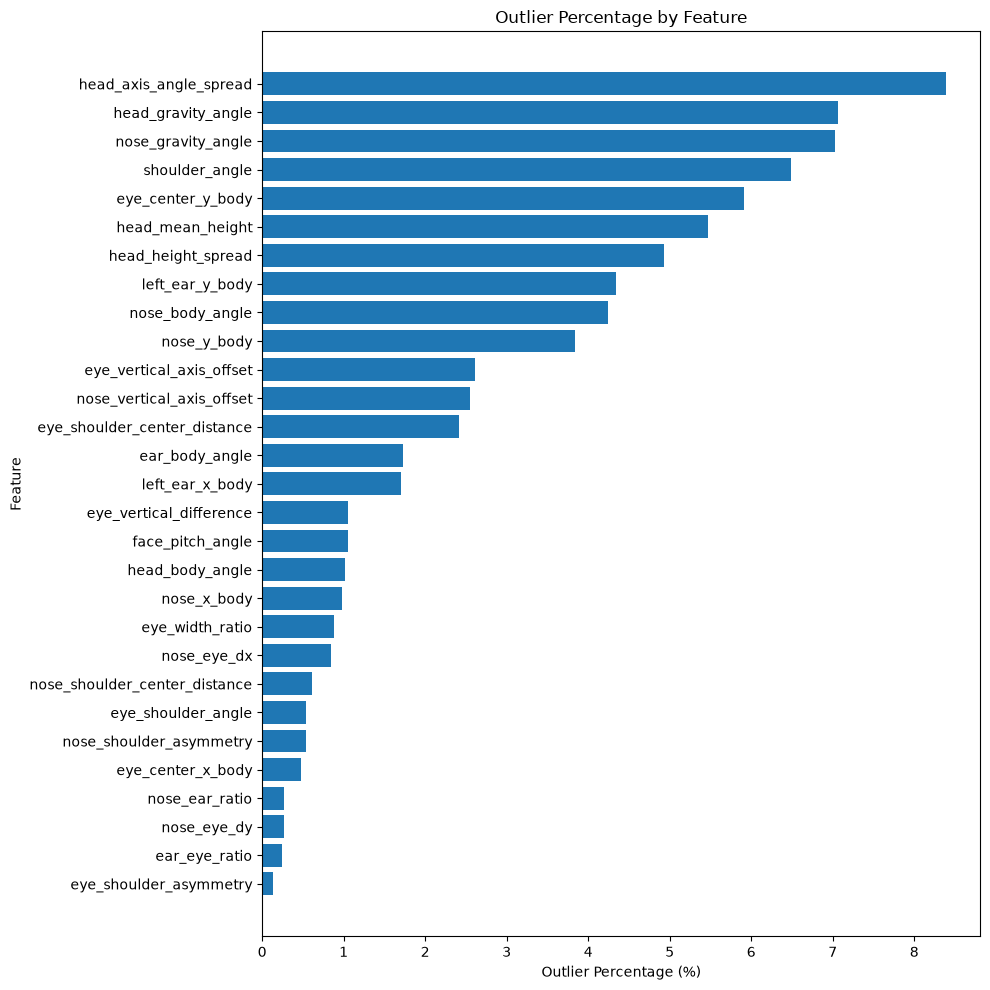

In [74]:
# Vẽ tỷ lệ outlier của 29 features
plot_data = (
    outlier_summary
    .sort_values("outlier_percentage")
)

plt.figure(figsize=(10, 10))

plt.barh(
    plot_data["feature"],
    plot_data["outlier_percentage"]
)

plt.xlabel("Outlier Percentage (%)")
plt.ylabel("Feature")
plt.title("Outlier Percentage by Feature")

plt.tight_layout()
plt.show()

In [75]:
# Outlier theo từng class
class_outlier_rows = []

for label in EXPECTED_CLASSES:

    class_df = df[
        df["label"] == label
    ]

    for feature in feature_columns:

        q1 = class_df[feature].quantile(0.25)
        q3 = class_df[feature].quantile(0.75)

        iqr = q3 - q1

        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        mask = (
            (class_df[feature] < lower)
            |
            (class_df[feature] > upper)
        )

        class_outlier_rows.append({
            "label": label,
            "feature": feature,
            "outlier_count": mask.sum(),
            "outlier_percentage": (
                mask.mean() * 100
            ),
        })

class_outlier_summary = pd.DataFrame(
    class_outlier_rows
)

display(
    class_outlier_summary
    .sort_values(
        "outlier_percentage",
        ascending=False
    )
)

,label,feature,outlier_count,outlier_percentage
55,forward_slouch,nose_body_angle,78,11.854103
86,lean_left,head_axis_angle_spread,74,9.462916
57,forward_slouch,head_axis_angle_spread,62,9.422492
67,lean_left,nose_eye_dx,58,7.416880
49,forward_slouch,nose_gravity_angle,48,7.294833
...,...,...,...,...
60,lean_left,eye_vertical_difference,0,0.000000
59,lean_left,eye_shoulder_angle,0,0.000000
90,lean_right,nose_x_body,0,0.000000
107,lean_right,nose_gravity_angle,0,0.000000


In [76]:
# Tạo ma trận Class × Feature
class_outlier_matrix = (
    class_outlier_summary
    .pivot(
        index="feature",
        columns="label",
        values="outlier_percentage"
    )
    .reindex(
        columns=EXPECTED_CLASSES
    )
)

display(
    class_outlier_matrix
    .round(2)
)

label,correct,forward_slouch,lean_left,lean_right
feature,,,,
ear_body_angle,1.21,3.80,0.13,4.20
ear_eye_ratio,4.17,2.58,0.00,0.66
eye_center_x_body,1.21,1.67,0.77,0.39
eye_center_y_body,1.62,0.00,1.02,2.36
eye_shoulder_angle,1.48,3.19,0.00,4.59
eye_shoulder_asymmetry,1.62,3.65,0.13,2.89
eye_shoulder_center_distance,0.13,0.00,1.02,1.18
eye_vertical_axis_offset,0.67,3.95,2.94,0.52
eye_vertical_difference,6.59,1.82,0.00,0.52


In [77]:
# Kiểm tra outlier theo person
outlier_masks = pd.DataFrame(
    False,
    index=df.index,
    columns=feature_columns
)

for feature in feature_columns:

    q1 = df[feature].quantile(0.25)
    q3 = df[feature].quantile(0.75)

    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outlier_masks[feature] = (
        (df[feature] < lower)
        |
        (df[feature] > upper)
    )

In [78]:
df_outlier_analysis = df[
    [
        "image_path",
        "session_id",
        "person_id",
        "label"
    ]
].copy()

df_outlier_analysis["outlier_feature_count"] = (
    outlier_masks.sum(axis=1)
)

display(
    df_outlier_analysis.head()
)

,image_path,session_id,person_id,label,outlier_feature_count
0,G:/PTIT TL/K1N3/PYTHON/BTL/smart_posture_monit...,session01,person01,correct,0
1,G:/PTIT TL/K1N3/PYTHON/BTL/smart_posture_monit...,session01,person01,correct,0
2,G:/PTIT TL/K1N3/PYTHON/BTL/smart_posture_monit...,session01,person01,correct,0
3,G:/PTIT TL/K1N3/PYTHON/BTL/smart_posture_monit...,session01,person01,correct,0
4,G:/PTIT TL/K1N3/PYTHON/BTL/smart_posture_monit...,session01,person01,correct,0


In [79]:
# Outlier theo person
person_outlier_summary = (
    df_outlier_analysis
    .groupby("person_id")
    ["outlier_feature_count"]
    .agg(
        [
            "count",
            "mean",
            "median",
            "max"
        ]
    )
)

display(person_outlier_summary)

,count,mean,median,max
person_id,,,,
person01,796,0.048995,0.0,2
person02,273,0.161172,0.0,3
person03,307,0.671010,0.0,6
person04,258,1.604651,1.0,8
person05,48,2.854167,0.0,13
person06,252,0.099206,0.0,4
person07,255,0.035294,0.0,1
person08,246,1.296748,0.0,6
person09,284,2.295775,0.0,13


In [80]:
# Kiểm tra trực tiếp person05
person05_outliers = (
    df_outlier_analysis[
        df_outlier_analysis["person_id"]
        == "person05"
    ]
    .sort_values(
        "outlier_feature_count",
        ascending=False
    )
)

display(person05_outliers.head(20))

,image_path,session_id,person_id,label,outlier_feature_count
1117,G:/PTIT TL/K1N3/PYTHON/BTL/smart_posture_monit...,session01,person05,forward_slouch,13
1119,G:/PTIT TL/K1N3/PYTHON/BTL/smart_posture_monit...,session01,person05,forward_slouch,12
1120,G:/PTIT TL/K1N3/PYTHON/BTL/smart_posture_monit...,session01,person05,forward_slouch,12
1122,G:/PTIT TL/K1N3/PYTHON/BTL/smart_posture_monit...,session01,person05,forward_slouch,12
1121,G:/PTIT TL/K1N3/PYTHON/BTL/smart_posture_monit...,session01,person05,forward_slouch,9
1841,G:/PTIT TL/K1N3/PYTHON/BTL/smart_posture_monit...,session01,person05,lean_left,8
1839,G:/PTIT TL/K1N3/PYTHON/BTL/smart_posture_monit...,session01,person05,lean_left,7
1843,G:/PTIT TL/K1N3/PYTHON/BTL/smart_posture_monit...,session01,person05,lean_left,7
1842,G:/PTIT TL/K1N3/PYTHON/BTL/smart_posture_monit...,session01,person05,lean_left,7
1840,G:/PTIT TL/K1N3/PYTHON/BTL/smart_posture_monit...,session01,person05,lean_left,6


In [81]:
# Tìm những frame đáng nghi nhất toàn dataset
most_extreme_frames = (
    df_outlier_analysis
    .sort_values(
        "outlier_feature_count",
        ascending=False
    )
    .head(30)
)

display(most_extreme_frames)

,image_path,session_id,person_id,label,outlier_feature_count
2876,G:/PTIT TL/K1N3/PYTHON/BTL/smart_posture_monit...,session01,person10,lean_right,17
2875,G:/PTIT TL/K1N3/PYTHON/BTL/smart_posture_monit...,session01,person10,lean_right,17
2878,G:/PTIT TL/K1N3/PYTHON/BTL/smart_posture_monit...,session01,person10,lean_right,15
2877,G:/PTIT TL/K1N3/PYTHON/BTL/smart_posture_monit...,session01,person10,lean_right,15
2881,G:/PTIT TL/K1N3/PYTHON/BTL/smart_posture_monit...,session01,person10,lean_right,14
1117,G:/PTIT TL/K1N3/PYTHON/BTL/smart_posture_monit...,session01,person05,forward_slouch,13
1320,G:/PTIT TL/K1N3/PYTHON/BTL/smart_posture_monit...,session01,person09,forward_slouch,13
1399,G:/PTIT TL/K1N3/PYTHON/BTL/smart_posture_monit...,session01,person10,forward_slouch,13
1393,G:/PTIT TL/K1N3/PYTHON/BTL/smart_posture_monit...,session01,person10,forward_slouch,13
1400,G:/PTIT TL/K1N3/PYTHON/BTL/smart_posture_monit...,session01,person10,forward_slouch,13


In [82]:
# Xem cụ thể feature nào bị outlier trong một frame
def inspect_outlier_row(index):

    row_info = df.loc[
        index,
        [
            "image_path",
            "session_id",
            "person_id",
            "label"
        ]
    ]

    print("Sample information:")
    display(row_info)

    outlier_features = (
        outlier_masks
        .loc[index]
    )

    outlier_features = (
        outlier_features[
            outlier_features
        ]
        .index
        .tolist()
    )

    print(
        "Outlier features:",
        outlier_features
    )

    if outlier_features:
        display(
            df.loc[
                [index],
                outlier_features
            ]
        )

In [83]:
inspect_outlier_row(
    most_extreme_frames.index[0]
)

Sample information:


image_path    G:/PTIT TL/K1N3/PYTHON/BTL/smart_posture_monit...
session_id                                            session01
person_id                                              person10
label                                                lean_right
Name: 2876, dtype: str

Outlier features: ['shoulder_angle', 'eye_vertical_difference', 'nose_y_body', 'eye_center_y_body', 'left_ear_x_body', 'left_ear_y_body', 'nose_eye_dx', 'eye_width_ratio', 'ear_eye_ratio', 'nose_shoulder_center_distance', 'eye_shoulder_center_distance', 'nose_ear_ratio', 'face_pitch_angle', 'eye_vertical_axis_offset', 'nose_vertical_axis_offset', 'head_mean_height', 'head_height_spread']


,shoulder_angle,eye_vertical_difference,nose_y_body,eye_center_y_body,left_ear_x_body,left_ear_y_body,nose_eye_dx,eye_width_ratio,ear_eye_ratio,nose_shoulder_center_distance,eye_shoulder_center_distance,nose_ear_ratio,face_pitch_angle,eye_vertical_axis_offset,nose_vertical_axis_offset,head_mean_height,head_height_spread
2876,-27.031029,0.060749,1.585892,1.733807,-0.527961,1.275889,0.166152,0.3669,0.774868,1.652756,1.759433,1.040561,48.323223,-1.054482,-1.13526,1.531863,0.190808


In [84]:
# Kiểm tra riêng các angle extremes
angle_features = [
    "shoulder_angle",
    "eye_shoulder_angle",
    "head_body_angle",
    "head_gravity_angle",
    "nose_gravity_angle",
    "face_pitch_angle",
    "nose_body_angle",
    "ear_body_angle",
    "head_axis_angle_spread",
]

for feature in angle_features:

    min_idx = df[feature].idxmin()
    max_idx = df[feature].idxmax()

    print("\n", "=" * 70)
    print(feature)

    print("\nMIN:")
    display(
        df.loc[
            [min_idx],
            [
                "image_path",
                "person_id",
                "label",
                feature
            ]
        ]
    )

    print("MAX:")
    display(
        df.loc[
            [max_idx],
            [
                "image_path",
                "person_id",
                "label",
                feature
            ]
        ]
    )


shoulder_angle

MIN:


,image_path,person_id,label,shoulder_angle
2878,G:/PTIT TL/K1N3/PYTHON/BTL/smart_posture_monit...,person10,lean_right,-33.322411


MAX:


,image_path,person_id,label,shoulder_angle
2028,G:/PTIT TL/K1N3/PYTHON/BTL/smart_posture_monit...,person08,lean_left,28.911543



eye_shoulder_angle

MIN:


...

,image_path,person_id,label,ear_body_angle
2492,G:/PTIT TL/K1N3/PYTHON/BTL/smart_posture_monit...,person03,lean_right,25.566822



head_axis_angle_spread

MIN:


,image_path,person_id,label,head_axis_angle_spread
2599,G:/PTIT TL/K1N3/PYTHON/BTL/smart_posture_monit...,person05,lean_right,6.475705


MAX:


,image_path,person_id,label,head_axis_angle_spread
1315,G:/PTIT TL/K1N3/PYTHON/BTL/smart_posture_monit...,person09,forward_slouch,78.51474


### Kết luận bước 7 - Outlier Analysis

- Dataset có xuất hiện outlier theo quy tắc IQR, tuy nhiên tỷ lệ outlier
  khác nhau đáng kể giữa các engineered features.

- Các feature có tỷ lệ outlier cao nhất chủ yếu thuộc nhóm mô tả orientation
  và geometry của đầu/vai, bao gồm:
  - `head_axis_angle_spread` (~8.39%)
  - `head_gravity_angle` (~7.06%)
  - `nose_gravity_angle` (~7.03%)
  - `shoulder_angle` (~6.49%)
  - `eye_center_y_body` (~5.91%)
  - `head_mean_height` (~5.47%)

- Những extreme values này chưa được xem là lỗi dữ liệu vì nhiều feature
  liên quan trực tiếp tới posture. Các tư thế cúi hoặc nghiêng mạnh có thể
  tạo ra giá trị nằm ngoài global IQR nhưng vẫn là sample hợp lệ và có ích
  cho classifier.

- `person05` có số feature outlier trung bình cao nhất (~2.85 feature/frame).
  Kết quả này phù hợp với lỗi acquisition đã biết: dữ liệu của person05
  được quay từ phía bên phải thay vì camera protocol phía bên trái.

- Tuy nhiên, outlier không chỉ xuất hiện ở person05. `person09` và
  `person10` cũng có mức outlier tương đối cao; một frame của person10
  đạt tối đa 17/29 features bị đánh dấu outlier.

- Median outlier count của person05 và person09 bằng 0 trong khi mean tương
  đối cao, cho thấy phần lớn frame vẫn bình thường nhưng có một số frame
  extreme kéo giá trị trung bình lên.

- Không thực hiện xóa dữ liệu tự động bằng global IQR vì việc này có thể
  loại bỏ những sample posture hợp lệ và làm mất thông tin quan trọng.

- Các frame có đồng thời nhiều feature bị đánh dấu outlier nên được xem như
  các candidate để manual inspection thông qua `image_path`.

- Chỉ loại sample nếu có bằng chứng rõ ràng về pose detection error,
  acquisition error hoặc feature extraction error.

## 8. Correlation Analysis of 29 Features

Mục tiêu:
- Đo mức độ tương quan giữa 29 engineered features.
- Phát hiện các cặp feature có tương quan rất cao.
- Xác định khả năng tồn tại redundant features.
- So sánh Pearson correlation và Spearman correlation khi cần thiết.
- Chuẩn bị cho feature selection và preprocessing.

Lưu ý:
Correlation cao không đồng nghĩa feature phải bị loại.

In [85]:
# Tính Pearson Correlation Matrix
corr_matrix = df[feature_columns].corr(method="pearson")

display(corr_matrix)

,shoulder_angle,eye_shoulder_angle,eye_vertical_difference,nose_x_body,nose_y_body,eye_center_x_body,eye_center_y_body,left_ear_x_body,left_ear_y_body,nose_eye_dx,...,head_gravity_angle,nose_gravity_angle,face_pitch_angle,eye_vertical_axis_offset,nose_vertical_axis_offset,head_mean_height,head_height_spread,nose_body_angle,ear_body_angle,head_axis_angle_spread
shoulder_angle,1.000000,-0.540728,-0.553334,0.124322,-0.218593,0.184451,-0.228610,0.331015,-0.059275,-0.369843,...,0.270762,0.219481,-0.351520,0.323248,0.275855,-0.190769,0.024406,0.148847,0.296108,0.004450
eye_shoulder_angle,-0.540728,1.000000,0.976300,-0.555694,0.110454,-0.615723,0.096859,-0.700432,-0.307225,0.223742,...,0.232746,0.200568,0.235099,0.320870,0.322147,0.005627,-0.261638,-0.404068,-0.717795,-0.045825
eye_vertical_difference,-0.553334,0.976300,1.000000,-0.556236,0.106565,-0.615672,0.085478,-0.671718,-0.314565,0.219502,...,0.218724,0.193857,0.238956,0.310482,0.314359,-0.002121,-0.247069,-0.401946,-0.685463,-0.063870
nose_x_body,0.124322,-0.555694,-0.556236,1.000000,-0.062256,0.990992,0.001194,0.860970,0.357640,0.398785,...,-0.711214,-0.670061,0.276505,-0.886129,-0.912014,0.063908,0.334139,0.725318,0.864320,0.324373
nose_y_body,-0.218593,0.110454,0.106565,-0.062256,1.000000,-0.151862,0.992756,-0.249839,0.797613,0.592614,...,0.485983,0.530911,0.619934,0.012541,-0.046455,0.983021,-0.629310,-0.619283,-0.046642,-0.735279
eye_center_x_body,0.184451,-0.615723,-0.615672,0.990992,-0.151862,1.000000,-0.089196,0.902932,0.307279,0.272384,...,-0.724920,-0.682423,0.150989,-0.862140,-0.877529,-0.019488,0.401400,0.760174,0.892626,0.352237
eye_center_y_body,-0.228610,0.096859,0.085478,0.001194,0.992756,-0.089196,1.000000,-0.217919,0.840235,0.619379,...,0.440423,0.486681,0.617670,-0.054132,-0.112869,0.993422,-0.592332,-0.578172,-0.011577,-0.708017
left_ear_x_body,0.331015,-0.700432,-0.671718,0.860970,-0.249839,0.902932,-0.217919,1.000000,0.158389,0.002887,...,-0.596891,-0.542686,-0.055470,-0.679174,-0.679952,-0.145370,0.341790,0.672961,0.958459,0.210395
left_ear_y_body,-0.059275,-0.307225,-0.314565,0.357640,0.797613,0.307279,0.840235,0.158389,1.000000,0.465430,...,0.142990,0.206849,0.393041,-0.353423,-0.392997,0.892812,-0.239679,-0.231666,0.360831,-0.517507
nose_eye_dx,-0.369843,0.223742,0.219502,0.398785,0.592614,0.272384,0.619379,0.002887,0.465430,1.000000,...,-0.145901,-0.141226,0.952719,-0.462988,-0.543594,0.592623,-0.347950,0.005818,0.097529,-0.081466


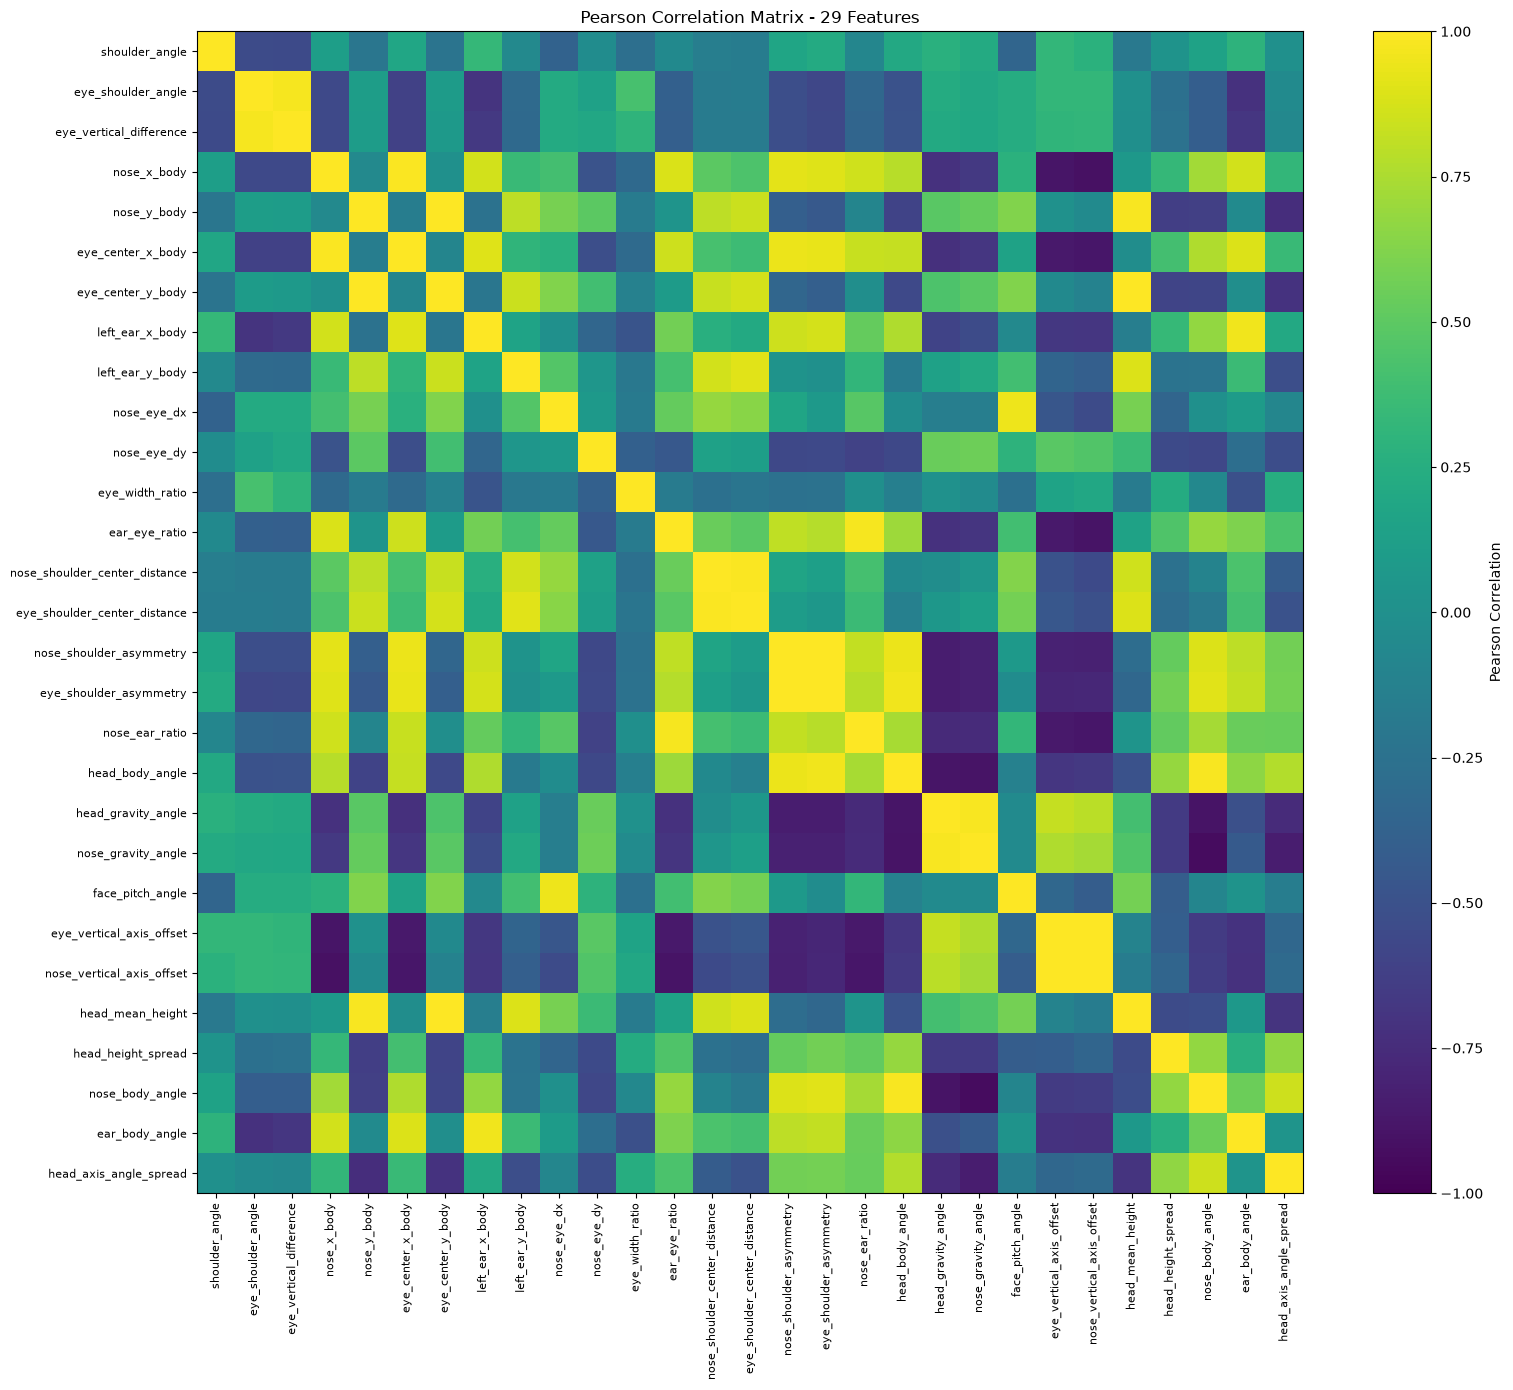

In [86]:
plt.figure(figsize=(16, 14))

plt.imshow(
    corr_matrix,
    aspect="auto",
    vmin=-1,
    vmax=1
)

plt.colorbar(
    label="Pearson Correlation"
)

plt.xticks(
    range(len(feature_columns)),
    feature_columns,
    rotation=90,
    fontsize=8
)

plt.yticks(
    range(len(feature_columns)),
    feature_columns,
    fontsize=8
)

plt.title(
    "Pearson Correlation Matrix - 29 Features"
)

plt.tight_layout()
plt.show()

In [87]:
# Tìm các cặp correlation cao
high_corr_pairs = []

for i in range(len(feature_columns)):
    for j in range(i + 1, len(feature_columns)):

        feature_a = feature_columns[i]
        feature_b = feature_columns[j]

        corr_value = corr_matrix.loc[
            feature_a,
            feature_b
        ]

        high_corr_pairs.append({
            "feature_a": feature_a,
            "feature_b": feature_b,
            "correlation": corr_value,
            "abs_correlation": abs(corr_value)
        })

high_corr_pairs = pd.DataFrame(
    high_corr_pairs
)

high_corr_pairs = (
    high_corr_pairs
    .sort_values(
        "abs_correlation",
        ascending=False
    )
)

display(high_corr_pairs.head(30))

,feature_a,feature_b,correlation,abs_correlation
170,eye_center_y_body,head_mean_height,0.993422,0.993422
107,nose_y_body,eye_center_y_body,0.992756,0.992756
315,nose_shoulder_asymmetry,eye_shoulder_asymmetry,0.992531,0.992531
385,eye_vertical_axis_offset,nose_vertical_axis_offset,0.992516,0.992516
82,nose_x_body,eye_center_x_body,0.990992,0.990992
286,nose_shoulder_center_distance,eye_shoulder_center_distance,0.989340,0.989340
125,nose_y_body,head_mean_height,0.983021,0.983021
361,head_gravity_angle,nose_gravity_angle,0.982139,0.982139
358,head_body_angle,nose_body_angle,0.981496,0.981496
28,eye_shoulder_angle,eye_vertical_difference,0.976300,0.976300


In [88]:
# Lọc các cặp correlation rất cao
VERY_HIGH_CORR_THRESHOLD = 0.90

very_high_corr_pairs = high_corr_pairs[
    high_corr_pairs["abs_correlation"]
    >= VERY_HIGH_CORR_THRESHOLD
]

print(
    "Number of very highly correlated pairs:",
    len(very_high_corr_pairs)
)

display(very_high_corr_pairs)

Number of very highly correlated pairs: 24


,feature_a,feature_b,correlation,abs_correlation
170,eye_center_y_body,head_mean_height,0.993422,0.993422
107,nose_y_body,eye_center_y_body,0.992756,0.992756
315,nose_shoulder_asymmetry,eye_shoulder_asymmetry,0.992531,0.992531
385,eye_vertical_axis_offset,nose_vertical_axis_offset,0.992516,0.992516
82,nose_x_body,eye_center_x_body,0.990992,0.990992
286,nose_shoulder_center_distance,eye_shoulder_center_distance,0.989340,0.989340
125,nose_y_body,head_mean_height,0.983021,0.983021
361,head_gravity_angle,nose_gravity_angle,0.982139,0.982139
358,head_body_angle,nose_body_angle,0.981496,0.981496
28,eye_shoulder_angle,eye_vertical_difference,0.976300,0.976300


In [89]:
# Thêm mức |r| >= 0.80
HIGH_CORR_THRESHOLD = 0.80

high_corr_08 = high_corr_pairs[
    high_corr_pairs["abs_correlation"]
    >= HIGH_CORR_THRESHOLD
]

display(high_corr_08)

,feature_a,feature_b,correlation,abs_correlation
170,eye_center_y_body,head_mean_height,0.993422,0.993422
107,nose_y_body,eye_center_y_body,0.992756,0.992756
315,nose_shoulder_asymmetry,eye_shoulder_asymmetry,0.992531,0.992531
385,eye_vertical_axis_offset,nose_vertical_axis_offset,0.992516,0.992516
82,nose_x_body,eye_center_x_body,0.990992,0.990992
...,...,...,...,...
331,eye_shoulder_asymmetry,nose_gravity_angle,-0.814809,0.814809
321,nose_shoulder_asymmetry,eye_vertical_axis_offset,-0.811422,0.811422
272,ear_eye_ratio,nose_shoulder_asymmetry,0.805074,0.805074
326,nose_shoulder_asymmetry,ear_body_angle,0.800544,0.800544


In [90]:
# Tìm feature có nhiều correlation cao với feature khác
correlation_counts = {}

for feature in feature_columns:

    correlations = (
        corr_matrix[feature]
        .drop(feature)
        .abs()
    )

    correlation_counts[feature] = (
        correlations >= 0.80
    ).sum()

correlation_counts = (
    pd.Series(correlation_counts)
    .sort_values(ascending=False)
)

display(
    correlation_counts.to_frame(
        "num_correlations_ge_0.80"
    )
)

,num_correlations_ge_0.80
nose_shoulder_asymmetry,13
eye_center_x_body,10
nose_x_body,9
eye_shoulder_asymmetry,9
eye_vertical_axis_offset,7
nose_ear_ratio,6
nose_vertical_axis_offset,6
nose_gravity_angle,6
head_gravity_angle,6
head_body_angle,6


In [91]:
# Phân tích theo các nhóm feature logic
angle_features = [
    "shoulder_angle",
    "eye_shoulder_angle",
    "head_body_angle",
    "head_gravity_angle",
    "nose_gravity_angle",
    "face_pitch_angle",
    "nose_body_angle",
    "ear_body_angle",
    "head_axis_angle_spread",
]

angle_corr = df[
    angle_features
].corr()

display(angle_corr)

,shoulder_angle,eye_shoulder_angle,head_body_angle,head_gravity_angle,nose_gravity_angle,face_pitch_angle,nose_body_angle,ear_body_angle,head_axis_angle_spread
shoulder_angle,1.000000,-0.540728,0.203353,0.270762,0.219481,-0.351520,0.148847,0.296108,0.004450
eye_shoulder_angle,-0.540728,1.000000,-0.495596,0.232746,0.200568,0.235099,-0.404068,-0.717795,-0.045825
head_body_angle,0.203353,-0.495596,1.000000,-0.887472,-0.893856,-0.122571,0.981496,0.662796,0.766828
head_gravity_angle,0.270762,0.232746,-0.887472,1.000000,0.982139,-0.044948,-0.894935,-0.512277,-0.751843
nose_gravity_angle,0.219481,0.200568,-0.893856,0.982139,1.000000,-0.043679,-0.932079,-0.435933,-0.837060
face_pitch_angle,-0.351520,0.235099,-0.122571,-0.044948,-0.043679,1.000000,-0.086250,0.028905,-0.149462
nose_body_angle,0.148847,-0.404068,0.981496,-0.894935,-0.932079,-0.086250,1.000000,0.551798,0.850075
ear_body_angle,0.296108,-0.717795,0.662796,-0.512277,-0.435933,0.028905,0.551798,1.000000,0.036004
head_axis_angle_spread,0.004450,-0.045825,0.766828,-0.751843,-0.837060,-0.149462,0.850075,0.036004,1.000000


In [92]:
position_features = [
    "nose_x_body",
    "nose_y_body",
    "eye_center_x_body",
    "eye_center_y_body",
    "left_ear_x_body",
    "left_ear_y_body",
    "nose_shoulder_center_distance",
    "eye_shoulder_center_distance",
    "head_mean_height",
]

position_corr = df[
    position_features
].corr()

display(position_corr)

,nose_x_body,nose_y_body,eye_center_x_body,eye_center_y_body,left_ear_x_body,left_ear_y_body,nose_shoulder_center_distance,eye_shoulder_center_distance,head_mean_height
nose_x_body,1.000000,-0.062256,0.990992,0.001194,0.860970,0.357640,0.493181,0.440362,0.063908
nose_y_body,-0.062256,1.000000,-0.151862,0.992756,-0.249839,0.797613,0.800452,0.836102,0.983021
eye_center_x_body,0.990992,-0.151862,1.000000,-0.089196,0.902932,0.307279,0.418160,0.367613,-0.019488
eye_center_y_body,0.001194,0.992756,-0.089196,1.000000,-0.217919,0.840235,0.830188,0.871398,0.993422
left_ear_x_body,0.860970,-0.249839,0.902932,-0.217919,1.000000,0.158389,0.259819,0.212032,-0.145370
left_ear_y_body,0.357640,0.797613,0.307279,0.840235,0.158389,1.000000,0.862750,0.908276,0.892812
nose_shoulder_center_distance,0.493181,0.800452,0.418160,0.830188,0.259819,0.862750,1.000000,0.989340,0.856079
eye_shoulder_center_distance,0.440362,0.836102,0.367613,0.871398,0.212032,0.908276,0.989340,1.000000,0.897586
head_mean_height,0.063908,0.983021,-0.019488,0.993422,-0.145370,0.892812,0.856079,0.897586,1.000000


In [93]:
alignment_features = [
    "shoulder_angle",
    "eye_shoulder_angle",
    "eye_vertical_difference",
    "nose_shoulder_asymmetry",
    "eye_shoulder_asymmetry",
    "eye_vertical_axis_offset",
    "nose_vertical_axis_offset",
]

alignment_corr = df[
    alignment_features
].corr()

display(alignment_corr)

,shoulder_angle,eye_shoulder_angle,eye_vertical_difference,nose_shoulder_asymmetry,eye_shoulder_asymmetry,eye_vertical_axis_offset,nose_vertical_axis_offset
shoulder_angle,1.000000,-0.540728,-0.553334,0.175220,0.222983,0.323248,0.275855
eye_shoulder_angle,-0.540728,1.000000,0.976300,-0.521206,-0.576623,0.320870,0.322147
eye_vertical_difference,-0.553334,0.976300,1.000000,-0.516738,-0.569130,0.310482,0.314359
nose_shoulder_asymmetry,0.175220,-0.521206,-0.516738,1.000000,0.992531,-0.811422,-0.816334
eye_shoulder_asymmetry,0.222983,-0.576623,-0.569130,0.992531,1.000000,-0.781740,-0.778728
eye_vertical_axis_offset,0.323248,0.320870,0.310482,-0.811422,-0.781740,1.000000,0.992516
nose_vertical_axis_offset,0.275855,0.322147,0.314359,-0.816334,-0.778728,0.992516,1.000000


In [95]:
# Pearson chưa đủ — kiểm tra Spearman
spearman_corr = (
    df[feature_columns]
    .corr(method="spearman")
)

spearman_pairs = []

for i in range(len(feature_columns)):
    for j in range(i + 1, len(feature_columns)):

        feature_a = feature_columns[i]
        feature_b = feature_columns[j]

        value = spearman_corr.loc[
            feature_a,
            feature_b
        ]

        spearman_pairs.append({
            "feature_a": feature_a,
            "feature_b": feature_b,
            "spearman": value,
            "abs_spearman": abs(value)
        })

spearman_pairs = pd.DataFrame(
    spearman_pairs
).sort_values(
    "abs_spearman",
    ascending=False
)

display(spearman_pairs.head(20))

,feature_a,feature_b,spearman,abs_spearman
358,head_body_angle,nose_body_angle,0.994687,0.994687
361,head_gravity_angle,nose_gravity_angle,0.993025,0.993025
286,nose_shoulder_center_distance,eye_shoulder_center_distance,0.992481,0.992481
315,nose_shoulder_asymmetry,eye_shoulder_asymmetry,0.992108,0.992108
107,nose_y_body,eye_center_y_body,0.991914,0.991914
170,eye_center_y_body,head_mean_height,0.991495,0.991495
385,eye_vertical_axis_offset,nose_vertical_axis_offset,0.990421,0.990421
82,nose_x_body,eye_center_x_body,0.989215,0.989215
28,eye_shoulder_angle,eye_vertical_difference,0.985283,0.985283
329,eye_shoulder_asymmetry,head_body_angle,0.983714,0.983714


In [96]:
# So sánh Pearson và Spearman cho top pairs
corr_comparison = (
    high_corr_pairs[
        [
            "feature_a",
            "feature_b",
            "correlation",
            "abs_correlation"
        ]
    ]
    .merge(
        spearman_pairs[
            [
                "feature_a",
                "feature_b",
                "spearman",
                "abs_spearman"
            ]
        ],
        on=["feature_a", "feature_b"]
    )
)

corr_comparison = (
    corr_comparison
    .sort_values(
        "abs_correlation",
        ascending=False
    )
)

display(
    corr_comparison.head(20)
)

,feature_a,feature_b,correlation,abs_correlation,spearman,abs_spearman
0,eye_center_y_body,head_mean_height,0.993422,0.993422,0.991495,0.991495
1,nose_y_body,eye_center_y_body,0.992756,0.992756,0.991914,0.991914
2,nose_shoulder_asymmetry,eye_shoulder_asymmetry,0.992531,0.992531,0.992108,0.992108
3,eye_vertical_axis_offset,nose_vertical_axis_offset,0.992516,0.992516,0.990421,0.990421
4,nose_x_body,eye_center_x_body,0.990992,0.990992,0.989215,0.989215
5,nose_shoulder_center_distance,eye_shoulder_center_distance,0.989340,0.989340,0.992481,0.992481
6,nose_y_body,head_mean_height,0.983021,0.983021,0.980124,0.980124
7,head_gravity_angle,nose_gravity_angle,0.982139,0.982139,0.993025,0.993025
8,head_body_angle,nose_body_angle,0.981496,0.981496,0.994687,0.994687
9,eye_shoulder_angle,eye_vertical_difference,0.976300,0.976300,0.985283,0.985283


In [98]:
# Kiểm tra person05 có làm correlation thay đổi mạnh không
df_without_p05 = df[
    df["person_id"] != "person05"
]

corr_without_p05 = (
    df_without_p05[feature_columns]
    .corr()
)

corr_difference = (
    corr_matrix
    - corr_without_p05
).abs()

In [99]:
# Lấy top thay đổi
corr_change_pairs = []

for i in range(len(feature_columns)):
    for j in range(i + 1, len(feature_columns)):

        feature_a = feature_columns[i]
        feature_b = feature_columns[j]

        change = corr_difference.loc[
            feature_a,
            feature_b
        ]

        corr_change_pairs.append({
            "feature_a": feature_a,
            "feature_b": feature_b,
            "correlation_change": change
        })

corr_change_pairs = pd.DataFrame(
    corr_change_pairs
).sort_values(
    "correlation_change",
    ascending=False
)

display(
    corr_change_pairs.head(20)
)

,feature_a,feature_b,correlation_change
353,head_body_angle,face_pitch_angle,0.046154
332,eye_shoulder_asymmetry,face_pitch_angle,0.045174
382,face_pitch_angle,nose_body_angle,0.044813
224,nose_eye_dx,head_body_angle,0.043022
320,nose_shoulder_asymmetry,face_pitch_angle,0.042480
232,nose_eye_dx,nose_body_angle,0.041582
188,left_ear_x_body,face_pitch_angle,0.041526
222,nose_eye_dx,eye_shoulder_asymmetry,0.041398
176,left_ear_x_body,nose_eye_dx,0.041038
221,nose_eye_dx,nose_shoulder_asymmetry,0.038142


In [100]:
# Tạo danh sách candidate redundancy
redundancy_candidates = high_corr_pairs[
    high_corr_pairs["abs_correlation"] >= 0.90
].copy()

display(redundancy_candidates)

,feature_a,feature_b,correlation,abs_correlation
170,eye_center_y_body,head_mean_height,0.993422,0.993422
107,nose_y_body,eye_center_y_body,0.992756,0.992756
315,nose_shoulder_asymmetry,eye_shoulder_asymmetry,0.992531,0.992531
385,eye_vertical_axis_offset,nose_vertical_axis_offset,0.992516,0.992516
82,nose_x_body,eye_center_x_body,0.990992,0.990992
286,nose_shoulder_center_distance,eye_shoulder_center_distance,0.989340,0.989340
125,nose_y_body,head_mean_height,0.983021,0.983021
361,head_gravity_angle,nose_gravity_angle,0.982139,0.982139
358,head_body_angle,nose_body_angle,0.981496,0.981496
28,eye_shoulder_angle,eye_vertical_difference,0.976300,0.976300


### Kết luận bước 8 - Correlation Analysis

- Bộ 29 engineered features tồn tại một số nhóm feature có tương quan rất cao,
  cho thấy có redundancy trong feature space.

- Một số cặp có Pearson correlation gần như tuyệt đối:
  - `eye_center_y_body` ↔ `head_mean_height` (~0.993)
  - `nose_y_body` ↔ `eye_center_y_body` (~0.993)
  - `nose_shoulder_asymmetry` ↔ `eye_shoulder_asymmetry` (~0.993)
  - `eye_vertical_axis_offset` ↔ `nose_vertical_axis_offset` (~0.993)
  - `nose_x_body` ↔ `eye_center_x_body` (~0.991)
  - `nose_shoulder_center_distance` ↔
    `eye_shoulder_center_distance` (~0.989)

- Các feature angle cũng có redundancy đáng chú ý:
  - `head_gravity_angle` ↔ `nose_gravity_angle` (~0.982)
  - `head_body_angle` ↔ `nose_body_angle` (~0.981)
  - `eye_shoulder_angle` ↔ `eye_vertical_difference` (~0.976)

- Một số feature có correlation âm mạnh, cho thấy chúng phản ánh geometry
  tương tự nhưng theo quy ước hướng hoặc hệ tọa độ khác nhau.

- Các feature correlated được đánh dấu là candidate redundancy nhưng chưa
  bị loại bỏ.

- Correlation cao không đồng nghĩa một feature vô dụng. Quyết định feature
  selection sẽ cần kết hợp correlation, khả năng phân biệt class,
  độ ổn định giữa các subject và performance của model.

- Việc loại `person05` chỉ làm thay đổi correlation tối đa khoảng 0.046,
  cho thấy dữ liệu sai protocol của subject này không ảnh hưởng đáng kể
  tới cấu trúc correlation tổng thể.

- Với XGBoost, correlated features chưa phải vấn đề nghiêm trọng.
  Đối với SVM, redundancy và scaling sẽ được xem xét thêm trong preprocessing.

Chưa loại bỏ feature nào tại bước này.

## 9. Feature Discriminative Ability

Mục tiêu:
- Đánh giá khả năng phân biệt posture của từng engineered feature.
- Phân tích riêng hai bài toán quan trọng:
  - `correct` vs `forward_slouch`
  - `lean_left` vs `lean_right`
- Kiểm tra feature có giữ pattern ổn định giữa các persons hay không.
- Thực hiện subject-aware univariate validation để hạn chế data leakage.

Các metric trong bước này dùng cho EDA và feature screening,
không được xem là Feature Importance cuối cùng của model.

In [101]:
# Tạo pairwise separation cho cả 6 cặp class
from itertools import combinations

pairwise_rows = []

for feature in feature_columns:
    overall_std = df[feature].std()

    for class_a, class_b in combinations(EXPECTED_CLASSES, 2):

        median_a = df.loc[
            df["label"] == class_a,
            feature
        ].median()

        median_b = df.loc[
            df["label"] == class_b,
            feature
        ].median()

        median_diff = abs(median_a - median_b)

        normalized_diff = (
            median_diff / overall_std
            if overall_std > 0
            else np.nan
        )

        pairwise_rows.append({
            "feature": feature,
            "class_a": class_a,
            "class_b": class_b,
            "median_a": median_a,
            "median_b": median_b,
            "median_diff": median_diff,
            "normalized_diff": normalized_diff,
        })

pairwise_separation = pd.DataFrame(pairwise_rows)

display(
    pairwise_separation
    .sort_values("normalized_diff", ascending=False)
    .head(30)
)

,feature,class_a,class_b,median_a,median_b,median_diff,normalized_diff
5,shoulder_angle,lean_left,lean_right,9.588366,-7.279265,16.867631,2.040871
100,eye_shoulder_asymmetry,forward_slouch,lean_right,0.544675,0.232553,0.312122,1.434122
135,eye_vertical_axis_offset,forward_slouch,lean_left,-0.440469,-0.165181,0.275288,1.377587
94,nose_shoulder_asymmetry,forward_slouch,lean_right,0.649745,0.311991,0.337754,1.359385
112,head_body_angle,forward_slouch,lean_right,39.327301,15.998582,23.328719,1.351312
141,nose_vertical_axis_offset,forward_slouch,lean_left,-0.462956,-0.181966,0.280991,1.345242
11,eye_shoulder_angle,lean_left,lean_right,-11.704154,-0.469598,11.234556,1.305627
17,eye_vertical_difference,lean_left,lean_right,-0.039781,-0.001805,0.037976,1.271333
160,nose_body_angle,forward_slouch,lean_right,49.520365,21.569848,27.950517,1.255698
34,eye_center_x_body,forward_slouch,lean_right,0.449315,0.212143,0.237172,1.240396


In [102]:
# Feature nào phân biệt correct và forward_slouch?
correct_vs_slouch = (
    pairwise_separation[
        (pairwise_separation["class_a"] == "correct")
        &
        (pairwise_separation["class_b"] == "forward_slouch")
    ]
    .sort_values(
        "normalized_diff",
        ascending=False
    )
)

display(correct_vs_slouch.head(15))

,feature,class_a,class_b,median_a,median_b,median_diff,normalized_diff
60,nose_eye_dy,correct,forward_slouch,-0.114802,-0.146557,0.031755,1.190834
24,nose_y_body,correct,forward_slouch,0.675204,0.457905,0.217299,1.063633
102,nose_ear_ratio,correct,forward_slouch,0.462912,0.589139,0.126227,1.040514
108,head_body_angle,correct,forward_slouch,21.760920,39.327301,17.566381,1.017529
96,eye_shoulder_asymmetry,correct,forward_slouch,0.328797,0.544675,0.215878,0.991905
90,nose_shoulder_asymmetry,correct,forward_slouch,0.405934,0.649745,0.243811,0.981285
156,nose_body_angle,correct,forward_slouch,27.971193,49.520365,21.549172,0.968113
114,head_gravity_angle,correct,forward_slouch,-20.415022,-37.036320,16.621298,0.946601
120,nose_gravity_angle,correct,forward_slouch,-26.394571,-47.716079,21.321509,0.945056
144,head_mean_height,correct,forward_slouch,0.727554,0.573171,0.154383,0.919923


In [103]:
# Feature nào phân biệt lean_left và lean_right?
left_vs_right = (
    pairwise_separation[
        (pairwise_separation["class_a"] == "lean_left")
        &
        (pairwise_separation["class_b"] == "lean_right")
    ]
    .sort_values(
        "normalized_diff",
        ascending=False
    )
)

display(left_vs_right.head(15))

,feature,class_a,class_b,median_a,median_b,median_diff,normalized_diff
5,shoulder_angle,lean_left,lean_right,9.588366,-7.279265,16.867631,2.040871
11,eye_shoulder_angle,lean_left,lean_right,-11.704154,-0.469598,11.234556,1.305627
17,eye_vertical_difference,lean_left,lean_right,-0.039781,-0.001805,0.037976,1.271333
71,eye_width_ratio,lean_left,lean_right,0.199391,0.230990,0.031599,0.834168
137,eye_vertical_axis_offset,lean_left,lean_right,-0.165181,-0.327950,0.162770,0.814527
143,nose_vertical_axis_offset,lean_left,lean_right,-0.181966,-0.346400,0.164434,0.787229
161,nose_body_angle,lean_left,lean_right,32.838443,21.569848,11.268595,0.506250
47,left_ear_x_body,lean_left,lean_right,-0.134672,-0.195763,0.061091,0.495694
59,nose_eye_dx,lean_left,lean_right,0.014155,0.027737,0.013581,0.486403
119,head_gravity_angle,lean_left,lean_right,-17.165430,-25.506808,8.341378,0.475051


In [104]:
# Kiểm tra consistency giữa 10 persons
person_class_median = (
    df.groupby(
        ["person_id", "label"]
    )[feature_columns]
    .median()
)

In [105]:
def pair_person_consistency(class_a, class_b):

    rows = []

    for feature in feature_columns:

        feature_table = (
            person_class_median[feature]
            .unstack("label")
        )

        differences = (
            feature_table[class_b]
            - feature_table[class_a]
        ).dropna()

        global_diff = (
            df.loc[df["label"] == class_b, feature].median()
            -
            df.loc[df["label"] == class_a, feature].median()
        )

        global_direction = np.sign(global_diff)

        if global_direction == 0:
            consistency = np.nan
        else:
            consistency = (
                np.sign(differences)
                == global_direction
            ).mean() * 100

        std = df[feature].std()

        normalized_person_diff = (
            abs(differences.median()) / std
            if std > 0
            else np.nan
        )

        rows.append({
            "feature": feature,
            "global_median_diff": global_diff,
            "median_person_diff": differences.median(),
            "normalized_person_diff": normalized_person_diff,
            "person_consistency_pct": consistency,
            "n_persons": len(differences),
        })

    return (
        pd.DataFrame(rows)
        .sort_values(
            [
                "person_consistency_pct",
                "normalized_person_diff"
            ],
            ascending=[False, False]
        )
    )

In [106]:
# Consistency cho correct ↔ forward_slouch
slouch_consistency = pair_person_consistency(
    "correct",
    "forward_slouch"
)

display(slouch_consistency.head(15))

,feature,global_median_diff,median_person_diff,normalized_person_diff,person_consistency_pct,n_persons
4,nose_y_body,-0.217299,-0.247923,1.213531,100.0,10
25,head_height_spread,0.029775,0.036059,1.113858,100.0,10
24,head_mean_height,-0.154383,-0.178622,1.064357,100.0,10
6,eye_center_y_body,-0.171703,-0.190305,0.989110,100.0,10
8,left_ear_y_body,-0.064844,-0.087343,0.699377,100.0,10
19,head_gravity_angle,-16.621298,-18.838816,1.072891,90.0,10
10,nose_eye_dy,-0.031755,-0.027483,1.030647,90.0,10
20,nose_gravity_angle,-21.321509,-22.933496,1.016506,90.0,10
16,eye_shoulder_asymmetry,0.215878,0.216611,0.995275,90.0,10
15,nose_shoulder_asymmetry,0.243811,0.240952,0.969776,90.0,10


In [107]:
# Consistency cho lean_left ↔ lean_right
lean_consistency = pair_person_consistency(
    "lean_left",
    "lean_right"
)

display(lean_consistency.head(15))

,feature,global_median_diff,median_person_diff,normalized_person_diff,person_consistency_pct,n_persons
22,eye_vertical_axis_offset,-0.162770,-0.252283,1.262464,100.0,10
23,nose_vertical_axis_offset,-0.164434,-0.224751,1.075996,100.0,10
19,head_gravity_angle,-8.341378,-15.254371,0.868753,100.0,10
20,nose_gravity_angle,-9.142584,-14.428033,0.639509,100.0,10
0,shoulder_angle,-16.867631,-15.806460,1.912476,90.0,10
11,eye_width_ratio,0.031599,0.017828,0.470627,80.0,10
14,eye_shoulder_center_distance,0.081356,0.076513,0.435513,80.0,10
17,nose_ear_ratio,0.011971,0.049590,0.408782,80.0,10
13,nose_shoulder_center_distance,0.080416,0.069705,0.387707,80.0,10
1,eye_shoulder_angle,11.234556,7.667078,0.891031,70.0,10


In [108]:
# Xem trực tiếp từng person cho feature quan trọng
feature = "shoulder_angle"

person_feature_table = (
    person_class_median[feature]
    .unstack("label")
    .reindex(columns=EXPECTED_CLASSES)
)

display(person_feature_table)

label,correct,forward_slouch,lean_left,lean_right
person_id,,,,
person01,0.104193,-0.305651,10.962513,-8.861296
person02,6.418542,7.447239,9.585316,-7.656145
person03,-0.073682,-6.895634,1.392925,-6.206906
person04,-0.675030,0.490478,6.163368,3.771252
person05,0.318277,2.068547,6.800514,-7.570945
person06,-0.322488,-1.702471,15.354508,-7.908072
person07,7.393439,7.041218,1.407085,6.325265
person08,1.205191,2.651653,22.116692,-22.763955
person09,3.219391,-1.262277,3.933185,-6.080644


In [109]:
# Xem trực tiếp từng person cho feature quan trọng
feature = "shoulder_angle"

person_feature_table = (
    person_class_median[feature]
    .unstack("label")
    .reindex(columns=EXPECTED_CLASSES)
)

display(person_feature_table)

label,correct,forward_slouch,lean_left,lean_right
person_id,,,,
person01,0.104193,-0.305651,10.962513,-8.861296
person02,6.418542,7.447239,9.585316,-7.656145
person03,-0.073682,-6.895634,1.392925,-6.206906
person04,-0.675030,0.490478,6.163368,3.771252
person05,0.318277,2.068547,6.800514,-7.570945
person06,-0.322488,-1.702471,15.354508,-7.908072
person07,7.393439,7.041218,1.407085,6.325265
person08,1.205191,2.651653,22.116692,-22.763955
person09,3.219391,-1.262277,3.933185,-6.080644


In [110]:
feature = "head_body_angle"

person_feature_table = (
    person_class_median[feature]
    .unstack("label")
    .reindex(columns=EXPECTED_CLASSES)
)

display(person_feature_table)

label,correct,forward_slouch,lean_left,lean_right
person_id,,,,
person01,22.329391,34.261209,30.105417,13.854183
person02,31.826850,38.650837,10.759936,-4.027380
person03,23.682997,38.639292,25.969751,30.322874
person04,13.800598,64.888443,45.673292,50.679882
person05,1.083640,-24.274886,-8.932212,-7.413341
person06,9.342768,35.448895,15.103629,4.480978
person07,26.535175,42.155285,23.233335,47.419624
person08,18.462284,34.405178,-4.429904,4.810676
person09,17.184782,64.379955,6.776523,19.335613


In [111]:
# Sensitivity check với person05
df_no_p05 = df[
    df["person_id"] != "person05"
].copy()

comparison = pd.DataFrame({
    "all_data": (
        df.groupby("label")["shoulder_angle"]
        .median()
        .reindex(EXPECTED_CLASSES)
    ),

    "without_person05": (
        df_no_p05.groupby("label")["shoulder_angle"]
        .median()
        .reindex(EXPECTED_CLASSES)
    )
})

display(comparison)

,all_data,without_person05
label,,
correct,0.894398,0.918123
forward_slouch,0.435091,0.404906
lean_left,9.588366,9.614314
lean_right,-7.279265,-7.260758


In [112]:
# Subject-aware univariate validation
from sklearn.model_selection import GroupKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

X = df[feature_columns]
y = df["label"]
groups = df["person_id"]

group_cv = GroupKFold(n_splits=5)

univariate_results = []

for feature in feature_columns:

    pipeline = Pipeline([
        (
            "scaler",
            StandardScaler()
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=2000,
                class_weight="balanced"
            )
        )
    ])

    scores = cross_val_score(
        pipeline,
        df[[feature]],
        y,
        groups=groups,
        cv=group_cv,
        scoring="balanced_accuracy"
    )

    univariate_results.append({
        "feature": feature,
        "mean_balanced_accuracy": scores.mean(),
        "std_balanced_accuracy": scores.std(),
    })

univariate_results = (
    pd.DataFrame(univariate_results)
    .sort_values(
        "mean_balanced_accuracy",
        ascending=False
    )
)

display(univariate_results)

,feature,mean_balanced_accuracy,std_balanced_accuracy
0,shoulder_angle,0.523868,0.168549
20,nose_gravity_angle,0.451847,0.107982
19,head_gravity_angle,0.450941,0.110550
4,nose_y_body,0.408735,0.058775
6,eye_center_y_body,0.405876,0.099083
28,head_axis_angle_spread,0.404690,0.058823
22,eye_vertical_axis_offset,0.404058,0.056477
23,nose_vertical_axis_offset,0.398985,0.072314
17,nose_ear_ratio,0.396843,0.039089
9,nose_eye_dx,0.396811,0.030768


In [113]:
# So sánh statistical separation với univariate CV
feature_discriminative_summary = (
    distribution_summary[
        [
            "normalized_median_spread"
        ]
    ]
    .merge(
        univariate_results.set_index("feature"),
        left_index=True,
        right_index=True
    )
)

feature_discriminative_summary = (
    feature_discriminative_summary
    .sort_values(
        "mean_balanced_accuracy",
        ascending=False
    )
)

display(feature_discriminative_summary)

,normalized_median_spread,mean_balanced_accuracy,std_balanced_accuracy
shoulder_angle,2.040871,0.523868,0.168549
nose_gravity_angle,1.083370,0.451847,0.107982
head_gravity_angle,1.131669,0.450941,0.110550
nose_y_body,1.063633,0.408735,0.058775
eye_center_y_body,0.960057,0.405876,0.099083
head_axis_angle_spread,0.712585,0.404690,0.058823
eye_vertical_axis_offset,1.377587,0.404058,0.056477
nose_vertical_axis_offset,1.345242,0.398985,0.072314
nose_ear_ratio,1.179247,0.396843,0.039089
nose_eye_dx,0.962886,0.396811,0.030768


### Kết luận bước 9 - Feature Discriminative Ability

- Không có một engineered feature đơn lẻ nào đủ để giải quyết hoàn toàn
  bài toán phân loại 4 posture classes.

- `shoulder_angle` là feature đơn biến nổi bật nhất:
  - normalized median spread ≈ 2.04
  - subject-aware univariate balanced accuracy ≈ 0.524
  - đặc biệt mạnh trong việc phân biệt `lean_left` và `lean_right`.

- Đối với `lean_left` vs `lean_right`, các feature có khả năng phân biệt tốt gồm:
  - `shoulder_angle`
  - `eye_shoulder_angle`
  - `eye_vertical_difference`
  - `eye_vertical_axis_offset`
  - `nose_vertical_axis_offset`
  - `head_gravity_angle`
  - `nose_gravity_angle`

- `eye_vertical_axis_offset`, `nose_vertical_axis_offset`,
  `head_gravity_angle` và `nose_gravity_angle` có pattern rất ổn định
  giữa các persons, cho thấy chúng có tiềm năng generalize tốt cho
  left/right posture discrimination.

- Đối với `correct` vs `forward_slouch`, các feature đáng chú ý gồm:
  - `nose_eye_dy`
  - `nose_y_body`
  - `nose_ear_ratio`
  - `head_body_angle`
  - `nose_body_angle`
  - `eye_shoulder_asymmetry`
  - `nose_shoulder_asymmetry`
  - `head_gravity_angle`
  - `nose_gravity_angle`
  - `head_mean_height`
  - `head_height_spread`
  - `eye_center_y_body`

- Nhóm feature mô tả vertical head position và head height có độ ổn định
  rất cao giữa các persons khi phân biệt `correct` và `forward_slouch`.

- Ranking theo median separation và univariate cross-validation không hoàn
  toàn giống nhau, cho thấy một metric đơn lẻ không đủ để đánh giá giá trị
  của feature.

- Feature có correlation cao vẫn chưa bị loại bỏ tại bước này.
  Một số feature correlated có thể khác nhau về subject consistency hoặc
  khả năng phân biệt từng cặp posture.

- Balanced accuracy tốt nhất của một feature đơn lẻ chỉ khoảng 0.52,
  cao hơn baseline ngẫu nhiên (~0.25) nhưng chưa đủ cho bài toán 4 class.
  Điều này cho thấy việc kết hợp nhiều engineered features là cần thiết.

- Feature selection cuối cùng sẽ được quyết định sau khi kết hợp:
  class separation, subject consistency, correlation,
  cross-validation và performance của model đa biến.

Chưa loại bỏ feature nào tại bước này.

## 10. PCA Visualization

Mục tiêu:
- Chiếu không gian 29 engineered features xuống 2 chiều bằng PCA.
- Quan sát cấu trúc tổng thể của dataset.
- Kiểm tra mức độ phân tách giữa 4 posture classes.
- Kiểm tra dữ liệu có xu hướng cluster theo `person_id` hay không.
- Phân tích các feature đóng góp nhiều vào PC1 và PC2.

PCA trong bước này chỉ phục vụ EDA, chưa được sử dụng làm preprocessing
cho model.

In [114]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [115]:
# Chuẩn hóa 29 features trước PCA
X = df[feature_columns].copy()

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Original shape:", X.shape)
print("Scaled shape  :", X_scaled.shape)

Original shape: (2945, 29)
Scaled shape  : (2945, 29)


In [116]:
# PCA xuống 2 chiều
pca_2d = PCA(n_components=2)

X_pca = pca_2d.fit_transform(X_scaled)

print("PCA shape:", X_pca.shape)

PCA shape: (2945, 2)


In [117]:
# Explained Variance
explained_variance = pca_2d.explained_variance_ratio_

print(
    f"PC1 explained variance: "
    f"{explained_variance[0] * 100:.2f}%"
)

print(
    f"PC2 explained variance: "
    f"{explained_variance[1] * 100:.2f}%"
)

print(
    f"PC1 + PC2 cumulative: "
    f"{explained_variance.sum() * 100:.2f}%"
)

PC1 explained variance: 45.92%
PC2 explained variance: 27.86%
PC1 + PC2 cumulative: 73.78%


In [118]:
# Tạo DataFrame PCA
pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],

    "label": df["label"].values,
    "person_id": df["person_id"].values,
    "session_id": df["session_id"].values,
    "image_path": df["image_path"].values,
})

display(pca_df.head())

,PC1,PC2,label,person_id,session_id,image_path
0,0.097461,4.452443,correct,person01,session01,G:/PTIT TL/K1N3/PYTHON/BTL/smart_posture_monit...
1,-0.357067,4.313542,correct,person01,session01,G:/PTIT TL/K1N3/PYTHON/BTL/smart_posture_monit...
2,0.241122,3.783127,correct,person01,session01,G:/PTIT TL/K1N3/PYTHON/BTL/smart_posture_monit...
3,0.293709,4.041760,correct,person01,session01,G:/PTIT TL/K1N3/PYTHON/BTL/smart_posture_monit...
4,0.842472,3.703540,correct,person01,session01,G:/PTIT TL/K1N3/PYTHON/BTL/smart_posture_monit...


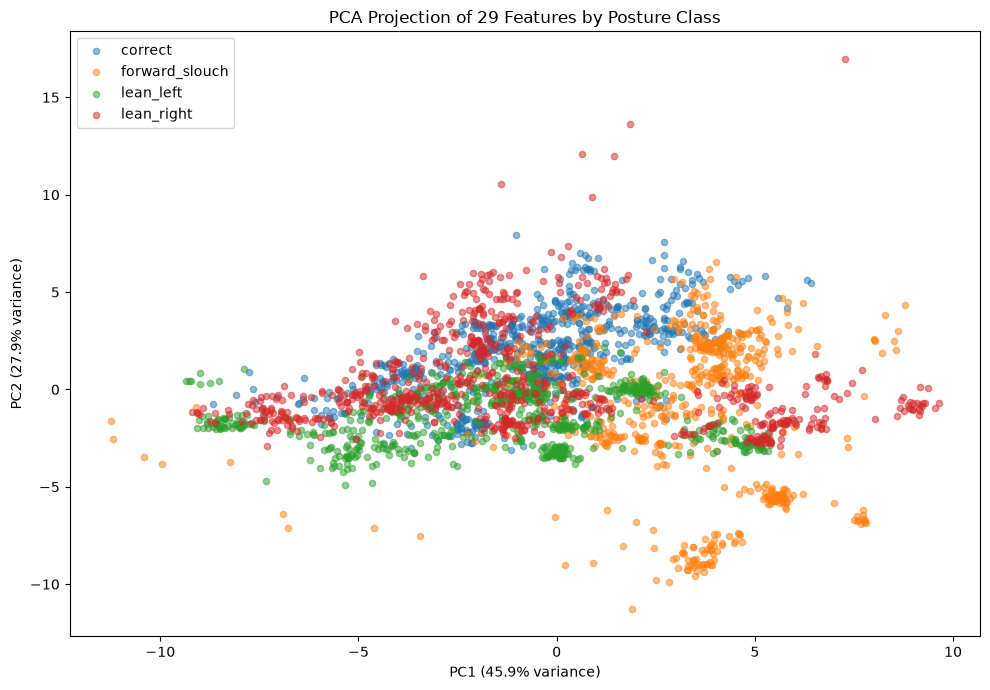

In [119]:
# PCA scatter theo posture class
plt.figure(figsize=(10, 7))

for label in EXPECTED_CLASSES:

    subset = pca_df[
        pca_df["label"] == label
    ]

    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        alpha=0.5,
        s=20,
        label=label
    )

plt.xlabel(
    f"PC1 ({explained_variance[0] * 100:.1f}% variance)"
)

plt.ylabel(
    f"PC2 ({explained_variance[1] * 100:.1f}% variance)"
)

plt.title(
    "PCA Projection of 29 Features by Posture Class"
)

plt.legend()
plt.tight_layout()
plt.show()

In [120]:
# Tính centroid của từng posture
class_centroids = (
    pca_df
    .groupby("label")[["PC1", "PC2"]]
    .mean()
    .reindex(EXPECTED_CLASSES)
)

display(class_centroids)

,PC1,PC2
label,,
correct,-0.633939,1.839866
forward_slouch,3.083702,-0.960126
lean_left,-1.239714,-1.312326
lean_right,-0.772445,0.381866


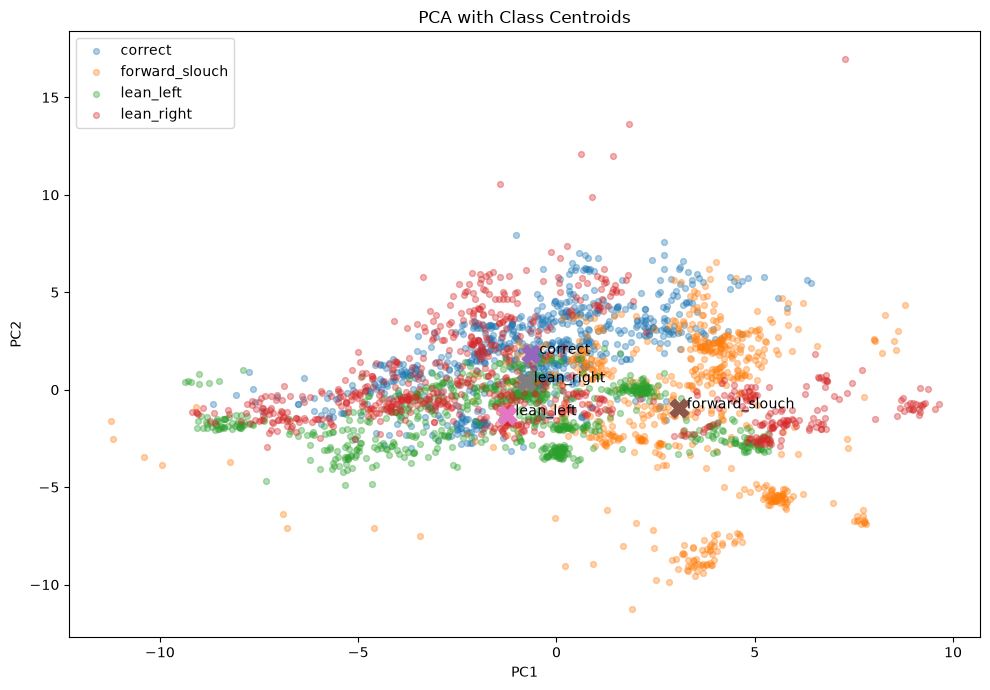

In [121]:
plt.figure(figsize=(10, 7))

for label in EXPECTED_CLASSES:

    subset = pca_df[
        pca_df["label"] == label
    ]

    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        alpha=0.35,
        s=18,
        label=label
    )

for label in EXPECTED_CLASSES:

    x = class_centroids.loc[label, "PC1"]
    y = class_centroids.loc[label, "PC2"]

    plt.scatter(
        x,
        y,
        s=180,
        marker="X"
    )

    plt.text(
        x,
        y,
        f"  {label}",
        fontsize=10
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA with Class Centroids")

plt.legend()
plt.tight_layout()
plt.show()

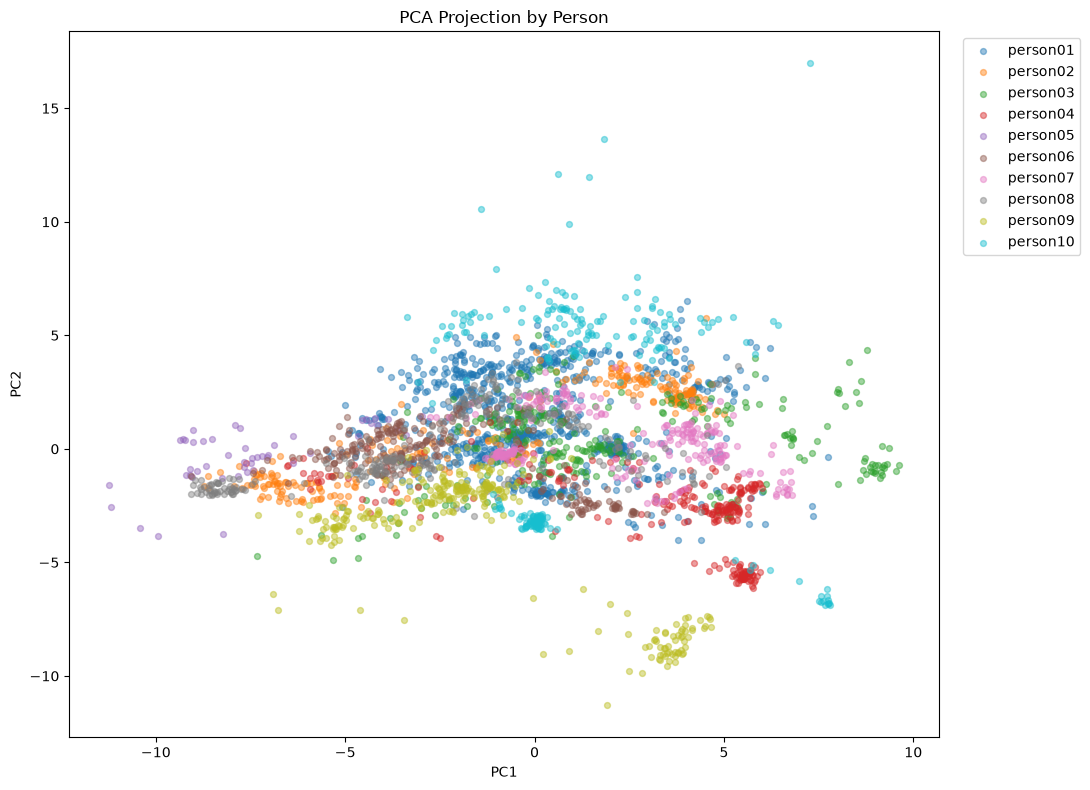

In [122]:
# PCA theo person_id
plt.figure(figsize=(11, 8))

persons = sorted(
    pca_df["person_id"].unique()
)

for person in persons:

    subset = pca_df[
        pca_df["person_id"] == person
    ]

    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        alpha=0.45,
        s=18,
        label=person
    )

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title(
    "PCA Projection by Person"
)

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

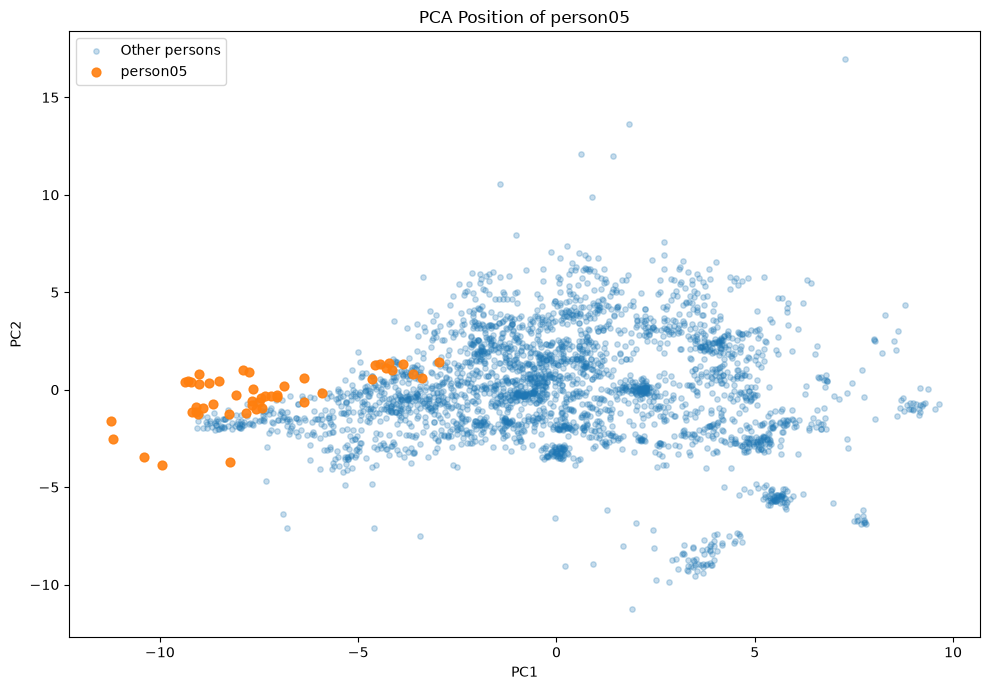

In [123]:
# Kiểm tra riêng person05
plt.figure(figsize=(10, 7))

normal_data = pca_df[
    pca_df["person_id"] != "person05"
]

person05_data = pca_df[
    pca_df["person_id"] == "person05"
]

plt.scatter(
    normal_data["PC1"],
    normal_data["PC2"],
    alpha=0.25,
    s=15,
    label="Other persons"
)

plt.scatter(
    person05_data["PC1"],
    person05_data["PC2"],
    alpha=0.9,
    s=40,
    label="person05"
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title(
    "PCA Position of person05"
)

plt.legend()

plt.tight_layout()
plt.show()

In [124]:
# Explained variance của toàn bộ 29 PCs
pca_full = PCA()

pca_full.fit(X_scaled)

explained_ratio = (
    pca_full.explained_variance_ratio_
)

cumulative_variance = (
    np.cumsum(explained_ratio)
)

In [125]:
pca_variance_table = pd.DataFrame({
    "PC": [
        f"PC{i}"
        for i in range(
            1,
            len(explained_ratio) + 1
        )
    ],

    "explained_variance_pct":
        explained_ratio * 100,

    "cumulative_variance_pct":
        cumulative_variance * 100
})

display(pca_variance_table)

,PC,explained_variance_pct,cumulative_variance_pct
0,PC1,4.592275e+01,45.922747
1,PC2,2.786223e+01,73.784980
2,PC3,1.205139e+01,85.836367
3,PC4,5.104058e+00,90.940425
4,PC5,2.994501e+00,93.934926
5,PC6,2.213295e+00,96.148221
6,PC7,1.359705e+00,97.507926
7,PC8,1.039779e+00,98.547705
8,PC9,6.429875e-01,99.190692
9,PC10,2.761791e-01,99.466871


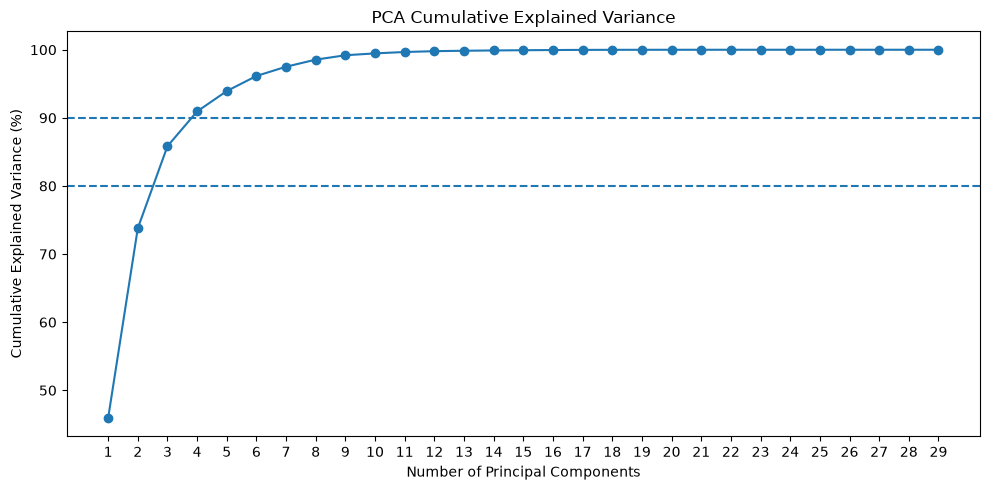

In [126]:
# 11 Scree plot
plt.figure(figsize=(10, 5))

plt.plot(
    range(
        1,
        len(cumulative_variance) + 1
    ),
    cumulative_variance * 100,
    marker="o"
)

plt.xlabel(
    "Number of Principal Components"
)

plt.ylabel(
    "Cumulative Explained Variance (%)"
)

plt.title(
    "PCA Cumulative Explained Variance"
)

plt.axhline(
    y=80,
    linestyle="--"
)

plt.axhline(
    y=90,
    linestyle="--"
)

plt.xticks(
    range(
        1,
        len(cumulative_variance) + 1
    )
)

plt.tight_layout()
plt.show()

In [127]:
# Tính số PC cần cho 80% và 90%
n_components_80 = (
    np.argmax(
        cumulative_variance >= 0.80
    )
    + 1
)

n_components_90 = (
    np.argmax(
        cumulative_variance >= 0.90
    )
    + 1
)

print(
    "Components for >=80% variance:",
    n_components_80
)

print(
    "Components for >=90% variance:",
    n_components_90
)

Components for >=80% variance: 3
Components for >=90% variance: 4


In [128]:
# PCA Loadings
pca_loadings = pd.DataFrame(
    pca_2d.components_.T,
    index=feature_columns,
    columns=["PC1", "PC2"]
)

display(pca_loadings)

,PC1,PC2
shoulder_angle,0.026581,-0.069325
eye_shoulder_angle,-0.150225,-0.030077
eye_vertical_difference,-0.148643,-0.028526
nose_x_body,0.254307,0.114122
nose_y_body,-0.101901,0.323045
eye_center_x_body,0.259842,0.081940
eye_center_y_body,-0.085501,0.329382
left_ear_x_body,0.227939,0.031824
left_ear_y_body,0.026540,0.310498
nose_eye_dx,0.047821,0.258847


In [129]:
# Top contributors của PC1
pc1_contributors = (
    pca_loadings["PC1"]
    .abs()
    .sort_values(
        ascending=False
    )
)

display(
    pc1_contributors
    .head(10)
    .to_frame("abs_PC1_loading")
)

,abs_PC1_loading
eye_shoulder_asymmetry,0.268479
nose_shoulder_asymmetry,0.267896
eye_center_x_body,0.259842
head_body_angle,0.258835
nose_x_body,0.254307
nose_body_angle,0.248985
head_gravity_angle,0.241972
nose_ear_ratio,0.238021
eye_vertical_axis_offset,0.236378
nose_gravity_angle,0.235913


In [130]:
pc2_contributors = (
    pca_loadings["PC2"]
    .abs()
    .sort_values(
        ascending=False
    )
)

display(
    pc2_contributors
    .head(10)
    .to_frame("abs_PC2_loading")
)

,abs_PC2_loading
eye_shoulder_center_distance,0.336939
head_mean_height,0.333982
nose_shoulder_center_distance,0.331562
eye_center_y_body,0.329382
nose_y_body,0.323045
left_ear_y_body,0.310498
nose_eye_dx,0.258847
face_pitch_angle,0.251228
head_axis_angle_spread,0.207784
head_height_spread,0.168164


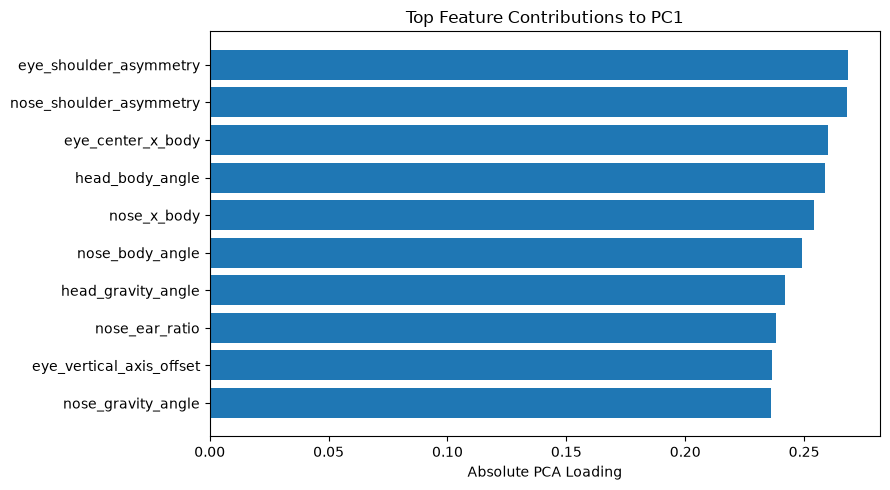

In [131]:
# Vẽ PCA loadings
pc1_top = (
    pca_loadings["PC1"]
    .abs()
    .sort_values(
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(9, 5))

plt.barh(
    pc1_top.index[::-1],
    pc1_top.values[::-1]
)

plt.xlabel(
    "Absolute PCA Loading"
)

plt.title(
    "Top Feature Contributions to PC1"
)

plt.tight_layout()
plt.show()

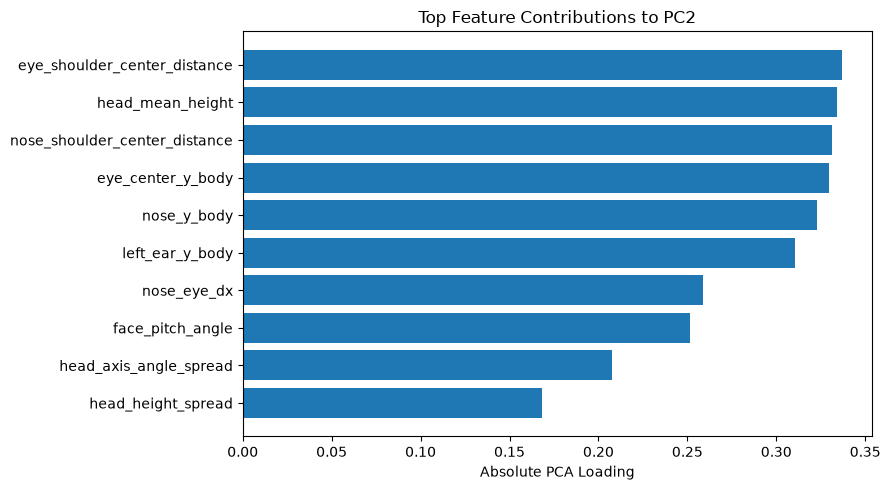

In [132]:
pc2_top = (
    pca_loadings["PC2"]
    .abs()
    .sort_values(
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(9, 5))

plt.barh(
    pc2_top.index[::-1],
    pc2_top.values[::-1]
)

plt.xlabel(
    "Absolute PCA Loading"
)

plt.title(
    "Top Feature Contributions to PC2"
)

plt.tight_layout()
plt.show()

### Kết luận bước 10 - PCA Visualization

- PCA được thực hiện trên 29 features sau khi StandardScaler.

- PC1 giải thích khoảng 45.92% variance và PC2 giải thích khoảng 27.86%.
  Hai principal components đầu tiên giữ khoảng 73.78% tổng variance.

- Chỉ cần:
  - 3 principal components để giữ >80% variance (~85.84%)
  - 4 principal components để giữ >90% variance (~90.94%)

- Kết quả này cho thấy bộ 29 engineered features có redundancy đáng kể,
  phù hợp với correlation analysis ở bước trước.

- Các principal components cuối có explained variance gần bằng 0, cho thấy
  tồn tại một số quan hệ tuyến tính gần như phụ thuộc hoàn toàn giữa các
  engineered features.

- PCA 2D cho thấy 4 posture classes có cấu trúc khác nhau và centroid khác nhau,
  nhưng vẫn tồn tại overlap đáng kể giữa các class.

- Việc overlap trên PCA 2D không đồng nghĩa feature set không tốt, vì PCA là
  phương pháp unsupervised và chỉ tối đa hóa variance chứ không tối đa hóa
  khả năng phân biệt label.

- PCA theo `person_id` cho thấy dữ liệu có subject-specific structure khá rõ.
  Điều này chứng minh feature space không chỉ encode posture mà còn chứa
  thông tin liên quan đến geometry của từng person.

- Vì vậy train/validation/test không nên random theo frame. Việc split cần được
  thực hiện theo `person_id` để tránh subject leakage và đánh giá đúng khả năng
  generalize sang người chưa xuất hiện trong training.

- `person05` có xu hướng nằm ở vùng lệch so với phần lớn dữ liệu, phù hợp với
  lỗi acquisition protocol đã biết, nhưng vẫn có một phần overlap với dữ liệu
  của các person khác.

- PC1 nhận đóng góp lớn từ các feature liên quan đến asymmetry, horizontal
  position và body/head orientation.

- PC2 nhận đóng góp lớn từ các feature liên quan đến vertical head position,
  shoulder distance, head height và face pitch.

- PCA hiện chỉ được dùng cho EDA. Chưa có quyết định sử dụng PCA làm preprocessing
  cho mô hình.

- Nếu PCA được sử dụng trong modeling sau này, StandardScaler và PCA phải được
  fit chỉ trên training set thông qua Pipeline để tránh data leakage.

## 11. Data Leakage and Group-based Splitting

Mục tiêu:
- Kiểm tra nguy cơ data leakage do các frame liên tiếp của cùng một person/video.
- Xác định đơn vị group phù hợp cho train/validation/test split.
- Đảm bảo cùng một person không xuất hiện ở nhiều tập dữ liệu.
- Kiểm tra class distribution sau khi split.
- Chuẩn bị chiến lược split cho preprocessing và model evaluation.

Nguyên tắc chính:
Final evaluation phải được thực hiện trên persons chưa xuất hiện trong training.

In [133]:
# Xác nhận lại cấu trúc Person × Session
df["recording_id"] = (
    df["person_id"].astype(str)
    + "__"
    + df["session_id"].astype(str)
)

recording_table = (
    df.groupby(
        ["person_id", "session_id", "recording_id"]
    )
    .size()
    .reset_index(name="sample_count")
)

display(recording_table)

,person_id,session_id,recording_id,sample_count
0,person01,session01,person01__session01,297
1,person01,session02,person01__session02,241
2,person01,session03,person01__session03,258
3,person02,session01,person02__session01,273
4,person03,session01,person03__session01,307
5,person04,session01,person04__session01,258
6,person05,session01,person05__session01,48
7,person06,session01,person06__session01,252
8,person07,session01,person07__session01,255
9,person08,session01,person08__session01,246


Vì sao split theo session vẫn chưa đủ?
### Leakage Risk

Các frame thuộc cùng một person có thể chia sẻ:
- body geometry
- head/shoulder proportions
- camera distance
- clothing/background
- recording conditions

Do đó, ngay cả khi hai frame thuộc hai session khác nhau,
việc cùng một person xuất hiện ở train và test vẫn có thể tạo subject leakage.

Vì vậy:
- `recording_id` được dùng để theo dõi recording session.
- `person_id` được dùng làm group chính khi đánh giá khả năng generalization.

In [134]:
# Kiểm tra nguy cơ của random frame split
from sklearn.model_selection import train_test_split

random_train, random_test = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

train_persons = set(random_train["person_id"])
test_persons = set(random_test["person_id"])

person_overlap = train_persons & test_persons

print("Persons in random train:", sorted(train_persons))
print("Persons in random test :", sorted(test_persons))
print("Person overlap         :", sorted(person_overlap))
print("Number of overlapping persons:", len(person_overlap))

Persons in random train: ['person01', 'person02', 'person03', 'person04', 'person05', 'person06', 'person07', 'person08', 'person09', 'person10']
Persons in random test : ['person01', 'person02', 'person03', 'person04', 'person05', 'person06', 'person07', 'person08', 'person09', 'person10']
Person overlap         : ['person01', 'person02', 'person03', 'person04', 'person05', 'person06', 'person07', 'person08', 'person09', 'person10']
Number of overlapping persons: 10


In [135]:
# Kiểm tra recording leakage
train_recordings = set(
    random_train["recording_id"]
)

test_recordings = set(
    random_test["recording_id"]
)

recording_overlap = (
    train_recordings
    & test_recordings
)

print(
    "Overlapping recordings:",
    len(recording_overlap)
)

Overlapping recordings: 12


In [136]:
# Đánh dấu person05
PROTOCOL_INVALID_PERSONS = [
    "person05"
]

df_model_candidate = df[
    ~df["person_id"].isin(
        PROTOCOL_INVALID_PERSONS
    )
].copy()

print("EDA samples:", len(df))
print(
    "Current valid modeling samples:",
    len(df_model_candidate)
)

print(
    "Current valid persons:",
    df_model_candidate["person_id"].nunique()
)

EDA samples: 2945
Current valid modeling samples: 2897
Current valid persons: 9


In [137]:
# Tạo helper đánh giá một split
def summarize_split(split_df, split_name):
    print("=" * 60)
    print(split_name)
    print("=" * 60)

    print("Samples :", len(split_df))
    print(
        "Persons :",
        sorted(
            split_df["person_id"].unique()
        )
    )

    print(
        "Number of persons:",
        split_df["person_id"].nunique()
    )

    class_counts = (
        split_df["label"]
        .value_counts()
        .reindex(
            EXPECTED_CLASSES,
            fill_value=0
        )
    )

    class_pct = (
        class_counts
        / len(split_df)
        * 100
    )

    summary = pd.DataFrame({
        "count": class_counts,
        "percentage": class_pct.round(2)
    })

    display(summary)

In [138]:
# Dùng GroupShuffleSplit để tạo candidate split
from sklearn.model_selection import GroupShuffleSplit

model_df = df_model_candidate.copy()

gss_test = GroupShuffleSplit(
    n_splits=1,
    test_size=2 / 9,
    random_state=42
)

train_val_idx, test_idx = next(
    gss_test.split(
        model_df,
        groups=model_df["person_id"]
    )
)

train_val_df = model_df.iloc[
    train_val_idx
].copy()

test_df = model_df.iloc[
    test_idx
].copy()

In [139]:
gss_val = GroupShuffleSplit(
    n_splits=1,
    test_size=1 / 7,
    random_state=42
)

train_idx, val_idx = next(
    gss_val.split(
        train_val_df,
        groups=train_val_df["person_id"]
    )
)

train_df = train_val_df.iloc[
    train_idx
].copy()

val_df = train_val_df.iloc[
    val_idx
].copy()

In [140]:
# Kiểm tra persons của ba tập
train_persons = set(
    train_df["person_id"]
)

val_persons = set(
    val_df["person_id"]
)

test_persons = set(
    test_df["person_id"]
)

print("TRAIN persons:", sorted(train_persons))
print("VAL persons  :", sorted(val_persons))
print("TEST persons :", sorted(test_persons))

TRAIN persons: ['person03', 'person04', 'person06', 'person07', 'person08', 'person10']
VAL persons  : ['person01']
TEST persons : ['person02', 'person09']


In [141]:
print(
    "Train ∩ Val :",
    train_persons & val_persons
)

print(
    "Train ∩ Test:",
    train_persons & test_persons
)

print(
    "Val ∩ Test  :",
    val_persons & test_persons
)

Train ∩ Val : set()
Train ∩ Test: set()
Val ∩ Test  : set()


In [142]:
# Viết assertion chống leakage
assert train_persons.isdisjoint(
    val_persons
)

assert train_persons.isdisjoint(
    test_persons
)

assert val_persons.isdisjoint(
    test_persons
)

print(
    "PASS: No person leakage "
    "between train/validation/test."
)

PASS: No person leakage between train/validation/test.


In [143]:
# Kiểm tra recording overlap
train_recordings = set(
    train_df["recording_id"]
)

val_recordings = set(
    val_df["recording_id"]
)

test_recordings = set(
    test_df["recording_id"]
)

assert train_recordings.isdisjoint(
    val_recordings
)

assert train_recordings.isdisjoint(
    test_recordings
)

assert val_recordings.isdisjoint(
    test_recordings
)

print(
    "PASS: No recording leakage."
)

PASS: No recording leakage.


In [144]:
# Xem distribution của từng split
summarize_split(
    train_df,
    "TRAIN"
)

summarize_split(
    val_df,
    "VALIDATION"
)

summarize_split(
    test_df,
    "TEST"
)

TRAIN
Samples : 1544
Persons : ['person03', 'person04', 'person06', 'person07', 'person08', 'person10']
Number of persons: 6


,count,percentage
label,,
correct,368,23.83
forward_slouch,325,21.05
lean_left,436,28.24
lean_right,415,26.88


VALIDATION
Samples : 796
Persons : ['person01']
Number of persons: 1


,count,percentage
label,,
correct,211,26.51
forward_slouch,192,24.12
lean_left,201,25.25
lean_right,192,24.12


TEST
Samples : 557
Persons : ['person02', 'person09']
Number of persons: 2


,count,percentage
label,,
correct,152,27.29
forward_slouch,135,24.24
lean_left,137,24.60
lean_right,133,23.88


In [145]:
# Tạo bảng tổng hợp split
split_summary = pd.DataFrame({
    "split": [
        "train",
        "validation",
        "test"
    ],

    "samples": [
        len(train_df),
        len(val_df),
        len(test_df)
    ],

    "persons": [
        train_df["person_id"].nunique(),
        val_df["person_id"].nunique(),
        test_df["person_id"].nunique()
    ],

    "classes": [
        train_df["label"].nunique(),
        val_df["label"].nunique(),
        test_df["label"].nunique()
    ]
})

display(split_summary)

,split,samples,persons,classes
0,train,1544,6,4
1,validation,796,1,4
2,test,557,2,4


In [146]:
# Person allocation table
person_split_rows = []

for split_name, split_df in [
    ("train", train_df),
    ("validation", val_df),
    ("test", test_df),
]:

    for person in sorted(
        split_df["person_id"].unique()
    ):

        person_split_rows.append({
            "person_id": person,
            "split": split_name,
            "sample_count": (
                split_df[
                    split_df["person_id"]
                    == person
                ].shape[0]
            )
        })

person_split_table = pd.DataFrame(
    person_split_rows
)

display(person_split_table)

,person_id,split,sample_count
0,person03,train,307
1,person04,train,258
2,person06,train,252
3,person07,train,255
4,person08,train,246
5,person10,train,226
6,person01,validation,796
7,person02,test,273
8,person09,test,284


### Kết luận bước 11 - Data Leakage and Group Split

- Các frame liên tiếp từ cùng một video/person có mức độ phụ thuộc cao,
  do đó random frame-level split không phù hợp cho bài toán này.

- PCA cho thấy feature space chứa subject-specific structure,
  củng cố nguy cơ subject leakage.

- `session_id` không phải định danh duy nhất trên toàn dataset.
  Một recording cụ thể được xác định bởi `(person_id, session_id)`.

- Tuy nhiên, final evaluation phải group theo `person_id`, không chỉ theo
  recording session, vì cùng một person ở nhiều session vẫn có thể tạo
  subject leakage.

- Train, validation và test phải có tập person hoàn toàn disjoint.

- `person05` hiện được giữ trong EDA nhưng tạm thời không nên dùng cho
  modeling vì recording hiện tại vi phạm camera acquisition protocol.
  Subject này sẽ được đưa trở lại sau khi quay lại đúng protocol.

- Hiện tại dataset có 9 valid modeling persons. Final split chưa nên được
  khóa cho đến khi dữ liệu person05 được thu lại.

- Khi dataset hoàn thiện với 10 valid persons, chiến lược đề xuất là:
  - giữ 2 persons làm final unseen-person test set;
  - sử dụng 8 persons còn lại cho model development;
  - sử dụng GroupKFold hoặc Leave-One-Group-Out theo `person_id`
    để model selection và hyperparameter tuning.

- StandardScaler, PCA hoặc bất kỳ preprocessing nào phải được fit chỉ trên
  training data thông qua Pipeline.

- Không preprocessing, scaling, PCA hoặc oversampling trên toàn dataset
  trước khi split.

- Class distribution hiện tương đối cân bằng nên chưa có lý do sử dụng
  SMOTE hoặc resampling.

Mục tiêu evaluation cuối cùng là đo khả năng generalize sang một person
chưa từng xuất hiện trong training.

## 12. EDA Conclusions

### 12.1 Dataset Overview

Dataset sau `DatasetBuilder` hiện có:

- 2945 samples.
- 33 columns.
- 4 metadata columns:
  - `image_path`
  - `session_id`
  - `person_id`
  - `label`
- 29 engineered features từ `FeatureExtractor V2`.
- 10 persons.
- 4 posture classes:
  - `correct`
  - `forward_slouch`
  - `lean_left`
  - `lean_right`

Tất cả 29 features đều có kiểu numerical (`float64`).

---

### 12.2 Data Integrity

Dataset có chất lượng tốt về mặt kỹ thuật:

- Không có missing values.
- Không có `+inf` hoặc `-inf`.
- Không có duplicated rows.
- Không có duplicated `image_path`.
- Không có constant feature.
- Các engineered features có số lượng giá trị unique cao.

Do đó, hiện chưa cần thực hiện missing-value imputation hoặc xử lý
duplicate trong preprocessing.

---

### 12.3 Class Distribution

Phân bố tổng thể giữa 4 posture classes tương đối cân bằng:

- `correct`: 743 samples.
- `forward_slouch`: 658 samples.
- `lean_left`: 782 samples.
- `lean_right`: 762 samples.

`forward_slouch` là class có ít sample nhất nhưng mức chênh lệch chưa đủ
lớn để xem là class imbalance nghiêm trọng.

Hiện chưa có lý do sử dụng:
- oversampling
- undersampling
- SMOTE

trước khi đánh giá model.

---

### 12.4 Person-level Distribution

Dataset không cân bằng hoàn toàn theo `person_id`.

`person01` có nhiều sample hơn đáng kể do được thu trong 3 recording sessions,
trong khi phần lớn các persons khác chỉ có `session01`.

`person05` chỉ còn 48 valid samples. Nguyên nhân đã được xác định là lỗi
thu thập dữ liệu: camera được đặt/quay từ phía bên phải thay vì góc camera
chuẩn khoảng 45° từ phía bên trái.

Do FeatureExtractor hiện tại được thiết kế dựa trên 6 keypoints phù hợp với
left-side camera view, phần lớn frame của `person05` không đủ keypoints và
bị reject.

`person05` vẫn được giữ trong EDA để đảm bảo traceability nhưng recording
hiện tại cần được thay thế bằng dữ liệu quay lại đúng protocol trước khi
sử dụng chính thức cho modeling.

`person10` có số lượng `forward_slouch` thấp bất thường (17 samples) và cần
được lưu ý khi phân tích dataset/model về sau.

---

### 12.5 Statistical Properties of 29 Features

Không có feature nào bị constant hoặc có dấu hiệu numerical failure.

Các features có scale khác nhau đáng kể:

- angle features có thể nằm trong khoảng hàng chục đến hàng trăm độ;
- ratio, normalized coordinate và distance features chủ yếu có magnitude nhỏ hơn.

Điều này chưa phải vấn đề lớn đối với tree-based models như XGBoost,
nhưng scaling sẽ cần được xem xét đối với SVM.

Một số signed features có phần lớn hoặc toàn bộ giá trị âm.
Đây chưa được xem là lỗi vì dấu phản ánh hệ tọa độ và hướng geometry
được sử dụng trong công thức feature.

---

### 12.6 Feature Distribution and Class Separation

Nhiều engineered features cho thấy sự khác biệt rõ về phân phối giữa
các posture classes.

`shoulder_angle` có normalized median spread cao nhất (~2.04) và là feature
đơn biến nổi bật nhất trong bộ dữ liệu.

Nhóm feature có tiềm năng tốt cho `lean_left` / `lean_right` gồm:

- `shoulder_angle`
- `eye_shoulder_angle`
- `eye_vertical_difference`
- `eye_vertical_axis_offset`
- `nose_vertical_axis_offset`
- `head_gravity_angle`
- `nose_gravity_angle`

Nhóm feature có tiềm năng tốt cho `correct` / `forward_slouch` gồm:

- `nose_eye_dy`
- `nose_y_body`
- `nose_ear_ratio`
- `head_body_angle`
- `nose_body_angle`
- `head_gravity_angle`
- `nose_gravity_angle`
- `head_mean_height`
- `head_height_spread`
- `eye_center_y_body`
- shoulder asymmetry features

Kết quả này phù hợp với mục tiêu thiết kế FeatureExtractor V2:
các feature mô tả shoulder alignment hỗ trợ nhận diện lean posture,
trong khi các feature head/body geometry hỗ trợ nhận diện forward slouch.

---

### 12.7 Subject Consistency

Một số feature duy trì direction/pattern ổn định trên hầu hết hoặc toàn bộ
10 persons.

Đối với `lean_left` / `lean_right`, các feature như:

- `eye_vertical_axis_offset`
- `nose_vertical_axis_offset`
- `head_gravity_angle`
- `nose_gravity_angle`

cho thấy consistency rất cao giữa các persons.

Đối với `correct` / `forward_slouch`, các feature như:

- `nose_y_body`
- `head_height_spread`
- `head_mean_height`
- `eye_center_y_body`
- `left_ear_y_body`

cho thấy pattern ổn định giữa các subjects.

Điều này cho thấy các feature không chỉ phản ánh một vài individuals mà có
khả năng chứa posture-related signal có thể generalize sang subjects khác.

---

### 12.8 Univariate Predictive Ability

Subject-aware univariate evaluation được thực hiện bằng GroupKFold theo
`person_id`.

Feature đơn lẻ tốt nhất là:

`shoulder_angle`

với balanced accuracy khoảng:

`0.524 ± 0.169`

Các feature tiếp theo gồm:

- `nose_gravity_angle`
- `head_gravity_angle`
- `nose_y_body`
- `eye_center_y_body`
- `head_axis_angle_spread`
- vertical-axis offset features

Balanced accuracy tốt nhất của một feature đơn lẻ vẫn chỉ khoảng 0.52,
cao hơn đáng kể so với baseline 4-class (~0.25) nhưng chưa đủ để giải quyết
toàn bộ bài toán.

Do đó, classifier cần kết hợp nhiều engineered features thay vì phụ thuộc
vào một feature duy nhất.

---

### 12.9 Outlier Analysis

Outlier được phát hiện bằng IQR nhưng chưa được xem đồng nghĩa với bad data.

Các feature có tỷ lệ global IQR outlier cao nhất gồm:

- `head_axis_angle_spread`
- `head_gravity_angle`
- `nose_gravity_angle`
- `shoulder_angle`
- `eye_center_y_body`
- `head_mean_height`

Nhiều feature trong nhóm này trực tiếp mô tả posture geometry, do đó extreme
values có thể là những posture hợp lệ thay vì lỗi.

`person05` có số lượng outlier features trung bình cao, phù hợp với lỗi
camera protocol đã biết.

Một số persons khác như `person09` và `person10` cũng có các extreme frames,
do đó không thể kết luận mọi outlier đều bắt nguồn từ `person05`.

Không thực hiện automatic IQR filtering.

Các frame có nhiều feature đồng thời bị đánh dấu outlier nên được xem như
candidate cho manual inspection qua `image_path`.

---

### 12.10 Feature Correlation and Redundancy

Bộ 29 features tồn tại nhiều cặp correlation rất cao.

Ví dụ:

- `eye_center_y_body` ↔ `head_mean_height`
- `nose_y_body` ↔ `eye_center_y_body`
- `nose_shoulder_asymmetry` ↔ `eye_shoulder_asymmetry`
- `eye_vertical_axis_offset` ↔ `nose_vertical_axis_offset`
- `nose_x_body` ↔ `eye_center_x_body`
- `nose_shoulder_center_distance` ↔ `eye_shoulder_center_distance`
- `head_gravity_angle` ↔ `nose_gravity_angle`
- `head_body_angle` ↔ `nose_body_angle`

Nhiều correlation có magnitude trên 0.98, cho thấy tồn tại redundancy đáng kể.

Tuy nhiên, chưa loại bỏ feature chỉ dựa trên correlation.

Feature selection sau này cần kết hợp:

- correlation
- class separation
- subject consistency
- model cross-validation
- model feature importance / permutation importance

---

### 12.11 PCA Findings

PCA được thực hiện sau StandardScaler.

Explained variance:

- PC1: ~45.92%
- PC2: ~27.86%
- PC1 + PC2: ~73.78%
- PC1–PC3: ~85.84%
- PC1–PC4: ~90.94%

Chỉ cần 3 principal components để giữ hơn 80% variance và 4 components
để giữ hơn 90%.

Điều này củng cố kết luận rằng 29 engineered features có redundancy đáng kể.

PCA 2D cho thấy 4 posture classes có structure và centroid khác nhau,
nhưng vẫn overlap.

Điều này không đồng nghĩa feature set không tốt vì PCA là unsupervised
và tối ưu variance chứ không tối ưu class separation.

PCA theo `person_id` cho thấy subject-specific structure khá rõ.

Feature space vì vậy chứa đồng thời:

- posture-related information
- subject/body-geometry information

---

### 12.12 Data Leakage Risk

Random frame-level split không phù hợp cho dataset này.

Các frame liên tiếp trong cùng recording và các frames của cùng person
chia sẻ nhiều đặc điểm:

- body geometry
- camera configuration
- background
- clothing
- temporal similarity
- recording conditions

Nếu cùng một person xuất hiện ở train và test, model có thể tận dụng
subject-specific information thay vì thực sự generalize posture recognition.

Do đó:

`Train persons ∩ Validation persons ∩ Test persons = ∅`

`person_id` phải được sử dụng làm group chính cho final evaluation.

`session_id` không unique trên toàn dataset nên một recording cụ thể cần được
xác định bằng:

`(person_id, session_id)`

Tuy nhiên, split chỉ theo recording vẫn chưa đủ để ngăn subject leakage.

---

### 12.13 Recommended Evaluation Strategy

Khi dataset hoàn thiện và `person05` được quay lại đúng protocol, dự kiến có
10 valid persons.

Chiến lược evaluation đề xuất:

1. Giữ khoảng 2 persons làm final unseen-subject test set.
2. Sử dụng các persons còn lại cho model development.
3. Sử dụng GroupKFold hoặc Leave-One-Group-Out theo `person_id`
   để model selection và hyperparameter tuning.
4. Final test set chỉ được sử dụng sau khi model và hyperparameters đã được chọn.

StandardScaler, PCA hoặc bất kỳ preprocessing transformation nào phải được
fit chỉ trên training data thông qua sklearn Pipeline.

Không được fit preprocessing trên toàn dataset trước khi split.

---

### 12.14 Overall EDA Conclusion

Dataset hiện có chất lượng numerical tốt và FeatureExtractor V2 tạo ra
29 features có posture-related signal rõ ràng.

Không phát hiện:
- missing data
- infinity
- duplicate data
- constant feature

Có ba vấn đề chính cần được xử lý ở bước modeling:

1. Subject-specific information và nguy cơ data leakage.
2. Redundancy giữa nhiều engineered features.
3. Sai acquisition protocol của `person05`.

Hiện chưa có bằng chứng để:
- bulk-remove outliers
- oversample classes
- sử dụng SMOTE
- tự động loại feature dựa trên correlation
- áp dụng PCA trước khi đánh giá model

Các quyết định preprocessing sẽ được xây dựng dựa trực tiếp trên các kết quả EDA trên.